# Task 2 — Season Classification

**Status:** the Task 2 component is complete through the locked handoff. All model choices, development evidence, the scratch refit, and image-only inference are hash-linked; Notebook 06 remains locked until the whole group freezes.

**How to finish this notebook:** run the existing cells in order later, keep their outputs, and check that every measured interpretation still matches its verified artifact. Final group evaluation stays outside this notebook.

**Structural rule:** every leaf `###` subsection owns exactly one code cell. A broader `###` owns no direct code cell; divide it into `####` subsubsections, with one code cell per `####` leaf.

**Frozen boundaries:** teacher images only; `data/processed/splits.csv` is the only split; all submitted models are trained from scratch; all runs go through `fashion.train.registry` to `results/runs.csv`; holdout remains sealed until Notebook 06.

**Core risks:** weak-visual-signal labels, article-type shortcut learning, class imbalance, acquisition artifacts, and calibration failure.

**Primary development metric:** pooled out-of-fold macro-F1 over `Fall`, `Spring`, `Summer`, and `Winter`.

## 1. Task contract and reproducibility

Freeze the decision, labels, paths, seed, and execution environment before any result is viewed.

### 1.1 Frozen task configuration

This cell creates the single configuration object used by every later cell.

In [2]:
import hashlib
import json

import pandas as pd
from IPython.display import display

from fashion.config import (
    CV_FOLD_SUMMARY_JSON,
    RANDOM_SEED,
    ROOT,
    TASK2_CHECKPOINT_DIR,
    TASK2_EVIDENCE_DIR,
    TASK2_FIGURE_DIR,
    TASK2_MODEL_PATH,
    TASK2_SELECTION_FREEZE_JSON,
)
from fashion.data.dataset import load_label_maps

TASK2_TARGET = "season"
SEASON_MASK = "has_season_label"
SEASON_LABELS = tuple(load_label_maps()[TASK2_TARGET]["classes"])
assert SEASON_LABELS == ("Fall", "Spring", "Summer", "Winter")

with CV_FOLD_SUMMARY_JSON.open(encoding="utf-8") as handle:
    cv_summary = json.load(handle)
for directory in (TASK2_EVIDENCE_DIR, TASK2_FIGURE_DIR, TASK2_CHECKPOINT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

task_contract = pd.DataFrame(
    [{
        "target": TASK2_TARGET,
        "labels": " | ".join(SEASON_LABELS),
        "seed": RANDOM_SEED,
        "cv_folds": cv_summary["fold_count"],
        "cv_assignment_sha256": cv_summary["cv_assignment_sha256"],
        "evidence_directory": TASK2_EVIDENCE_DIR.relative_to(ROOT).as_posix(),
        "figure_directory": TASK2_FIGURE_DIR.relative_to(ROOT).as_posix(),
        "checkpoint_directory": TASK2_CHECKPOINT_DIR.relative_to(ROOT).as_posix(),
        "freeze_manifest": TASK2_SELECTION_FREEZE_JSON.relative_to(ROOT).as_posix(),
        "final_model": TASK2_MODEL_PATH.relative_to(ROOT).as_posix(),
    }]
)
assert task_contract.loc[0, "cv_folds"] == 5
display(task_contract)

,target,labels,seed,cv_folds,cv_assignment_sha256,evidence_directory,figure_directory,checkpoint_directory,freeze_manifest,final_model
0,season,Fall | Spring | Summer | Winter,2753,5,bad7bc4ae65fbbfd815567f4ccfa308d6e57dc650bc15c...,results/evidence/task2,results/figures/task2,tmp/task2/checkpoints,results/evidence/task2/selection_freeze.json,models/task2_season.pt


> **Interpretation — Task contract**
>
> **Column guide.** This is one contract row, not a leaderboard. `target` and `labels` fix the prediction task and class order; `seed` and `cv_folds` fix repeatability; `cv_assignment_sha256` fingerprints the only legal folds; the remaining columns name where evidence, figures, checkpoints, the freeze record, and the final model must live.
>
> **Deep analysis.** The row fixes `season` with labels `Fall | Spring | Summer | Winter`, seed `2753`, and five canonical folds. The split hash is more important than a folder name: if it changes, old and new model scores are no longer directly comparable. No accuracy value appears because this output defines the experiment before any model is judged.
>
> **Decision and limitation.** Keep this row unchanged across every Task 2 run. A changed label order, seed, fold count, or split hash creates a new protocol and must not be mixed into the existing comparison.

### 1.2 Environment and deterministic execution

Package versions, hardware, and random state must be recorded so runs can be reproduced.

In [3]:
from pathlib import Path

from fashion.train.artifacts import atomic_write_json
from fashion.train.reproducibility import (
    capture_git_state,
    capture_runtime,
    seed_everything,
)

seed_everything(RANDOM_SEED, deterministic=True)
runtime = capture_runtime()
runtime["executable_name"] = Path(runtime.pop("executable")).name
environment_record = {
    "schema_version": "1.0.0",
    "seed": RANDOM_SEED,
    "deterministic_algorithms": True,
    "mixed_precision_policy": "torch.amp on CUDA; disabled on CPU",
    "git": capture_git_state(),
    "runtime": runtime,
}
environment_path = TASK2_EVIDENCE_DIR / "environment.json"
atomic_write_json(environment_path, environment_record)
environment_table = (
    pd.json_normalize(environment_record, sep=".")
    .transpose()
    .rename_axis("field")
    .reset_index()
    .rename(columns={0: "value"})
)
display(environment_table)

,field,value
0,schema_version,1.0.0
1,seed,2753
2,deterministic_algorithms,True
3,mixed_precision_policy,torch.amp on CUDA; disabled on CPU
4,git.commit,0a88a51f6a631c8471e1c77ab1142d7153ec8224
5,git.dirty,True
6,runtime.python,3.12.13
7,runtime.python_implementation,CPython
8,runtime.platform,Windows-11-10.0.26200-SP0
9,runtime.processor,"Intel64 Family 6 Model 183 Stepping 1, Genuine..."


> **Interpretation — Runtime and reproducibility record**
>
> **Column guide.** Read `field` as the provenance key and `value` as the captured setting. The important groups are seed/determinism, Git commit and dirty state, Python and package versions, CUDA/cuDNN, GPU, CPU, RAM, and platform. These are environment facts, not model metrics.
>
> **Deep analysis.** The verified reference run uses seed `2753`, deterministic algorithms, Python `3.12.13`, PyTorch `2.13.0+cu126`, CUDA `12.6`, and an RTX 4070 Laptop GPU. `git.dirty` must be read with the commit: a dirty run cannot be reconstructed from the commit alone. Mixed precision is enabled only on CUDA, so CPU and GPU runtimes are not expected to match.
>
> **Decision and limitation.** Use this table to explain reproducibility differences before blaming the model. Deterministic mode reduces uncontrolled variation, but hardware kernels and library changes can still alter exact bytes or timing.

### 1.3 How Task 2 files affect one another

This map separates inputs that create a model from evidence that only explains it. The direction of every arrow is part of the leakage and deployment contract.

#### 1.3.1 Declare and audit the impact edges

In [4]:
from IPython.display import display

from fashion.task2.evidence import (
    build_file_impact_edges,
    validate_file_impact_edges,
)

file_impact_edges = build_file_impact_edges()
validate_file_impact_edges(file_impact_edges)
display(file_impact_edges)

,producer,artifact,consumer,effect,phase
0,data/processed/splits.csv,canonical partitions and cv_fold,fashion.data.torch,Changing membership or folds invalidates every...,inputs
1,data/processed/label_maps.json,"Fall, Spring, Summer, Winter class order",fashion.data.torch,"Changing class indices invalidates models, met...",inputs
2,fashion.data.torch,fold-fitted tensors and loaders,Task 2 runner,Transform changes create a new implementation ...,training
3,configs/task2/*.json,immutable experiment choices,Task 2 runner,A changed scientific choice creates a new conf...,training
4,fashion.models.season,scratch logits and feature maps,Task 2 runner,Architecture changes invalidate checkpoints an...,training
5,fashion.train.engine,"best checkpoint, OOF predictions, and history",Task 2 runner,Optimisation changes invalidate the implementa...,training
6,Task 2 runner,run lifecycle and provenance row,results/runs.csv,"Every physical run is retained as completed, f...",artifacts
7,Task 2 runner,"checkpoint, OOF, and history files",tmp/task2 artifacts,Bytes are reused only when their declared SHA-...,artifacts
8,results/runs.csv,"run IDs, hashes, metrics, and status",results/evidence/task2,Registry changes rebuild evidence but do not a...,evidence
9,tmp/task2 artifacts,verified OOF and histories,results/evidence/task2,Only hash-verified outputs may support a measu...,evidence


> **Interpretation — File-impact edge table**
>
> **Column guide.** Read each row left to right as `producer` → `artifact/interface` → `consumer`; `effect_if_changed` states which downstream evidence must be rebuilt. Training inputs and code should appear upstream, while holdout and app consumers must appear only after the frozen bundle.
>
> **Deep analysis.** **Result —** the audited table declares every producer, artifact, consumer, and effect used by Task 2. **Meaning —** canonical data and source code can change training; a config change creates a new experiment identity; evidence can describe a trained model but cannot modify it. **Decision —** trace every report claim back to a registered run ID, and let holdout, prediction, and app code consume only the frozen bundle. **Limitation —** this table verifies the declared dependency contract, not model quality. **Trace —** `results/evidence/task2/file_impact_edges.csv` and its SHA-256 manifest.

#### 1.3.2 Render the file-impact flow

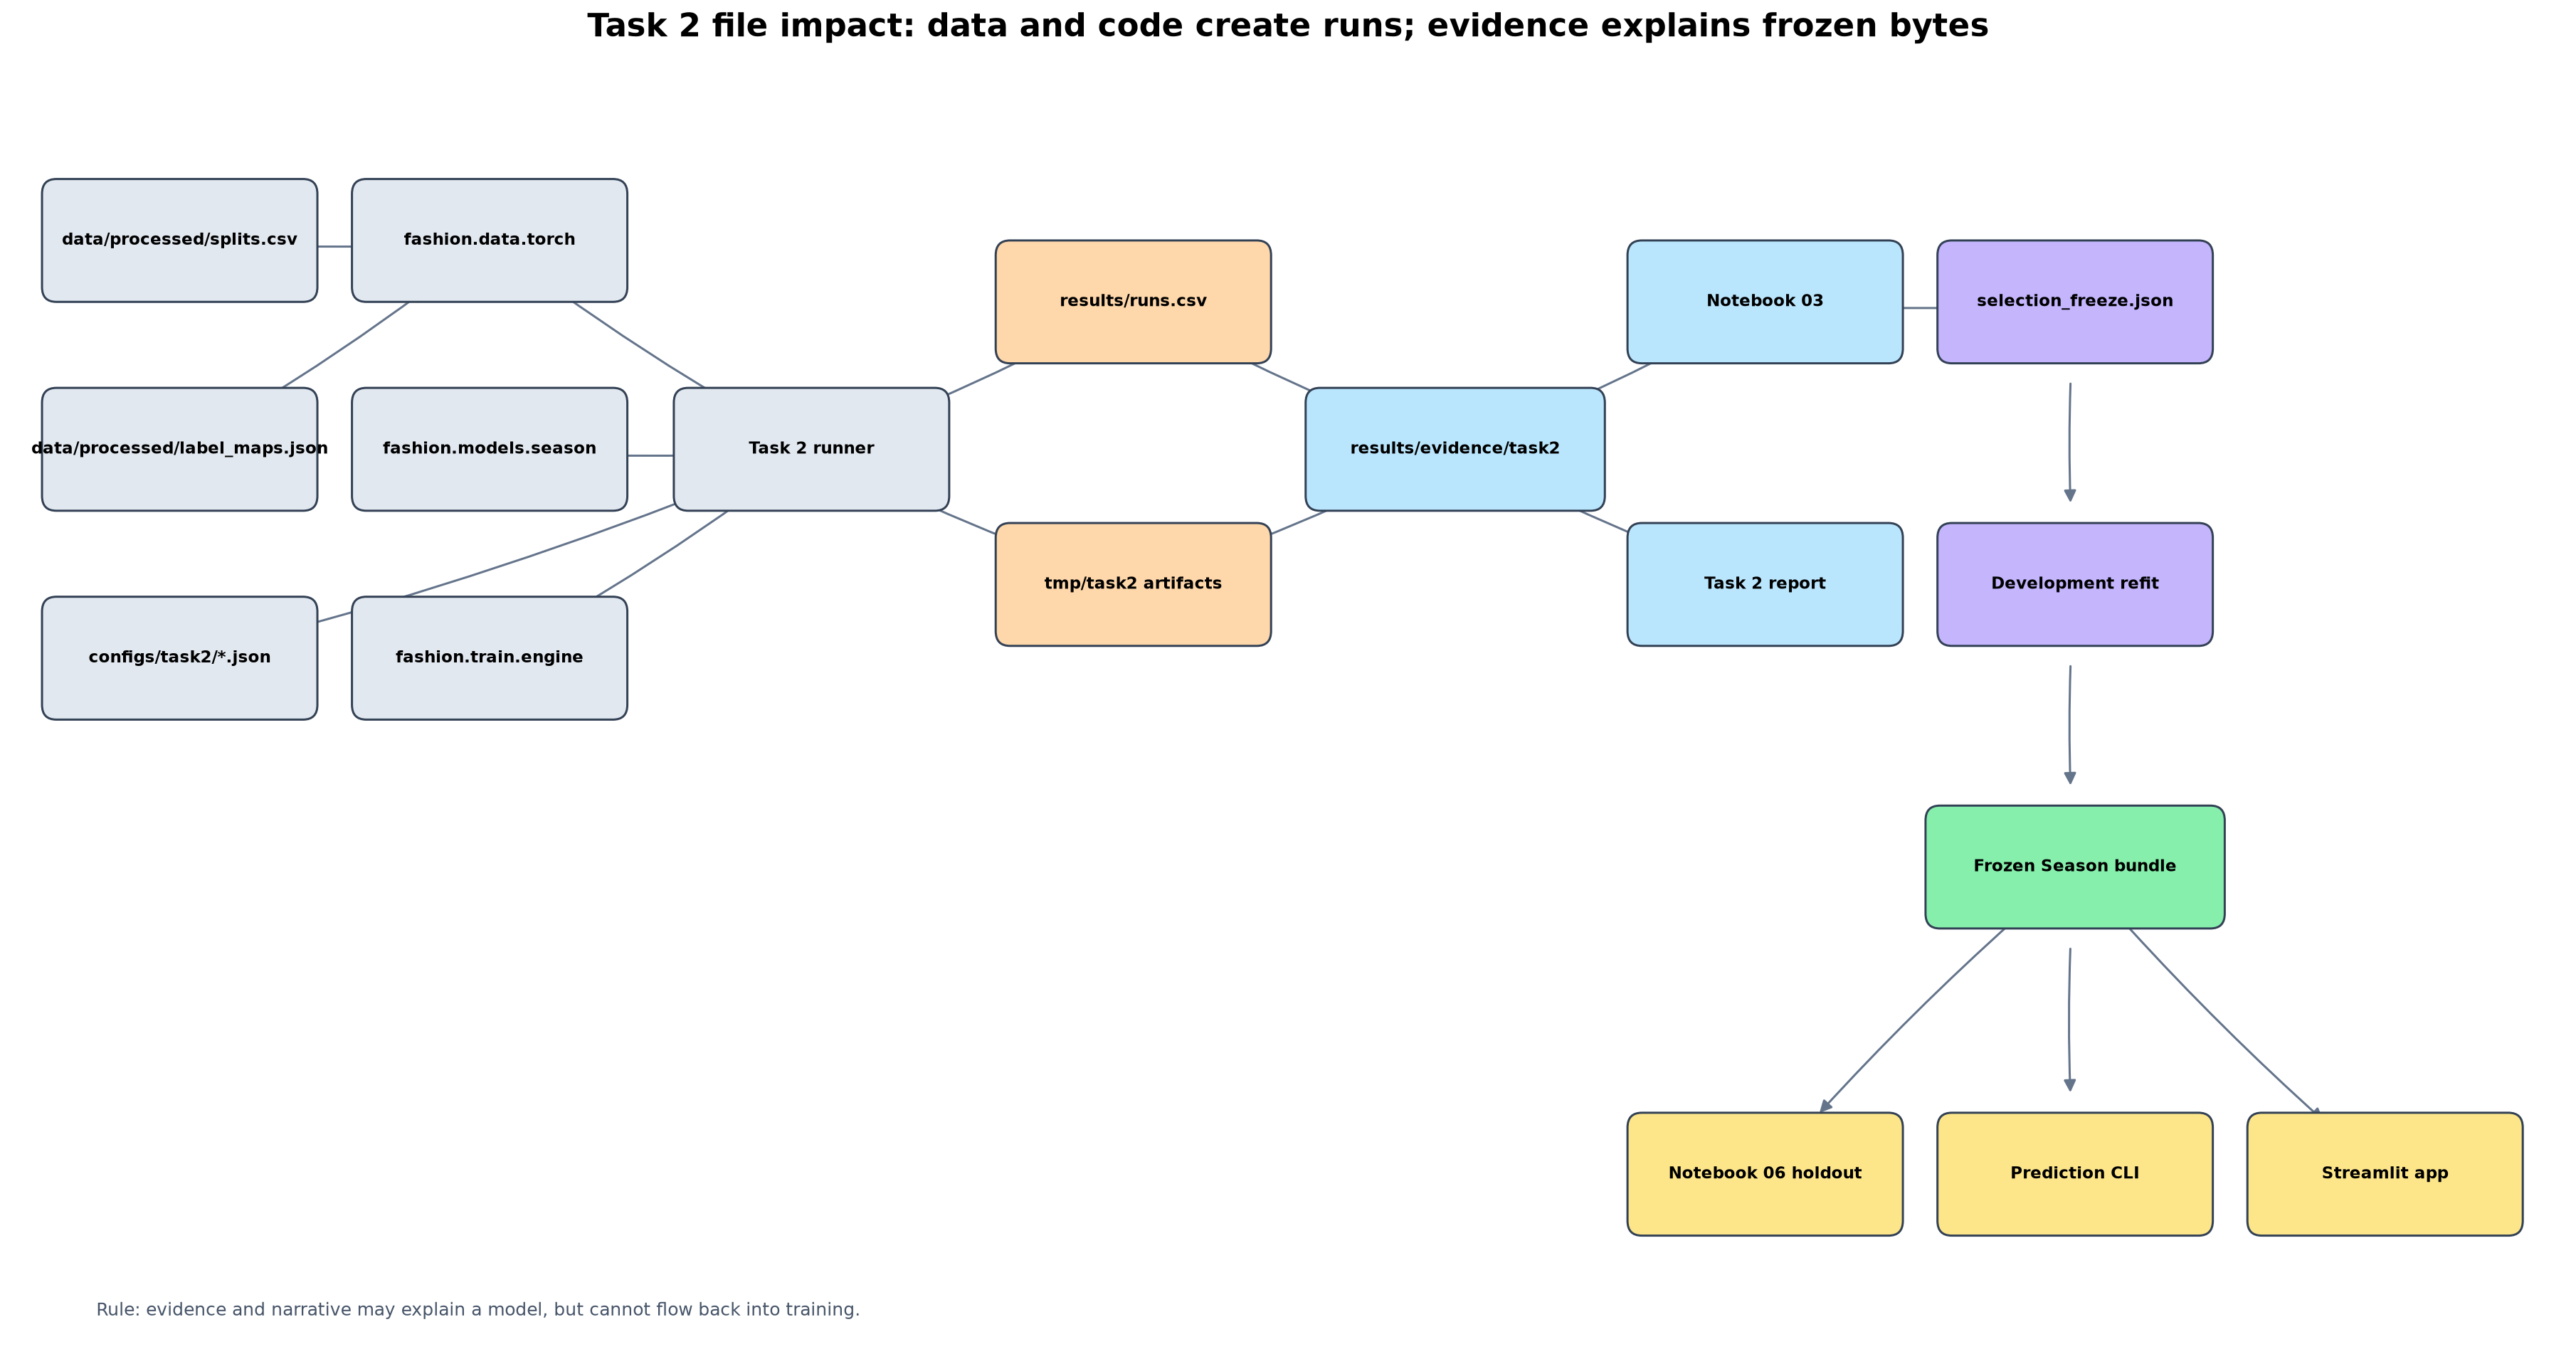

In [5]:
from IPython.display import Image, display

from fashion.config import ROOT
from fashion.task2.evidence import build_task2_evidence

file_impact_manifest = build_task2_evidence()
display(Image(filename=str(ROOT / file_impact_manifest["figure_path"])))

> **Interpretation — File-impact flow**
>
> **Chart guide.** Follow arrows from canonical splits, label maps, configs, model code, and the training engine into registered runs and evidence. The freeze/refit node is the one-way boundary; holdout, CLI, and app nodes may consume the final bundle but must not feed back into training.
>
> **Deep analysis.** **Result —** the PNG makes the one-way Task 2 lifecycle visible directly in Jupyter. **Meaning —** the selection freeze comes before development refit, while Notebook 06, the prediction CLI, and the app all read the same frozen bytes and manifest. **Decision —** use this flow when checking whether a future edit invalidates training, evidence only, or deployment. **Limitation —** arrows show allowed file impact, not runtime order or measured performance. **Trace —** `results/figures/task2/file_impact_flow.png` with its SHA-256 recorded in `file_impact_manifest.json`.

## 2. Data and EDA handoff

Reproduce only the Task 2 facts needed from Notebook 01. These are data facts, not model results.

### 2.1 Load the development task frame

Task 2 uses teacher images and excludes only rows with a truly blank Season label.

In [6]:
from fashion.data.dataset import get_samples, load_splits

splits = load_splits()
development = get_samples(splits, partition="development")
season_development = get_samples(development, target=TASK2_TARGET).reset_index(drop=True)
protected = splits["partition"].isin(["holdout", "quarantine"])
visible_protected_labels = splits.loc[protected, TASK2_TARGET].astype(str).str.strip().ne("").sum()
visible_protected_masks = splits.loc[protected, SEASON_MASK].astype(bool).sum()

assert len(development) == 32_773
assert len(season_development) == 32_753
assert len(development) - len(season_development) == 20
assert not season_development["partition"].isin(["holdout", "quarantine"]).any()
assert visible_protected_labels == visible_protected_masks == 0

task2_data_audit = pd.DataFrame(
    [
        {"check": "development rows", "value": len(development)},
        {"check": "valid Season rows", "value": len(season_development)},
        {"check": "masked Season rows", "value": len(development) - len(season_development)},
        {"check": "visible protected Season labels", "value": int(visible_protected_labels)},
        {"check": "protected rows in modelling frame", "value": 0},
    ]
)
display(task2_data_audit)

,check,value
0,development rows,32773
1,valid Season rows,32753
2,masked Season rows,20
3,visible protected Season labels,0
4,protected rows in modelling frame,0


> **Interpretation — Task 2 population audit**
>
> **Column guide.** `check` names the population rule and `value` gives its observed count. Reconcile 32,773 development rows as 32,753 valid Season rows plus 20 masked labels; both protected-label and protected-row counts must be zero.
>
> **Deep analysis.** The Task 2 handoff exactly reproduces Notebook 01: 32,773 development rows, 32,753 valid Season labels, and 20 masked labels. No holdout or quarantine label is visible, and no protected row enters the modelling frame. This confirms that the earlier EDA counts were accurate and freezes one comparable population for every later baseline, model, and ablation.

### 2.2 Audit class balance, folds, and EDA evidence

This topic needs separate numeric and visual evidence, so it is divided into two subsubsections.

#### 2.2.1 Reproduce class and fold statistics

The numeric audit checks the exact EDA facts that drive imbalance and validation choices.

In [7]:
from fashion.train.artifacts import atomic_write_csv

season_counts = season_development[TASK2_TARGET].value_counts().reindex(SEASON_LABELS)
expected_counts = pd.Series(
    {"Fall": 8_928, "Spring": 1_329, "Summer": 16_235, "Winter": 6_261}
)
pd.testing.assert_series_equal(season_counts, expected_counts, check_names=False)
fold_support = (
    pd.crosstab(season_development[TASK2_TARGET], season_development["cv_fold"])
    .reindex(index=SEASON_LABELS, columns=range(5), fill_value=0)
)
assert fold_support.gt(0).all().all()
imbalance_ratio = float(season_counts.max() / season_counts.min())
eda_handoff = pd.DataFrame(
    {
        "class": SEASON_LABELS,
        "development_products": season_counts.to_numpy(),
        "share_percent": (season_counts / season_counts.sum() * 100).to_numpy(),
        **{f"fold_{fold}_validation_products": fold_support[fold].to_numpy() for fold in range(5)},
    }
)
eda_handoff["largest_to_smallest_ratio"] = imbalance_ratio
atomic_write_csv(TASK2_EVIDENCE_DIR / "eda_handoff.csv", eda_handoff)
display(
    eda_handoff.style.format(
        {"share_percent": "{:.2f}", "largest_to_smallest_ratio": "{:.2f}"}
    )
)

,class,development_products,share_percent,fold_0_validation_products,fold_1_validation_products,fold_2_validation_products,fold_3_validation_products,fold_4_validation_products,largest_to_smallest_ratio
0,Fall,8928,27.26,1786,1786,1786,1785,1785,12.22
1,Spring,1329,4.06,266,265,265,267,266,12.22
2,Summer,16235,49.57,3246,3247,3246,3248,3248,12.22
3,Winter,6261,19.12,1252,1253,1253,1250,1253,12.22


> **Interpretation — Season class and fold support**
>
> **Column guide.** Read `development_products` and `share_percent` across the four class rows, then scan `fold_0` through `fold_4_validation_products` horizontally to confirm every fold contains every class. `largest_to_smallest_ratio` quantifies imbalance and is repeated only as the table-level ratio.
>
> **Deep analysis.** Summer contains 16,235 products (49.57%) while Spring contains 1,329 (4.06%), a 12.22:1 ratio; every fold still contains all four labels. The EDA hypothesis entering modelling is therefore explicit: accuracy can look reasonable when a model mostly predicts Summer, while pooled macro-F1 must expose failure on Spring. Section 5.1 tests this claim with B0 before any image model is accepted.

#### 2.2.2 Display the saved shortcut and transform evidence

The visual handoff keeps Notebook 03 tied to the acquisition, compression, shortcut, and transform risks found in Notebook 01.

In [8]:
from IPython.display import Image, display

from fashion.config import DATA_PREPARATION_FIGURE_DIR
from fashion.data.hashing import compute_sha256

eda_figure_paths = {
    "acquisition shortcut": DATA_PREPARATION_FIGURE_DIR / "acquisition_shortcut_risk.png",
    "file-size shortcut": DATA_PREPARATION_FIGURE_DIR / "season_file_size_shortcut.png",
    "ArticleType shortcut": DATA_PREPARATION_FIGURE_DIR / "shortcut_risk_heatmaps.png",
    "transform risk": DATA_PREPARATION_FIGURE_DIR / "transform_risk.png",
}
eda_figure_registry = pd.DataFrame(
    [
        {
            "evidence": name,
            "path": path.relative_to(ROOT).as_posix(),
            "sha256": compute_sha256(path),
            "claim_boundary": "development-only description; not model accuracy or causality",
        }
        for name, path in eda_figure_paths.items()
        if path.is_file()
    ]
)
assert len(eda_figure_registry) == len(eda_figure_paths)
atomic_write_csv(TASK2_EVIDENCE_DIR / "eda_figure_registry.csv", eda_figure_registry)
display(eda_figure_registry)

,evidence,path,sha256,claim_boundary
0,acquisition shortcut,results/figures/data_preparation/acquisition_s...,6275b416101b809abddf465c40fbb7ad7cb5eaa13f8061...,development-only description; not model accura...
1,file-size shortcut,results/figures/data_preparation/season_file_s...,c45e6763d560b62d430ac40b11255e4908ce01105f2c4c...,development-only description; not model accura...
2,ArticleType shortcut,results/figures/data_preparation/shortcut_risk...,ec200dc8cd94257a747528628fc49bf498a7c6b50282e3...,development-only description; not model accura...
3,transform risk,results/figures/data_preparation/transform_ris...,c5b984b59a846558ef0549381116a52658046d8c763000...,development-only description; not model accura...


> **Interpretation — EDA evidence registry**
>
> **Column guide.** `evidence` names the EDA question; `path` is the exact figure used below; `sha256` proves that the reviewed image has not changed; `claim_boundary` states what the figure cannot prove. Each row should be traced to one later diagnostic slice or transform decision.
>
> **Deep analysis.** All four expected figures are present and hash-bound: acquisition year, compressed file size, ArticleType association, and transform risk. The repeated claim boundary is deliberate: these plots describe development data and generate hypotheses; none is an OOF model score or a causal result.
>
> **Decision and limitation.** Carry the four hypotheses forward, but test them only with OOF errors or controlled ablations. Do not feed year, file size, or ArticleType into the final Season predictor merely because the EDA association is strong.

#### 2.2.3 Acquisition-year shortcut evidence

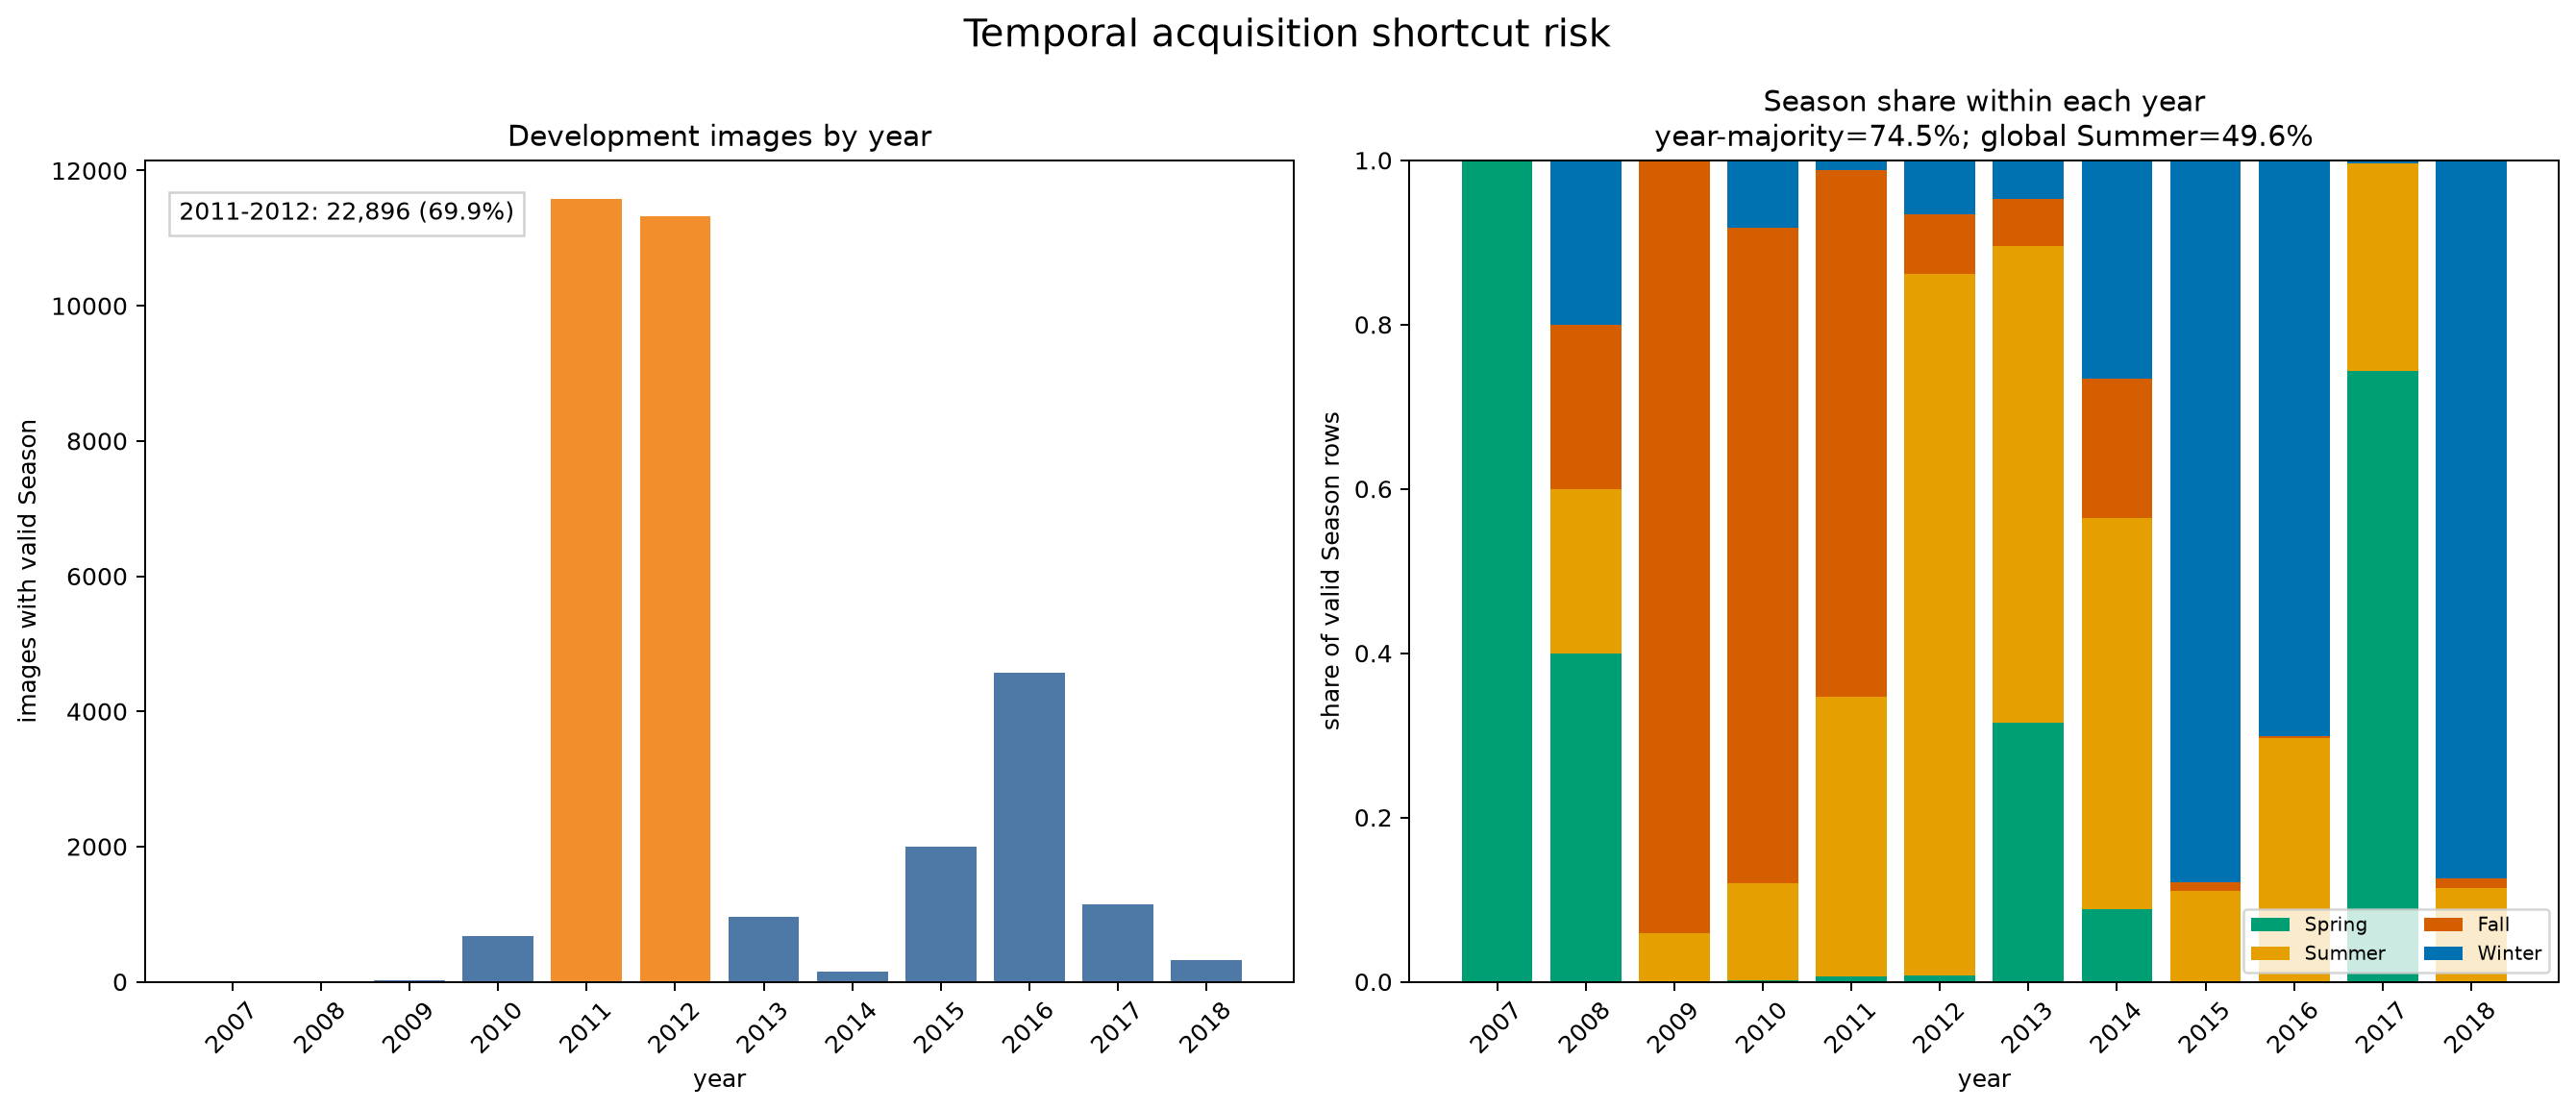

In [9]:
from IPython.display import Image, display

display(Image(filename=str(eda_figure_paths["acquisition shortcut"])))

> **Interpretation — Acquisition-year shortcut risk**
>
> **Chart guide.** The left bars show labelled development-image counts by acquisition year. The right 100% stacked bars show the Season mix inside each year; colours are Season labels, so a nearly single-colour bar means year alone is highly predictive for that small time slice.
>
> **Deep analysis.** 2011-2012 contain `22,896` images, or `69.9%` of the valid development set, so those two years dominate any pooled statistic. The Season mix also changes sharply by year: the chart reports a `74.5%` year-majority shortcut versus `49.6%` for the global Summer majority. Sparse years such as 2007-2009 look almost pure, but their tiny support makes them unstable evidence.
>
> **Decision and limitation.** Year is a plausible collection-process shortcut, so later OOF analysis must compare dominant 2011-2012 rows with other years. It remains post-prediction metadata; the plot does not show that year causes Season or that a model actually uses year-related pixels.

#### 2.2.4 File-size shortcut evidence

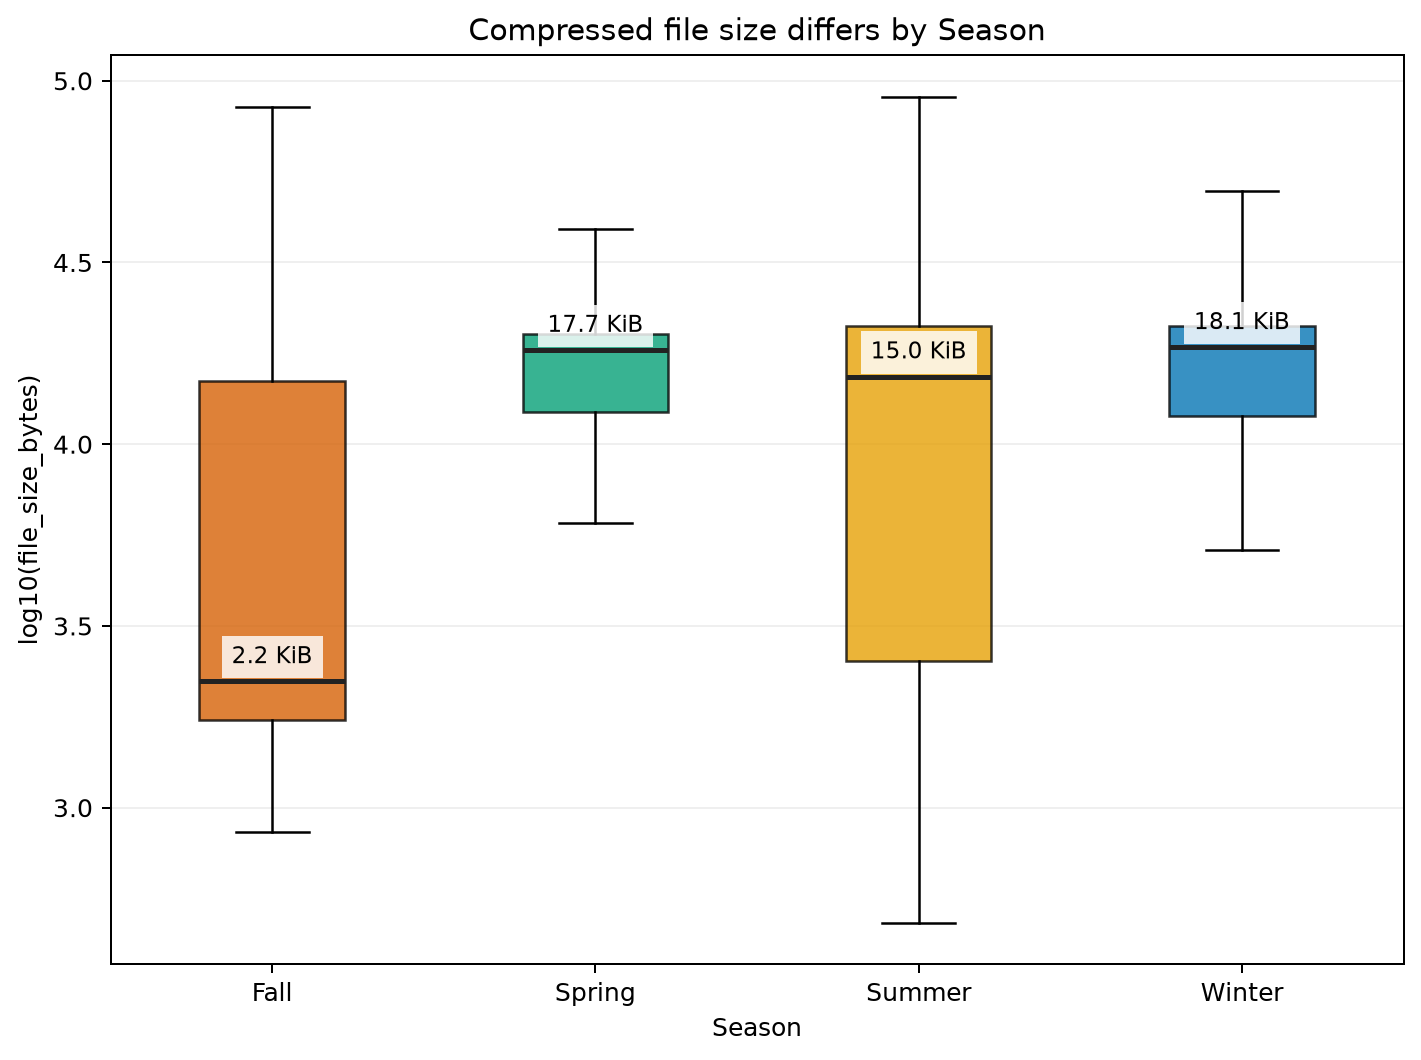

In [10]:
from IPython.display import Image, display

display(Image(filename=str(eda_figure_paths["file-size shortcut"])))

> **Interpretation — Compressed-file-size shortcut risk**
>
> **Chart guide.** Each box shows the distribution of `log10(file_size_bytes)` for one Season; the centre line is the median, the box is the middle 50%, and whiskers show the broader range. The labels translate each median back to KiB for easier reading.
>
> **Deep analysis.** Fall has a median of only `2.2 KiB`, while Spring, Summer, and Winter are about `17.7`, `15.0`, and `18.1 KiB`. The very large separation makes file size a credible proxy for acquisition or compression style. The wide Fall and Summer boxes also show substantial overlap, so file size is not a clean Season rule.
>
> **Decision and limitation.** Fit file-size quartile boundaries on training folds and inspect OOF performance by quartile. Do not use byte size as an inference feature: it may encode the data pipeline rather than garment Season.

#### 2.2.5 ArticleType shortcut evidence

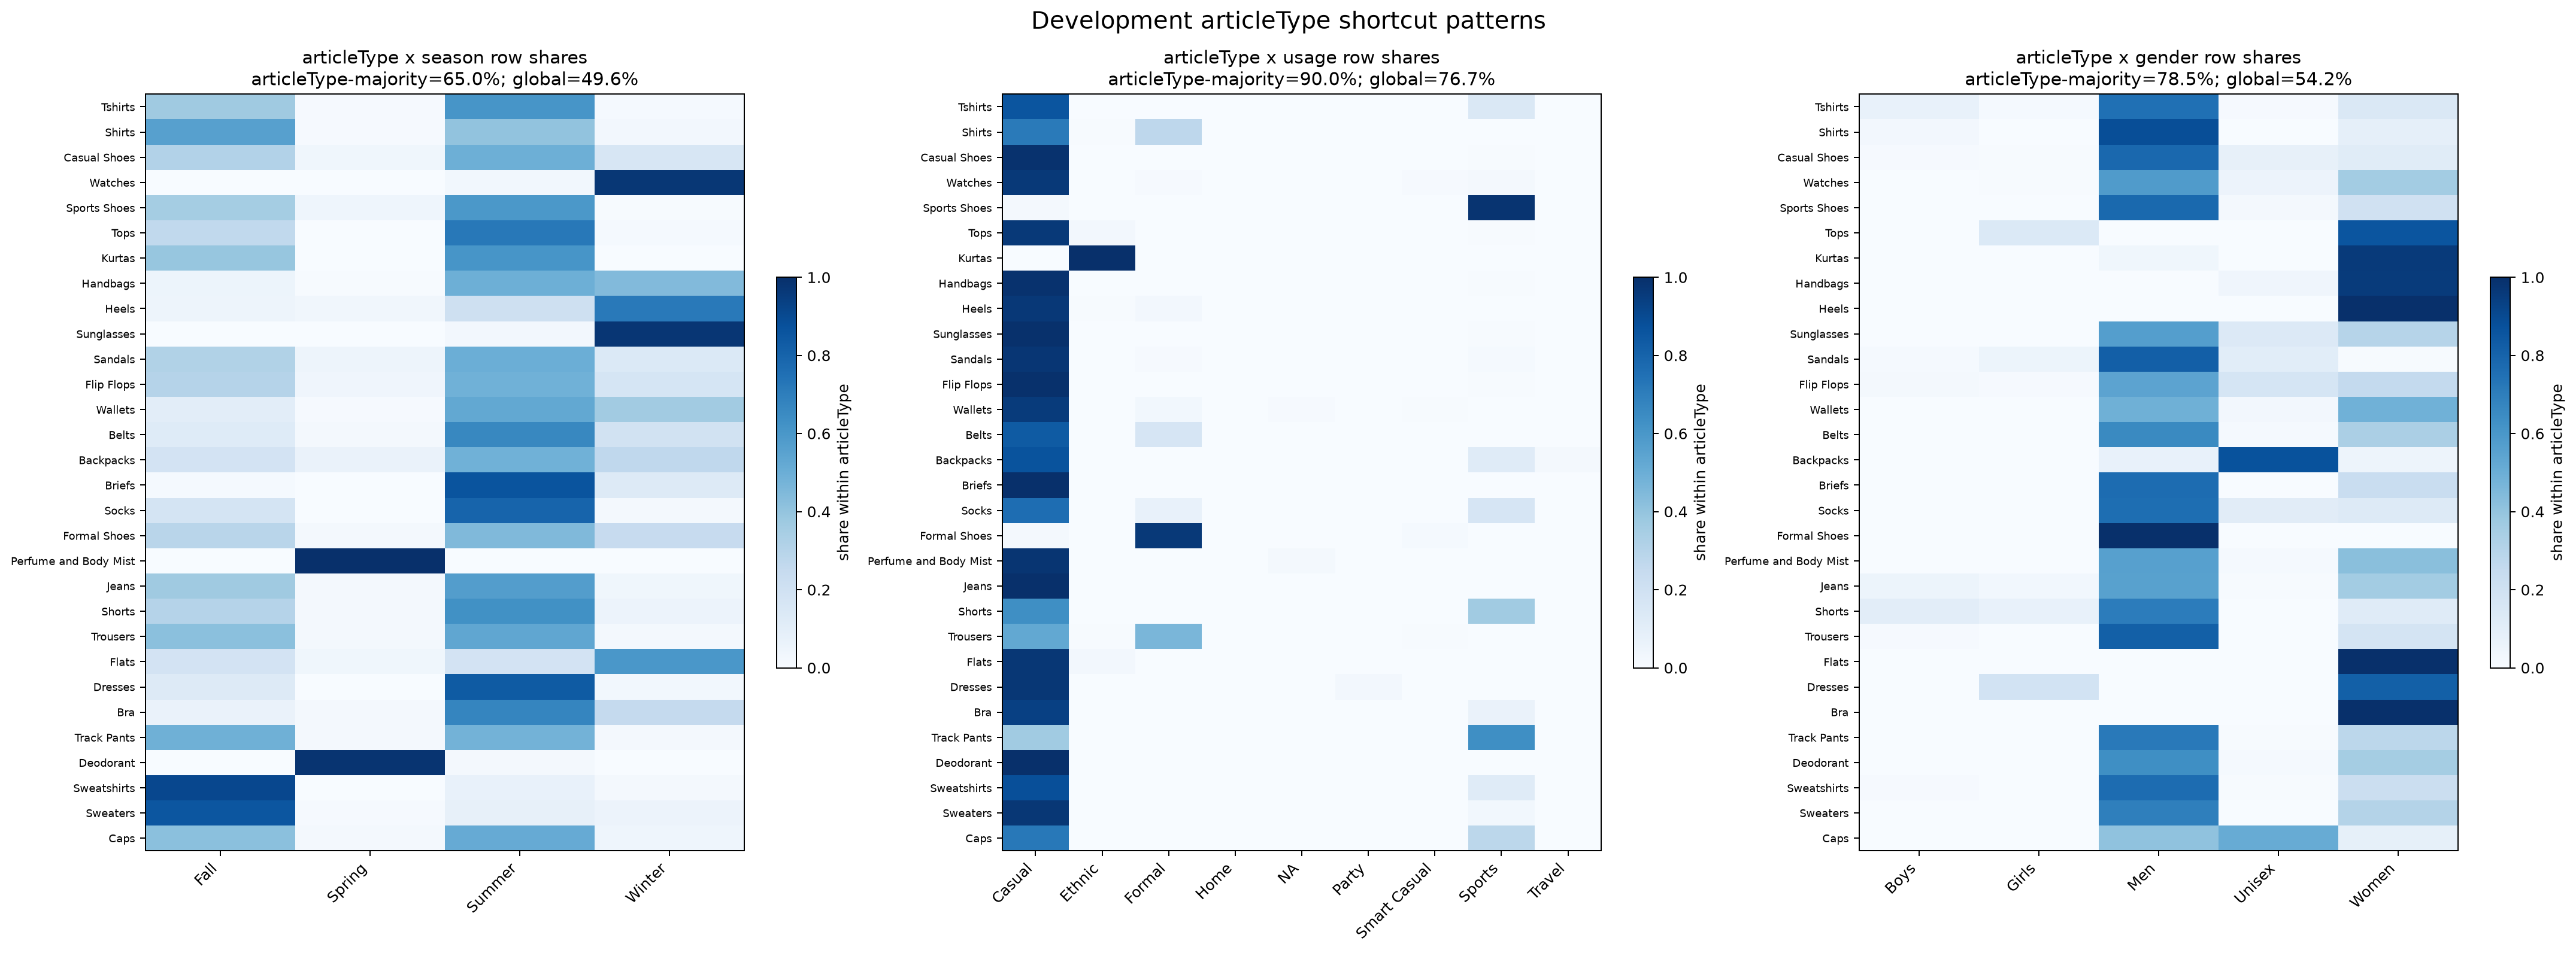

In [11]:
from IPython.display import Image, display

display(Image(filename=str(eda_figure_paths["ArticleType shortcut"])))

> **Interpretation — ArticleType association risk**
>
> **Chart guide.** Rows are common ArticleTypes and columns are target labels. Darker cells mean a larger within-ArticleType share. The left heatmap is the relevant ArticleType-by-Season panel; the usage and gender panels provide context for how strongly metadata fields can co-vary.
>
> **Deep analysis.** The Season panel reports `65.0%` ArticleType-majority accuracy versus the `49.6%` global-majority anchor. Some rows are almost single-season—for example Watches are mostly Winter and Perfume/Body Mist is almost entirely Spring—while Tshirts and Casual Shoes are spread across several Seasons. That pattern can help auxiliary learning, but it can also create a shortcut that fails on ArticleType-Season conflicts.
>
> **Decision and limitation.** Use ArticleType only as a masked training-time auxiliary target in I2, never as an inference input. Later analysis must separate aligned, conflict, and unseen ArticleType rows before accepting an I2 gain.

#### 2.2.6 Transform-risk evidence

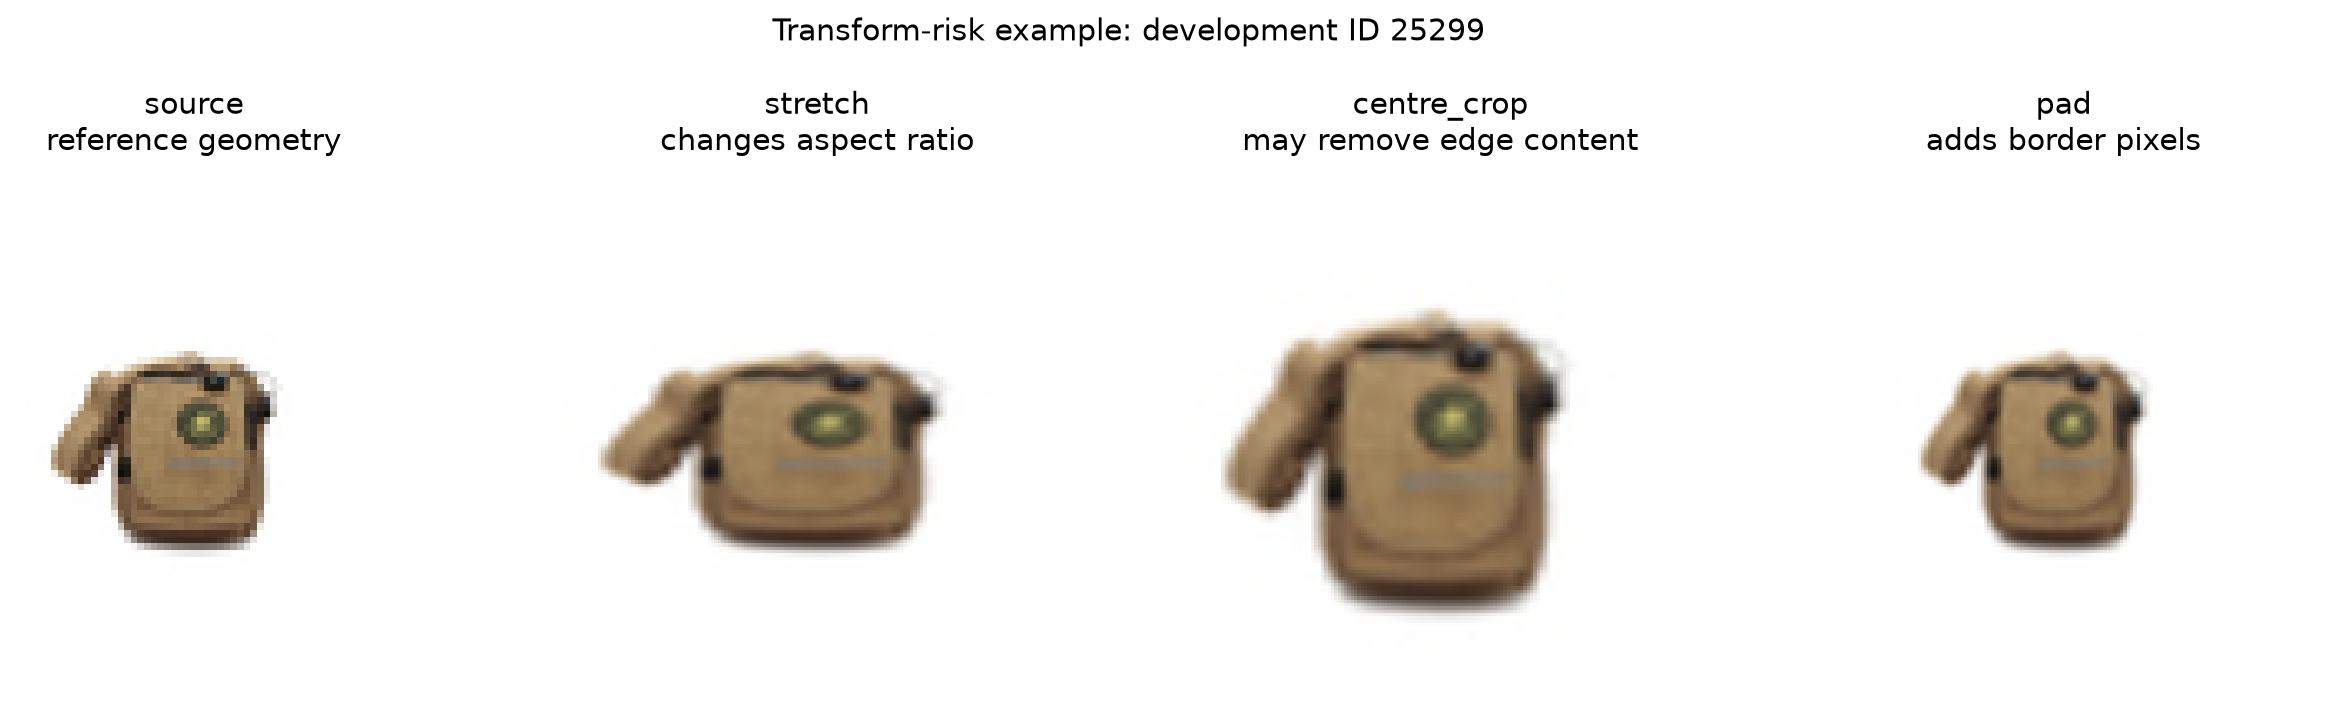

In [12]:
from IPython.display import Image, display

display(Image(filename=str(eda_figure_paths["transform risk"])))

> **Interpretation — Geometry-preserving transform choice**
>
> **Chart guide.** The four panels show the same development image under source geometry, stretching, centre cropping, and aspect-preserving padding. Compare garment proportions, edge content, and newly introduced border pixels rather than image sharpness alone.
>
> **Deep analysis.** Stretching makes the bag wider and changes its visual geometry. Centre cropping enlarges the object but can remove edge content. Padding keeps the bag's proportions and all visible content, at the cost of artificial border pixels. For this image, padding is the only option that preserves both shape and coverage.
>
> **Decision and limitation.** Use aspect-preserving resize plus padding, and exclude padding from fitted mean/std through a content mask. This single example motivates the rule but does not establish the best resolution; P0 versus P1 still needs a controlled OOF ablation.

## 3. Development-validation protocol

Use all five canonical folds and create one out-of-fold prediction per valid product.

### 3.1 Build the five canonical fold views

Every candidate must see exactly the same training and validation rows.

In [13]:
from fashion.data.dataset import iter_cv_folds

fold_frames = {}
fold_rows = []
for fold, training_all, validation_all in iter_cv_folds(splits):
    training = get_samples(training_all, target=TASK2_TARGET).reset_index(drop=True)
    validation = get_samples(validation_all, target=TASK2_TARGET).reset_index(drop=True)
    family_overlap = set(training["product_family_group"]) & set(validation["product_family_group"])
    assert not family_overlap
    assert set(training[TASK2_TARGET]) == set(validation[TASK2_TARGET]) == set(SEASON_LABELS)
    fold_frames[fold] = {"training": training, "validation": validation}
    fold_rows.append(
        {
            "validation_fold": fold,
            "training_products": len(training),
            "validation_products": len(validation),
            "training_families": training["product_family_group"].nunique(),
            "validation_families": validation["product_family_group"].nunique(),
            "training_classes": training[TASK2_TARGET].nunique(),
            "validation_classes": validation[TASK2_TARGET].nunique(),
            "family_crossings": len(family_overlap),
        }
    )
fold_handoff = pd.DataFrame(fold_rows)
assert len(fold_handoff) == 5
assert fold_handoff["validation_products"].sum() == len(season_development)
atomic_write_csv(TASK2_EVIDENCE_DIR / "fold_handoff.csv", fold_handoff)
display(fold_handoff)

,validation_fold,training_products,validation_products,training_families,validation_families,training_classes,validation_classes,family_crossings
0,0,26203,6550,18324,4561,4,4,0
1,1,26202,6551,18297,4588,4,4,0
2,2,26203,6550,18311,4574,4,4,0
3,3,26203,6550,18288,4597,4,4,0
4,4,26201,6552,18320,4565,4,4,0


> **Interpretation — Five-fold handoff**
>
> **Column guide.** Each row is one `validation_fold`. `training_products` and `validation_products` show the disjoint sample sizes; the family columns count product-family groups; class columns must both equal four; `family_crossings` must be zero. Read all rows together—never choose the strongest-looking fold.
>
> **Deep analysis.** Validation sizes are tightly balanced at `6,550-6,552`, and their sum is exactly `32,753`. Every training and validation partition contains all four Season classes. Most importantly, every row has `family_crossings=0`, so related products do not appear on both sides of the same fold.
>
> **Decision and limitation.** Pool one prediction from each validation fold to compare models. Fold-to-fold spread is uncertainty evidence, not permission to report only the best fold.

### 3.2 Freeze the OOF coverage contract

Pooled evidence is valid only when each product is predicted outside its training data exactly once.

In [14]:
from fashion.train.artifacts import canonical_sha256

expected_oof_index = season_development[
    ["id", "cv_fold", TASK2_TARGET, "product_family_group"]
].copy()
protected_ids = set(splits.loc[protected, "id"].astype(int))
assert expected_oof_index["id"].is_unique
assert not (set(expected_oof_index["id"].astype(int)) & protected_ids)
assert set(expected_oof_index[TASK2_TARGET]) == set(SEASON_LABELS)

oof_probability_columns = [f"prob_{label}" for label in SEASON_LABELS]
oof_contract = {
    "schema_version": "1.0.0",
    "expected_row_count": len(expected_oof_index),
    "expected_unique_ids": len(expected_oof_index),
    "expected_id_sha256": canonical_sha256(sorted(expected_oof_index["id"].astype(int))),
    "required_columns": ["id", "fold", "y_true", "y_pred", *oof_probability_columns],
    "labels": list(SEASON_LABELS),
    "probability_rule": "finite values in [0,1], four columns present, each row sums to one",
    "coverage_rule": (
        "each valid development ID appears exactly once; "
        "protected IDs appear zero times"
    ),
    "validator": "fashion.train.metrics.validate_oof",
}
atomic_write_json(TASK2_EVIDENCE_DIR / "oof_contract.json", oof_contract)
display(pd.Series(oof_contract, name="OOF contract").to_frame())

,OOF contract
schema_version,1.0.0
expected_row_count,32753
expected_unique_ids,32753
expected_id_sha256,6f8540aff2511b2d63e23bea6d5aad24060cbbf3f352d4...
required_columns,"[id, fold, y_true, y_pred, prob_Fall, prob_Spr..."
labels,"[Fall, Spring, Summer, Winter]"
probability_rule,"finite values in [0,1], four columns present, ..."
coverage_rule,each valid development ID appears exactly once...
validator,fashion.train.metrics.validate_oof


> **Interpretation — OOF prediction contract**
>
> **Column guide.** The index lists contract fields and the value column gives the requirement. `expected_row_count`/`expected_unique_ids` define coverage; `expected_id_sha256` fingerprints the exact products; `required_columns` and `labels` define schema; probability and coverage rules define numerical validity.
>
> **Deep analysis.** A valid experiment must contain `32,753` unique development IDs exactly once, four probability columns in the frozen class order, finite probabilities summing to one, and zero protected IDs. The ID hash makes a table with the right row count but the wrong products fail verification.
>
> **Decision and limitation.** Use pooled OOF predictions as the common comparison unit because every score is produced on rows unseen by that fold's model. Training, validation, or holdout rows cannot be substituted into this contract.

### 3.3 Freeze metrics and selection rules

Metrics must be declared before candidate results are visible.

In [15]:
metric_contract = {
    "schema_version": "1.0.0",
    "primary_metric": "pooled five-fold OOF macro-F1",
    "labels": list(SEASON_LABELS),
    "zero_division": 0,
    "secondary_metrics": [
        "fold macro-F1 mean and standard deviation",
        "per-class precision, recall, F1, and support",
        "balanced accuracy and accuracy",
        "count and row-normalised confusion matrices",
        "NLL, multiclass Brier score, ECE, and risk-coverage",
        "model size, parameter count, latency, RAM, and VRAM",
    ],
    "uncertainty": "10,000 paired bootstrap samples grouped by product_family_group",
    "near_tie_macro_f1_points": 0.5,
    "near_tie_requires_ci_to_contain_zero": True,
    "smaller_model_robustness_tolerance_points": 1.0,
    "winner_rule": (
        "quality first; then robustness, calibration, and deployment cost; "
        "never accuracy alone"
    ),
}
atomic_write_json(TASK2_EVIDENCE_DIR / "metric_contract.json", metric_contract)
display(pd.Series(metric_contract, name="Metric contract").to_frame())

,Metric contract
schema_version,1.0.0
primary_metric,pooled five-fold OOF macro-F1
labels,"[Fall, Spring, Summer, Winter]"
zero_division,0
secondary_metrics,"[fold macro-F1 mean and standard deviation, pe..."
uncertainty,"10,000 paired bootstrap samples grouped by pro..."
near_tie_macro_f1_points,0.5
near_tie_requires_ci_to_contain_zero,True
smaller_model_robustness_tolerance_points,1.0
winner_rule,"quality first; then robustness, calibration, a..."


> **Interpretation — Metric and winner contract**
>
> **Column guide.** Read `primary_metric` first; it controls ranking. `secondary_metrics` lists diagnostics, `uncertainty` defines the grouped bootstrap, and the near-tie/tolerance fields define when efficiency can break a quality tie. `winner_rule` states the final order of evidence.
>
> **Deep analysis.** Pooled five-fold OOF macro-F1 is primary, so the `1,329` Spring rows receive the same class weight as the `16,235` Summer rows. Accuracy, per-class precision/recall/F1, calibration, robustness, and cost answer different questions and cannot silently replace the primary metric. A `0.5` point near tie requires an interval containing zero before model size becomes the tiebreaker.
>
> **Decision and limitation.** Apply this rule before seeing candidate results. Macro-F1 handles class imbalance, but it does not reveal confidence quality, subgroup failure, or deployment cost; those remain required secondary evidence.

## 4. Preprocessing and leakage controls

Fit every learned image value inside the current training folds and keep diagnostic metadata out of the model input.

### 4.1 Fit and inspect the fold-specific image pipeline

Aspect ratio and training-only statistics protect the small 60 x 80 images from distortion and leakage.

In [16]:
import io

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image as PILImage

from fashion.data.images import transform_image_with_mask
from fashion.data.torch import build_task_loaders
from fashion.train.artifacts import atomic_write_bytes

fold0_loaders = build_task_loaders(
    validation_fold=0,
    image_size=(80, 60),
    batch_size=8,
    validation_batch_size=8,
    target=TASK2_TARGET,
    augmentation="a0",
    seed=RANDOM_SEED,
    num_workers=0,
)
validation_batch = next(iter(fold0_loaders.validation))
mean = torch.tensor(fold0_loaders.stats.mean).view(1, 3, 1, 1)
std = torch.tensor(fold0_loaders.stats.std).view(1, 3, 1, 1)
display_images = (validation_batch["image"] * std + mean).clamp(0, 1)

validation_frame = fold_frames[0]["validation"]
nonstandard_aspect = validation_frame.loc[
    ~np.isclose(validation_frame["width"] / validation_frame["height"], 60 / 80)
]
assert not nonstandard_aspect.empty
first_row = nonstandard_aspect.iloc[0]
with PILImage.open(ROOT / first_row["path"]) as source:
    _, first_content_mask = transform_image_with_mask(source, image_size=(80, 60))
assert first_content_mask.any() and (~first_content_mask).any()

figure, axes = plt.subplots(2, 4, figsize=(12, 7))
for axis, image, target, item_id in zip(
    axes.flat[:6],
    display_images[:6],
    validation_batch["target"][:6],
    validation_batch["id"][:6],
    strict=True,
):
    axis.imshow(np.moveaxis(image.numpy(), 0, -1))
    axis.set_title(f"ID {int(item_id)} | {fold0_loaders.labels[int(target)]}")
    axis.axis("off")
axes.flat[6].imshow(first_content_mask, cmap="gray", vmin=0, vmax=1)
axes.flat[6].set_title("Content-pixel mask")
axes.flat[6].axis("off")
axes.flat[7].axis("off")
figure.suptitle("Fold 0 validation transform: aspect preserved, training-fitted normalisation")
figure.tight_layout()
preprocessing_figure_path = TASK2_FIGURE_DIR / "fold0_preprocessing_audit.png"
buffer = io.BytesIO()
figure.savefig(buffer, format="png", dpi=160, bbox_inches="tight")
atomic_write_bytes(preprocessing_figure_path, buffer.getvalue())
plt.close(figure)
preprocessing_summary = {
    **fold0_loaders.audit(),
    "batch_shape": tuple(validation_batch["image"].shape),
}
display(pd.Series(preprocessing_summary).to_frame("value"))

,value
validation_fold,0
training_products,26203
validation_products,6550
id_overlap,0
labels,"[Fall, Spring, Summer, Winter]"
train_transform_id,a0-7dba8a62f166046d
validation_transform_id,none-a5c77e91d532150f
stats,"{'validation_fold': 0, 'image_size': (80, 60),..."
batch_shape,"(8, 3, 80, 60)"


> **Interpretation — Fold-fitted preprocessing audit**
>
> **Column guide.** The value column reports the loader's fold, image size, fitted mean/std, training-ID hash, transform ID, and batch shape. `validation_fold=0` means all learned normalisation statistics came from the other four folds. Batch shape should read `(8, 3, 80, 60)` for this audit.
>
> **Deep analysis.** The audit confirms a fold-0 validation batch at `80x60`, with three channels and training-fitted statistics. The separate content-pixel count and training-ID hash matter because padding is excluded from mean/std; otherwise the white borders would make the data appear brighter and less variable than the garments.
>
> **Decision and limitation.** Reuse the fitted statistics only for that fold's validation data. This output proves preprocessing lineage, not that P0 resolution or A0 augmentation is optimal.

#### 4.1.1 Preprocessing audit figure

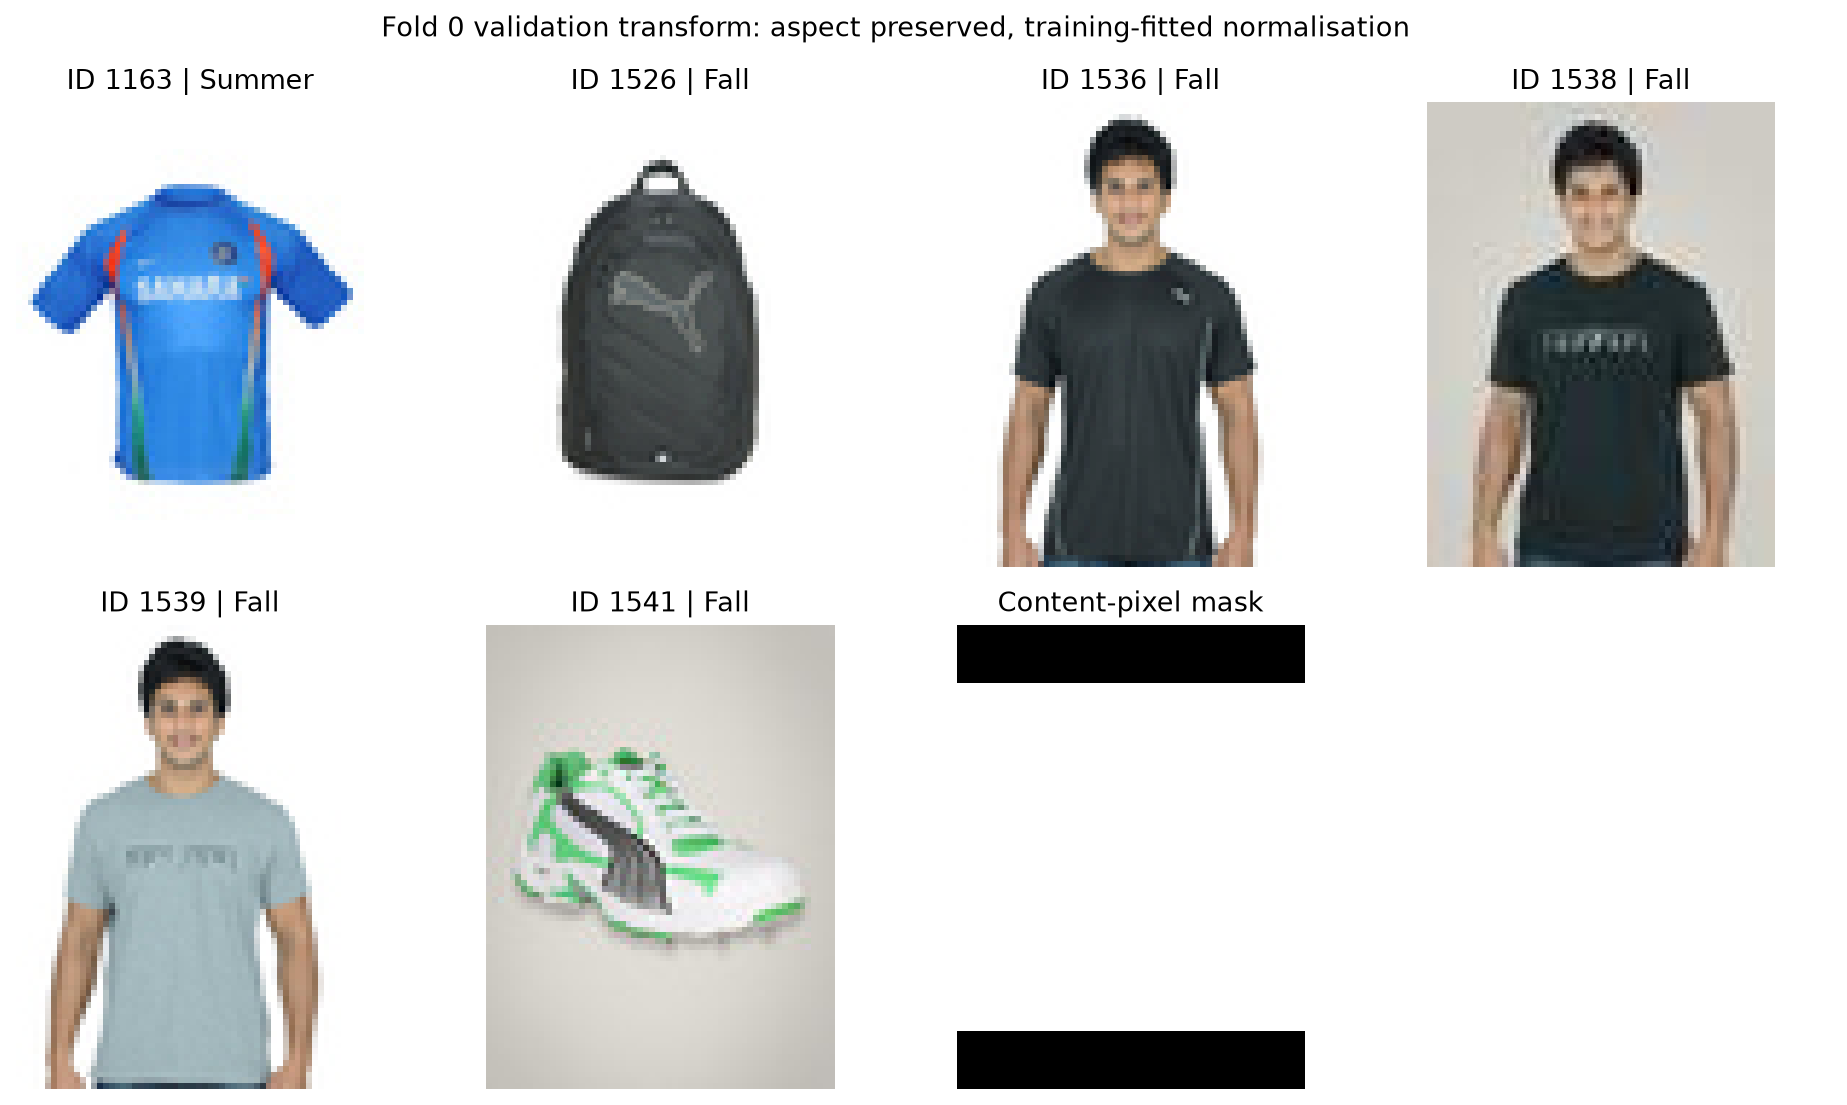

In [17]:
from IPython.display import Image, display

display(Image(filename=str(preprocessing_figure_path)))

> **Interpretation — Preprocessing visual audit**
>
> **Chart guide.** The first six panels are denormalised fold-0 validation images labelled by ID and Season. The seventh panel is the binary content mask: white pixels are real resized content and black pixels are padding excluded from fitted statistics.
>
> **Deep analysis.** Garment proportions remain natural rather than stretched, and no edge content is cropped. The mask contains both real and padded pixels, which confirms that this non-standard aspect-ratio example exercises the intended padding path. The white background is mostly genuine catalogue background; only masked border pixels are excluded from normalisation.
>
> **Decision and limitation.** The visual check supports aspect-preserving padding and content-only statistics. It is a small sanity sample, so numerical transform hashes and the P0/P1 ablation remain the stronger evidence.

### 4.2 Declare the controlled transform comparison

P0/P1 and A0/A1 answer whether upscaling and mild colour change help without changing the model budget.

In [18]:
from fashion.data.torch import ImageTransformSpec

transform_rows = []
for config_id, image_size, augmentation, gate, eligibility in (
    ("P0_A0", (80, 60), "a0", "input-size", "always"),
    ("P1_A0", (128, 96), "a0", "input-size", "always"),
    ("P0_A1", (80, 60), "a1", "augmentation", "only if P0_A0 wins size gate"),
    ("P1_A1", (128, 96), "a1", "augmentation", "only if P1_A0 wins size gate"),
):
    spec = ImageTransformSpec(image_size=image_size, augmentation=augmentation)
    transform_rows.append(
        {
            "config_id": config_id,
            "gate": gate,
            "image_size": str(image_size),
            "augmentation": augmentation,
            "transform_id": spec.transform_id,
            "model_family": "resnet18_small_stem",
            "seed": RANDOM_SEED,
            "folds": "0,1,2,3,4",
            "screen_epochs": 8,
            "eligibility": eligibility,
        }
    )
transform_matrix = pd.DataFrame(transform_rows)
assert transform_matrix[["model_family", "seed", "folds", "screen_epochs"]].nunique().eq(1).all()
atomic_write_csv(TASK2_EVIDENCE_DIR / "transform_matrix.csv", transform_matrix)
display(transform_matrix)

,config_id,gate,image_size,augmentation,transform_id,model_family,seed,folds,screen_epochs,eligibility
0,P0_A0,input-size,"(80, 60)",a0,a0-7dba8a62f166046d,resnet18_small_stem,2753,"0,1,2,3,4",8,always
1,P1_A0,input-size,"(128, 96)",a0,a0-a8878a801aa0d46e,resnet18_small_stem,2753,"0,1,2,3,4",8,always
2,P0_A1,augmentation,"(80, 60)",a1,a1-fe8cc596054e42b2,resnet18_small_stem,2753,"0,1,2,3,4",8,only if P0_A0 wins size gate
3,P1_A1,augmentation,"(128, 96)",a1,a1-f127f22d8b93e7f0,resnet18_small_stem,2753,"0,1,2,3,4",8,only if P1_A0 wins size gate


> **Interpretation — Controlled transform matrix**
>
> **Column guide.** Compare rows only within the named `gate`. P0/P1 change `image_size`; A0/A1 change `augmentation`. `model_family`, `seed`, `folds`, and `screen_epochs` are held fixed. `eligibility` prevents testing an augmentation at a resolution that already lost its gate.
>
> **Deep analysis.** P0_A0 (`80x60`) and P1_A0 (`128x96`) isolate resolution under the same small-stem ResNet18, seed `2753`, all five folds, and eight epochs. The A1 rows add colour jitter only after the corresponding size survives. Unique `transform_id` values make cached runs from different pixel pipelines impossible to mix.
>
> **Decision and limitation.** Run the gates in order: size first, then augmentation at the winning size. This table is an experiment design; it contains no performance evidence and must not be used to pre-select a winner.

### 4.3 Run the leakage and transform audit

Year, file size, and true ArticleType can define later slices but must never enter the inference tensor.

In [19]:
import inspect

from fashion.models.season import SeasonModelSpec, assert_final_model, build_season_model

audit_model = build_season_model(SeasonModelSpec(family="smallcnn"))
model_boundary = assert_final_model(audit_model)
dataset_keys = set(fold0_loaders.validation.dataset[0])
first_validation = fold0_loaders.validation.dataset[0]["image"]
second_validation = fold0_loaders.validation.dataset[0]["image"]
forward_inputs = list(inspect.signature(audit_model.forward).parameters)
forbidden_inputs = {"year", "file_size_bytes", "articleType", "season", "cv_fold", "partition"}

leakage_checks = {
    "dataset exposes only id, image, and encoded target": dataset_keys == {"id", "image", "target"},
    "model forward accepts images only": forward_inputs == ["images"],
    "forbidden metadata absent from model inputs": not (dataset_keys & forbidden_inputs),
    "validation transform is deterministic": torch.equal(first_validation, second_validation),
    "normalisation fitted on fold-0 training IDs": fold0_loaders.stats.validation_fold == 0,
    "training and validation IDs do not overlap": not (
        set(fold0_loaders.training_ids) & set(fold0_loaders.validation_ids)
    ),
    "protected labels remain sealed": visible_protected_labels == visible_protected_masks == 0,
    "audit model is scratch and final-eligible": (
        model_boundary["training_origin"] == "scratch"
        and model_boundary["final_eligible"]
    ),
}
assert all(leakage_checks.values())
leakage_audit = {
    "schema_version": "1.0.0",
    "validation_fold": 0,
    "checks": leakage_checks,
    "forbidden_inference_fields": sorted(forbidden_inputs),
    "model_boundary": model_boundary,
}
atomic_write_json(TASK2_EVIDENCE_DIR / "leakage_audit.json", leakage_audit)
display(pd.DataFrame(leakage_checks.items(), columns=["check", "passed"]))

,check,passed
0,"dataset exposes only id, image, and encoded ta...",True
1,model forward accepts images only,True
2,forbidden metadata absent from model inputs,True
3,validation transform is deterministic,True
4,normalisation fitted on fold-0 training IDs,True
5,training and validation IDs do not overlap,True
6,protected labels remain sealed,True
7,audit model is scratch and final-eligible,True


> **Interpretation — Leakage boundary audit**
>
> **Column guide.** Each `check` is one possible leakage path and `passed` is the enforced Boolean result. Read the input-interface checks separately from split/statistics checks: a model can be image-only yet still leak through duplicated families or validation-fitted normalisation.
>
> **Deep analysis.** All eight checks pass. The dataset exposes only `id`, image, and encoded target; model `forward` accepts images only; validation transforms are deterministic; fold statistics use training IDs; train/validation IDs do not overlap; protected labels remain sealed; and the audited final candidate is scratch-trained. Year, file size, ArticleType, partition, and fold stay available only outside the forward pass for later error slicing.
>
> **Decision and limitation.** Passing this audit establishes an allowed data path, not model quality. Any future metadata input or new split function must fail this boundary before training starts.

## 5. Baselines

Establish simple comparison anchors before interpreting deep models.

### 5.1 B0 training-fold majority baseline

B0 is selected first because it is the simplest leakage-safe predictor: each fold uses only the class distribution of its four training folds. Its strength is that it cheaply checks split handling and turns the EDA imbalance warning into a measurable lower bound. Its known limitation is complete image blindness; that limitation directly motivates B1.

In [20]:
from fashion.config import RUNS_CSV, TASK2_CONFIG_DIR
from fashion.task2.evidence import build_experiment_evidence
from fashion.task2.experiments import run_or_load_experiment

b0_outputs = run_or_load_experiment(
    TASK2_CONFIG_DIR / "b0_majority.json",
    mode="run_or_load",
)
b0_manifest = build_experiment_evidence(
    b0_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=(
        "Each validation product receives empirical Season priors fitted only on "
        "the other four training folds; these are valid probabilistic baseline "
        "outputs, not image-conditioned confidence."
    ),
    calibration_claim_allowed=True,
    evidence_directory=TASK2_EVIDENCE_DIR / "b0_majority",
    figure_directory=TASK2_FIGURE_DIR,
)
assert b0_manifest["coverage"]["row_count"] == len(season_development)
assert b0_manifest["coverage"]["protected_id_count"] == 0
assert len(b0_manifest["run_ids"]) == len(set(b0_manifest["run_ids"])) == 5

with (ROOT / b0_manifest["artifacts"]["pooled_metrics"]["path"]).open(
    encoding="utf-8"
) as handle:
    b0_pooled_metrics = json.load(handle)
b0_fold_summary = pd.read_csv(
    ROOT / b0_manifest["artifacts"]["fold_summary"]["path"]
)
b0_scorecard = pd.DataFrame(
    [{
        "experiment_id": b0_manifest["experiment_id"],
        "OOF products": b0_pooled_metrics["n_samples"],
        "accuracy": b0_pooled_metrics["accuracy"],
        "balanced_accuracy": b0_pooled_metrics["balanced_accuracy"],
        "macro_f1": b0_pooled_metrics["macro_f1"],
        "Spring_f1": b0_pooled_metrics["per_class"]["Spring"]["f1"],
        "run_ids": " | ".join(b0_manifest["run_ids"]),
    }]
)
display(b0_scorecard)


# Additional single-output views rendered below:
# display(b0_fold_summary.loc[b0_fold_summary["metric"].eq("macro_f1")])
# display(Image(filename=str(ROOT / b0_manifest["artifacts"]["figure"]["path"])))


,experiment_id,OOF products,accuracy,balanced_accuracy,macro_f1,Spring_f1,run_ids
0,b0-majority,32753,0.49568,0.25,0.165704,0.0,b0-majority-f0-s2753-7c18ce1e2b33 | b0-majorit...


> **Interpretation — B0 majority scorecard**
>
> **Column guide.** The single row is the B0 experiment. Start with `OOF products` to verify coverage, then contrast accuracy with balanced accuracy and macro-F1; `Spring_f1` exposes minority failure, and `run_ids` links the score to all five folds.
>
> **Deep analysis.** **Why this baseline:** B0 was selected first because a learning-free, training-fold-only majority predictor is the cleanest pipeline check and the honest lower bound implied by the EDA. **Result:** it covered all 32,753 valid development products once, with no protected IDs. It reached 49.568% accuracy but only `0.165704` pooled macro-F1 and `0.250000` balanced accuracy. It predicted Summer for every product: Summer F1 was `0.662815`, while Fall, Spring, and Winter F1 were all zero. Fold macro-F1 SD was only `0.000029`. **Strength:** B0 is cheap, deterministic, leakage-safe, and makes the accuracy illusion visible. Its near-zero ECE only shows that training-fold priors match pooled class frequency. **Limitation:** it ignores every image and cannot discriminate four seasons or recover Spring. **Incremental handoff:** B1 must test the next EDA claim - whether image shape and colour contain useful signal - and every learned model must beat `0.165704` macro-F1. **Trace:** `results/evidence/task2/b0_majority/manifest.json`; runs `b0-majority-f0-s2753-8200c51534e3`, `b0-majority-f1-s2753-7c378e67d9e6`, `b0-majority-f2-s2753-e50abeab2421`, `b0-majority-f3-s2753-b2fb197c26c1`, and `b0-majority-f4-s2753-b068532dab0a`.

#### 5.1a B0 fold-level macro-F1 table

In [21]:
from IPython.display import display

display(b0_fold_summary.loc[b0_fold_summary["metric"].eq("macro_f1")])

,metric,fold_mean,fold_sd,fold_min,fold_max,pooled_value
5,macro_f1,0.165704,0.000029,0.16568,0.165748,0.165704


> **Interpretation — B0 fold stability**
>
> **Column guide.** This is the `macro_f1` row of the fold summary. `fold_mean` is the average of five fold scores, `fold_sd` is their spread, `fold_min`/`fold_max` show the range, and `pooled_value` recomputes macro-F1 after concatenating every OOF row.
>
> **Deep analysis.** B0's pooled macro-F1 is only `0.165704`; the fold mean is the same to six decimals and SD is just `0.000029`. That near-zero spread is not evidence of a good model—it only shows that the Summer class proportion is almost identical across the five canonical folds.
>
> **Decision and limitation.** Keep B0 as the imbalance anchor. Any image model should beat `0.165704`, but improvement over B0 alone is too weak to justify a final model.

#### 5.1b B0 evidence figure

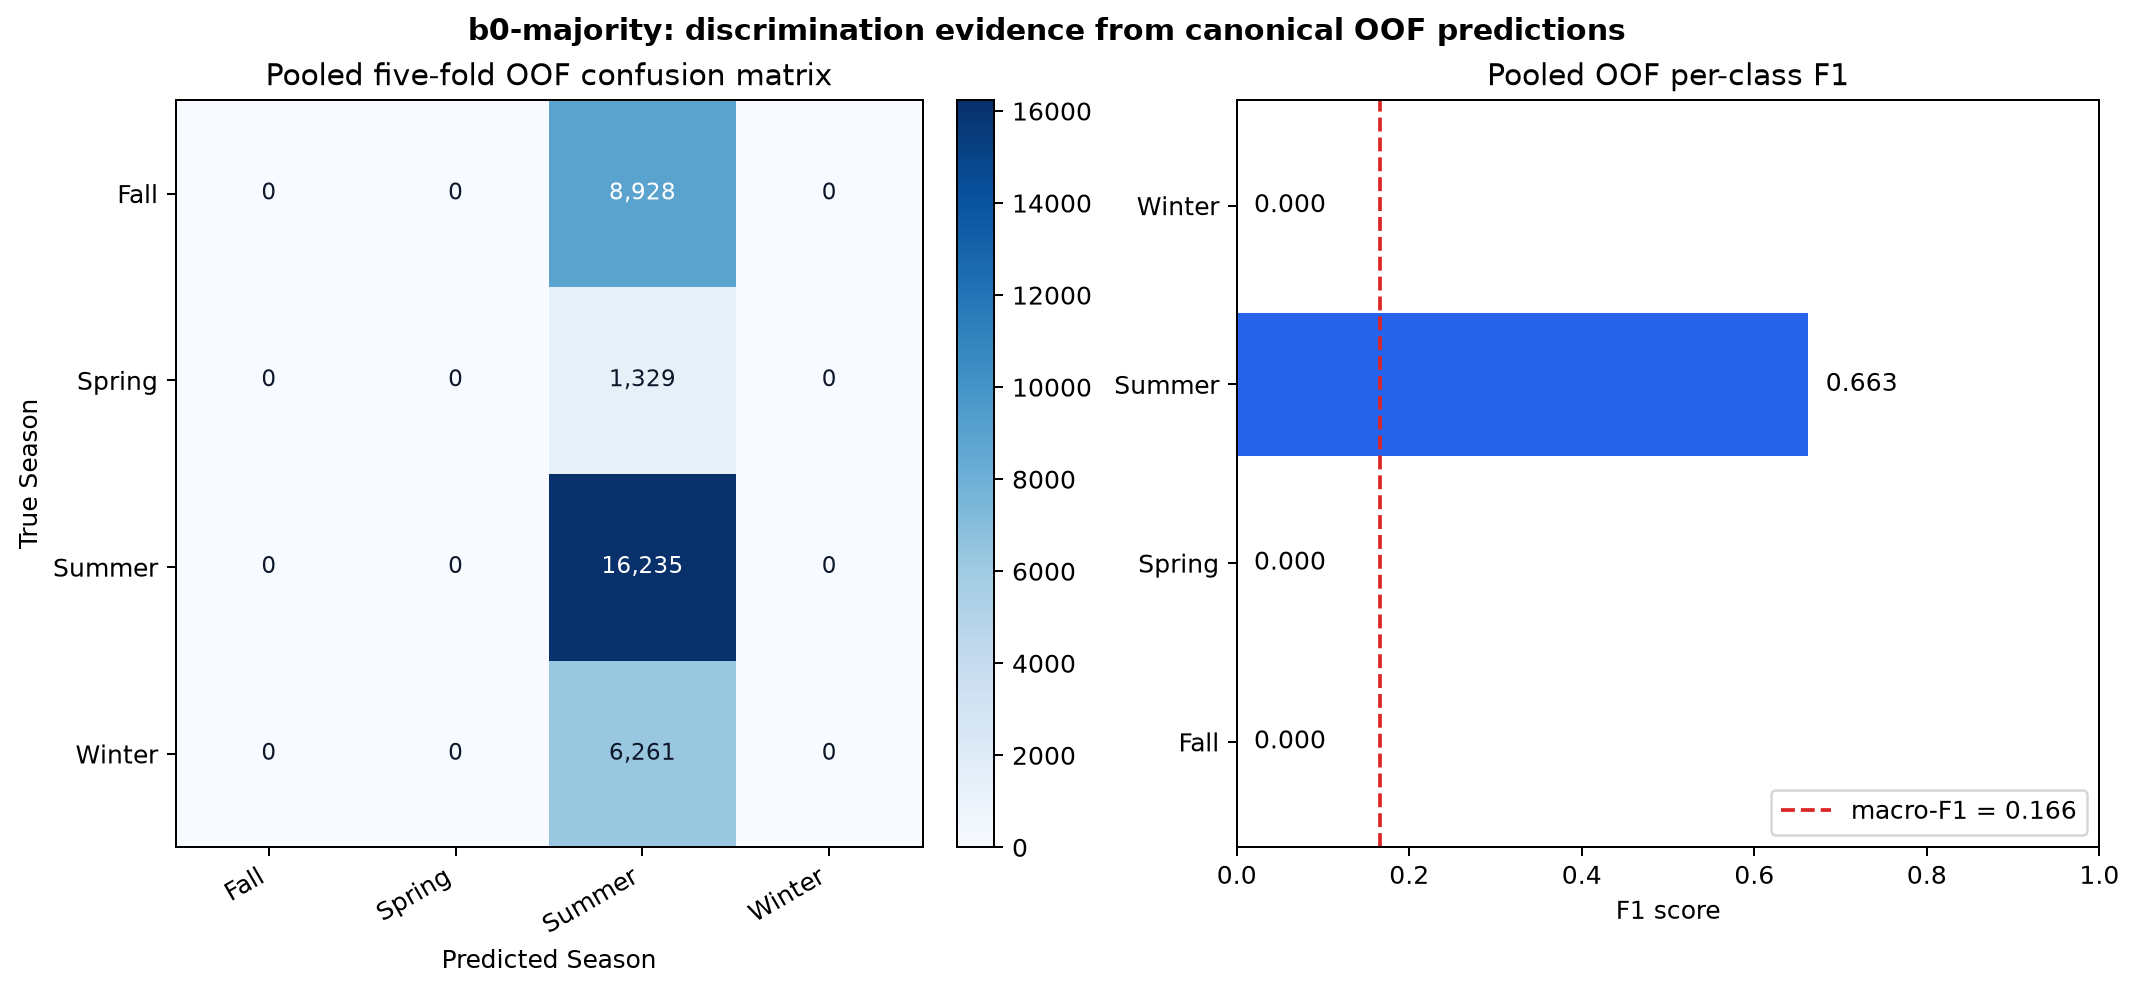

In [22]:
from IPython.display import Image, display

display(Image(filename=str(ROOT / b0_manifest["artifacts"]["figure"]["path"])))

> **Interpretation — B0 confusion and per-class F1**
>
> **Chart guide.** In the left matrix, rows are true Season and columns are predicted Season; values are OOF counts. The right bars are per-class F1, and the red dashed line is their macro average.
>
> **Deep analysis.** Every one of the `32,753` rows is predicted as Summer: `8,928` Fall, `1,329` Spring, and `6,261` Winter examples all flow into the Summer column. Summer F1 reaches `0.663` because all Summer rows are recalled, while Fall, Spring, and Winter F1 are exactly zero; their average is the `0.166` macro-F1 line.
>
> **Decision and limitation.** This visual proves why raw accuracy is unsafe: always predicting the largest class is about `49.6%` accurate yet ignores three classes. Later models must report macro-F1 and per-class errors.

### 5.2 B1 HOG plus HSV linear-SVM baseline

B1 is selected next because the EDA suggests that product shape and colour may carry Season signal. It is a serious, interpretable classical baseline: a CNN must improve on it, not merely beat the image-blind majority rule. Its fixed features and uncalibrated scores motivate C1.

In [ ]:
import threading
import time
from datetime import datetime, timezone

b1_progress_stop = threading.Event()


def _monitor_b1_progress() -> None:
    """Print one compact status line whenever the latest B1 fold state changes."""
    last_signature = None
    last_report_at = 0.0
    while not b1_progress_stop.wait(timeout=2.0):
        try:
            registry = pd.read_csv(RUNS_CSV, dtype="string").fillna("")
        except (OSError, pd.errors.EmptyDataError, pd.errors.ParserError):
            continue
        candidates = registry.loc[
            registry["experiment_id"].eq("b1-hog-hsv-svm")
            & registry["seed"].eq("2753")
        ].copy()
        if candidates.empty:
            continue
        latest_hash = (
            candidates.sort_values(["started_at_utc", "run_id"])
            .iloc[-1]["implementation_sha256"]
        )
        current = candidates.loc[
            candidates["implementation_sha256"].eq(latest_hash)
        ]
        current = (
            current.sort_values(["fold", "started_at_utc", "run_id"])
            .drop_duplicates("fold", keep="last")
        )
        signature = tuple(
            current.loc[:, ["fold", "status"]]
            .astype(str)
            .itertuples(index=False, name=None)
        )
        now = time.monotonic()
        if signature == last_signature and now - last_report_at < 30.0:
            continue
        last_signature = signature
        last_report_at = now
        completed = int(current["status"].eq("completed").sum())
        running = current.loc[current["status"].eq("running"), "fold"].tolist()
        state_labels = []
        for fold, status in signature:
            row = current.loc[current["fold"].astype(str).eq(str(fold))].iloc[-1]
            if status == "running":
                started = datetime.fromisoformat(
                    str(row["started_at_utc"]).replace("Z", "+00:00")
                )
                elapsed_seconds = max(
                    0.0,
                    (datetime.now(timezone.utc) - started).total_seconds(),
                )
            else:
                elapsed_seconds = float(row["runtime_seconds"] or 0.0)
            minutes, seconds = divmod(int(elapsed_seconds), 60)
            state_labels.append(
                f"fold {fold}: {status} ({minutes}m {seconds:02d}s)"
            )
        print(
            "B1 progress: "
            f"{completed}/5 folds completed; "
            f"running={running or 'none'}; {'; '.join(state_labels)}",
            flush=True,
        )


print(
    "B1 progress: checking the cache and preparing five HOG+HSV folds...",
    flush=True,
)
b1_progress_thread = threading.Thread(
    target=_monitor_b1_progress,
    name="task2-b1-progress",
    daemon=True,
)
b1_progress_thread.start()
try:
    b1_outputs = run_or_load_experiment(
        TASK2_CONFIG_DIR / "b1_hog_hsv_svm.json",
        mode="run_or_load",
    )
finally:
    b1_progress_stop.set()
    b1_progress_thread.join(timeout=3.0)
print(
    f"B1 progress: {len(b1_outputs)}/5 fold results ready; building evidence...",
    flush=True,
)
b1_manifest = build_experiment_evidence(
    b1_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=(
        "LinearSVC decision scores are transformed with row-wise softmax only "
        "to satisfy a common OOF storage schema. They are not calibrated "
        "probabilities, so B1 NLL, Brier, and ECE are descriptive diagnostics "
        "only and cannot support calibration claims."
    ),
    calibration_claim_allowed=False,
    evidence_directory=TASK2_EVIDENCE_DIR / "b1_hog_hsv_svm",
    figure_directory=TASK2_FIGURE_DIR,
)
assert b1_manifest["coverage"]["row_count"] == len(season_development)
assert b1_manifest["coverage"]["protected_id_count"] == 0
assert not b1_manifest["calibration_claim_allowed"]
assert len(b1_manifest["run_ids"]) == len(set(b1_manifest["run_ids"])) == 5

with (ROOT / b1_manifest["artifacts"]["pooled_metrics"]["path"]).open(
    encoding="utf-8"
) as handle:
    b1_pooled_metrics = json.load(handle)
b1_fold_summary = pd.read_csv(
    ROOT / b1_manifest["artifacts"]["fold_summary"]["path"]
)
b1_registry = pd.read_csv(
    ROOT / b1_manifest["artifacts"]["registry_snapshot"]["path"]
)
b1_scorecard = pd.DataFrame(
    [{
        "experiment_id": b1_manifest["experiment_id"],
        "OOF products": b1_pooled_metrics["n_samples"],
        "accuracy": b1_pooled_metrics["accuracy"],
        "balanced_accuracy": b1_pooled_metrics["balanced_accuracy"],
        "macro_f1": b1_pooled_metrics["macro_f1"],
        "macro_f1_gain_over_B0": (
            b1_pooled_metrics["macro_f1"] - b0_pooled_metrics["macro_f1"]
        ),
        "Spring_precision": b1_pooled_metrics["per_class"]["Spring"]["precision"],
        "Spring_recall": b1_pooled_metrics["per_class"]["Spring"]["recall"],
        "Spring_f1": b1_pooled_metrics["per_class"]["Spring"]["f1"],
        "five_fold_runtime_minutes": b1_registry["runtime_seconds"].sum() / 60,
        "linear_parameters": int(b1_registry["parameter_count"].iloc[0]),
    }]
)
display(b1_scorecard)


# Additional single-output views rendered below:
# display(b1_fold_summary.loc[b1_fold_summary["metric"].eq("macro_f1")])
# display(Image(filename=str(ROOT / b1_manifest["artifacts"]["figure"]["path"])))


> **Interpretation — B1 HOG–HSV scorecard**
>
> **Column guide.** Read coverage first, then compare `macro_f1` with `macro_f1_gain_over_B0`. The Spring precision/recall/F1 columns show whether the classical model recovers the minority class; runtime and linear-parameter columns provide the cost baseline for CNNs.
>
> **Deep analysis.** **Why this baseline:** B1 was selected next because HOG tests shape and HSV histograms test colour, directly converting the EDA into a classical image-only experiment. **Result:** it covered all 32,753 valid development products once with no protected IDs. It reached `0.609561` pooled macro-F1, `0.657405` accuracy, and `0.620671` balanced accuracy: a `0.443857` absolute macro-F1 gain over B0. Spring precision, recall, and F1 were `0.423098`, `0.573363`, and `0.486901`; pooled F1 was `0.553375` for Fall, `0.714584` for Summer, and `0.683385` for Winter. Fold macro-F1 SD was `0.006962`. **Strength:** B1 proves that deterministic shape and colour features contain substantial Season signal and creates a serious threshold for deep models. **Limitation:** HOG/HSV cannot learn task-specific features, may exploit catalogue style, and its softmax-transformed LinearSVC scores are not calibrated probabilities. It still sends 3,664 Fall and 1,589 Winter products to Summer, and Spring remains weakest. **Incremental handoff:** C1 must learn features end to end and beat `0.609561`, or offer a clear robustness, efficiency, or minority-class benefit. **Trace:** `results/evidence/task2/b1_hog_hsv_svm/manifest.json`; runs `b1-hog-hsv-svm-f0-s2753-b23d1eafe35f`, `b1-hog-hsv-svm-f1-s2753-5735c51cc237`, `b1-hog-hsv-svm-f2-s2753-3f214f6a2bd4`, `b1-hog-hsv-svm-f3-s2753-83fd8ce0b942`, and `b1-hog-hsv-svm-f4-s2753-45b2e5123926`.

> **Run guide.** B1 is a CPU HOG/HSV plus LinearSVC pipeline, so it has no neural-network epoch curve. The progress lines report each fold's status and elapsed time (including a periodic heartbeat during feature extraction); they are operational checkpoints, not extra metrics. The final scorecard remains the scientific result.

#### 5.2a B1 fold-level macro-F1 table

In [ ]:
from IPython.display import display

display(b1_fold_summary.loc[b1_fold_summary["metric"].eq("macro_f1")])

> **Interpretation — B1 fold stability**
>
> **Column guide.** Read the same fold-summary columns as B0. Compare `pooled_value` for the all-row estimate and `fold_sd` for stability; do not pick `fold_max` as the reported result.
>
> **Deep analysis.** B1 raises pooled macro-F1 to `0.609561`, a gain of `0.443857` over B0. Fold SD is only `0.006962`, with folds ranging from `0.602874` to `0.621388`, so the fixed HOG+HSV signal is repeatable across the canonical groups rather than coming from one lucky fold.
>
> **Decision and limitation.** Use B1 as the serious classical baseline. A learned model must improve on `0.609561` while keeping all-fold coverage; B1 probabilities are not treated as deployment-ready calibration evidence.

#### 5.2b B1 evidence figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(ROOT / b1_manifest["artifacts"]["figure"]["path"])))

> **Interpretation — B1 confusion and per-class F1**
>
> **Chart guide.** The confusion matrix reads true labels by row and predictions by column. The bar panel ranks class F1 against the red pooled macro-F1 line; compare bar length, not class support.
>
> **Deep analysis.** B1 now recognises every class, proving that shape and colour contain real Season signal. Summer (`0.715`) and Winter (`0.683`) are strongest; Fall is `0.553`; Spring is lowest at `0.487`. The largest confusion is Fall→Summer (`3,664`), while `330` of only `1,329` Spring rows also become Summer. This is far better than B0 but still biased toward the dominant visual pattern.
>
> **Decision and limitation.** The fixed-feature baseline exposes the next need: learned features should reduce Fall/Spring confusion without sacrificing Winter. The chart describes discrimination only; LinearSVC confidence is not a calibrated deployment probability.

## 6. Scratch model families

Define three different deep-learning capacities and prove that the submitted candidates start from random weights.

### 6.1 Define the scratch model factories

Each architecture is a separate implementation unit and therefore receives its own subsubsection and code cell.

#### 6.1.1 C1 four-block SmallCNN

C1 is the simple deep baseline and makes capacity and failure analysis easy to explain.

In [ ]:
from fashion.models.season import (
    SeasonModelSpec,
    assert_final_model,
    build_season_model,
)

smallcnn = build_season_model(
    SeasonModelSpec(family="smallcnn", num_classes=len(SEASON_LABELS))
)
smallcnn_boundary = assert_final_model(smallcnn)
with torch.inference_mode():
    smallcnn_logits = smallcnn(torch.zeros(2, 3, 80, 60))
assert tuple(smallcnn_logits.shape) == (2, len(SEASON_LABELS))
display(pd.DataFrame([{**smallcnn_boundary, "output_shape": tuple(smallcnn_logits.shape)}]))

> **Interpretation — C1 model-boundary audit**
>
> **Column guide.** The one-row table reports family, trainable parameter count, weight provenance, final eligibility, and a smoke-test `output_shape`. The required shape is `(2, 4)`: two images must produce four Season logits each.
>
> **Deep analysis.** C1 returns four logits for each image, is final-eligible, and is created from scratch with `weights=None`. It follows B1 because its convolutions learn task-specific features instead of freezing HOG and HSV by hand. Its strength is a compact, easy-to-audit capacity baseline. Its limitation is that four simple blocks may miss longer-range structure; C2 therefore tests whether residual depth adds useful discrimination, while C3 provides an efficiency alternative.

#### 6.1.2 C2 ResNet18 with a small-image stem

C2 tests residual learning without discarding small-image detail in the first layers.

In [ ]:
from torch import nn

resnet18_small_stem = build_season_model(
    SeasonModelSpec(family="resnet18_small_stem", num_classes=len(SEASON_LABELS))
)
resnet_boundary = assert_final_model(resnet18_small_stem)
stem = resnet18_small_stem.backbone.conv1
assert stem.kernel_size == (3, 3) and stem.stride == (1, 1)
assert isinstance(resnet18_small_stem.backbone.maxpool, nn.Identity)
with torch.inference_mode():
    resnet_logits = resnet18_small_stem(torch.zeros(2, 3, 80, 60))
assert tuple(resnet_logits.shape) == (2, len(SEASON_LABELS))
resnet_summary = {
    **resnet_boundary,
    "stem": "3x3, stride 1, no max-pool",
    "output_shape": tuple(resnet_logits.shape),
}
display(pd.DataFrame([resnet_summary]))

> **Interpretation — C2 model-boundary audit**
>
> **Column guide.** Read the provenance/eligibility fields with the parameter count, then inspect `stem`: `3×3, stride 1, no max-pool` confirms the small-image ResNet modification. `output_shape=(2, 4)` verifies the classifier contract.
>
> **Deep analysis.** C2 also returns four logits and is final-eligible, scratch-trained with `weights=None`. The `3x3`, stride-1 stem and removed max-pool preserve more of each 60 x 80 catalogue image than the standard ImageNet stem. C2 follows C1 to test whether deeper residual features solve C1's capacity limit. Its strength is higher representational capacity; its limitation is much greater cost, so G1 must measure whether the gain is large enough rather than assume that a larger model is better.

#### 6.1.3 C3 MobileNetV3-Small

C3 tests whether a mobile architecture offers a better quality-to-latency trade-off.

In [ ]:
mobilenet_v3_small = build_season_model(
    SeasonModelSpec(family="mobilenet_v3_small", num_classes=len(SEASON_LABELS))
)
mobilenet_boundary = assert_final_model(mobilenet_v3_small)
with torch.inference_mode():
    mobilenet_logits = mobilenet_v3_small(torch.zeros(2, 3, 80, 60))
assert tuple(mobilenet_logits.shape) == (2, len(SEASON_LABELS))
display(pd.DataFrame([{**mobilenet_boundary, "output_shape": tuple(mobilenet_logits.shape)}]))

> **Interpretation — C3 model-boundary audit**
>
> **Column guide.** The row verifies MobileNetV3-Small's family, scratch weights, parameter count, final eligibility, and `(2, 4)` output. Compare its parameter count with C1/C2 only as capacity; measured accuracy and runtime come from G1.
>
> **Deep analysis.** C3 returns four logits, is final-eligible, and is built from scratch with `weights=None`. It is not assumed to be an upgrade over C2; it is an alternative that tests whether a mobile architecture can preserve enough quality with lower training memory and deployment cost. Its strength should be efficiency, while its limitation may be underfitting this weak-visual-signal target. G1 therefore measures macro-F1, runtime, and VRAM instead of choosing it from architecture reputation.

### 6.2 Audit shapes, parameters, and random initialisation

A forward-pass and weight-provenance audit catches architecture mistakes before GPU runs.

In [ ]:
def state_dict_sha256(model):
    digest = hashlib.sha256()
    for name, tensor in sorted(model.state_dict().items()):
        values = tensor.detach().cpu().contiguous().numpy()
        digest.update(name.encode("utf-8"))
        digest.update(str(values.dtype).encode("ascii"))
        digest.update(str(values.shape).encode("ascii"))
        digest.update(values.tobytes())
    return digest.hexdigest()

model_families = {
    "C1": smallcnn,
    "C2": resnet18_small_stem,
    "C3": mobilenet_v3_small,
}
real_images = validation_batch["image"][:2]
synthetic_images = torch.zeros(2, 3, 128, 96)
model_audit_rows = []
for model_id, model in model_families.items():
    model.eval()
    with torch.inference_mode():
        real_logits = model(real_images)
        synthetic_logits = model(synthetic_images)
    assert real_logits.shape == synthetic_logits.shape == (2, len(SEASON_LABELS))
    assert torch.isfinite(real_logits).all() and torch.isfinite(synthetic_logits).all()
    boundary = assert_final_model(model)
    model_audit_rows.append(
        {
            "model_id": model_id,
            "class": type(model).__name__,
            "parameters": sum(parameter.numel() for parameter in model.parameters()),
            "trainable_parameters": sum(
                parameter.numel()
                for parameter in model.parameters()
                if parameter.requires_grad
            ),
            "initial_state_sha256": state_dict_sha256(model),
            **boundary,
            "p0_forward_pass": True,
            "p1_forward_pass": True,
        }
    )
scratch_model_audit = pd.DataFrame(model_audit_rows)
atomic_write_csv(TASK2_EVIDENCE_DIR / "scratch_model_audit.csv", scratch_model_audit)
display(scratch_model_audit)

> **Interpretation — Scratch-family boundary and capacity**
>
> **Column guide.** `parameters` and `trainable_parameters` measure capacity; `initial_state_sha256` fingerprints the random start; origin/weights/eligibility columns enforce assignment boundaries; P0/P1 flags verify both input sizes pass through each network.
>
> **Deep analysis.** All three candidates are scratch-trained, final-eligible, and accept both resolutions. C1 has `1,174,244` parameters, C3 `1,521,956`, and C2 `11,170,884`; C2 is about `9.5x` larger than C1. Equal trainable and total parameter counts show no frozen pretrained layers. Different initial hashes prove distinct concrete initial states under the recorded seed.
>
> **Decision and limitation.** Compare quality under equal budgets before paying C2's capacity cost. Capacity is only an engineering prior here; this table does not show that the largest or smallest family will score best.

### 6.3 Declare the pretrained benchmark boundary

A pretrained comparison is useful only when it is clearly excluded from final eligibility.

In [ ]:
from fashion.models.season import (
    BenchmarkModelSpec,
    ModelBoundaryError,
    build_benchmark_model,
    model_boundary_audit,
)

standard_stem_control = build_benchmark_model(
    BenchmarkModelSpec(family="resnet18_standard_scratch", num_classes=len(SEASON_LABELS))
)
standard_control_boundary = model_boundary_audit(standard_stem_control)
try:
    assert_final_model(standard_stem_control)
except ModelBoundaryError as boundary_error:
    benchmark_rejection = str(boundary_error)
else:
    raise AssertionError("benchmark model entered the final-model boundary")

pretrained_spec = BenchmarkModelSpec(
    family="resnet18_standard_pretrained",
    num_classes=len(SEASON_LABELS),
)
pretrained_spec.validate()
benchmark_boundary = pd.DataFrame(
    [
        {
            "experiment": "P0S",
            "family": "resnet18_standard_scratch",
            "training_origin": "scratch",
            "weights": None,
            "benchmark_only": True,
            "final_eligible": False,
        },
        {
            "experiment": "P*",
            "family": pretrained_spec.family,
            "training_origin": "imagenet_pretrained",
            "weights": "ResNet18_Weights.DEFAULT",
            "benchmark_only": True,
            "final_eligible": False,
        },
    ]
)
assert benchmark_boundary["benchmark_only"].all() and not benchmark_boundary["final_eligible"].any()
benchmark_boundary["final_boundary_rejection"] = benchmark_rejection
atomic_write_csv(TASK2_EVIDENCE_DIR / "benchmark_boundary.csv", benchmark_boundary)
display(benchmark_boundary)

> **Interpretation — Pretraining benchmark boundary**
>
> **Column guide.** `experiment` distinguishes P0S and P*. `training_origin`/`weights` show the only intended difference; `benchmark_only` and `final_eligible` encode the rule; `final_boundary_rejection` records why neither row can become the submitted model.
>
> **Deep analysis.** P0S uses scratch standard-stem ResNet18 weights and P* uses `ResNet18_Weights.DEFAULT`, but both are explicitly benchmark-only and final-ineligible. The rejection message is present for both rows, so even a high P* score cannot cross into the final candidate table.
>
> **Decision and limitation.** Use the matched pair later to estimate the representation benefit of ImageNet initialisation. It is comparison context, not a legal winner; the assignment final must still use `weights=None`.

## 7. Training and run registry

Prove the shared engine, checkpointing, failure handling, and registry before long runs.

### 7.1 G0 tiny-batch smoke test

A tiny overfit test catches label order, image mapping, loss, and backpropagation errors cheaply.

In [ ]:
from fashion.config import RUNS_CSV, TASK2_CONFIG_DIR
from fashion.task2.evidence import build_g0_evidence
from fashion.task2.smoke import run_or_load_g0_smoke

g0_result = run_or_load_g0_smoke(
    TASK2_CONFIG_DIR / "g0_pipeline_smoke.json",
    mode="run_or_load",
)
g0_manifest = build_g0_evidence(g0_result, registry_path=RUNS_CSV)
g0_summary = {
    "run_id": g0_result.run_id,
    "source": g0_result.source,
    "passed": g0_result.passed,
    "tiny_final_accuracy": g0_result.tiny_overfit["final_accuracy"],
    "tiny_loss_ratio": g0_result.tiny_overfit["loss_ratio"],
    "integration_epochs": g0_result.integration["epochs_completed"],
    "integration_macro_f1_non_comparison": (
        g0_result.integration["best_metrics"]["macro_f1"]
    ),
    "checkpoint_sha256": g0_result.artifacts["checkpoint"],
}
display(pd.Series(g0_summary, name="G0 pipeline gate").to_frame())


# Additional single-output views rendered below:
# display(Image(filename=str(ROOT / g0_manifest["figure_path"])))


> **Interpretation — G0 pipeline gate**
>
> **Column guide.** Read `passed` first, then check the two independent gates: `tiny_final_accuracy` and `tiny_loss_ratio` validate overfitting on the tiny balanced set; `integration_epochs` validates the end-to-end registry/checkpoint path. The integration macro-F1 is explicitly non-comparative.
>
> **Deep analysis.** **Result —** clean run `g0-pipeline-smoke-f0-s2753-5ad5ee9d433c` passed: the balanced 64-image batch reached 100% accuracy after 100 steps, its final loss was `0.0000145` of the initial loss, gradients stayed finite, and the 512-image integration run completed two epochs with hash-verified artifacts. **Meaning —** the loader-cache implementation change correctly invalidated the stale G0 cache; the external rerun closed the current functional gate, and this Run All reused its verified bytes. **Provenance —** the selected registry snapshot records commit `7d70e3f`, `git_dirty=false`, the current implementation hash, and `status=completed`. The earlier dirty row remains in the append-only registry but supports no claim. **Decision —** G0 unlocks the measured experiments. Its integration macro-F1 is deliberately excluded from every leaderboard. **Limitation —** G0 uses small balanced subsets and fold 0 only, so it says nothing about comparative model quality or five-fold stability. **Trace —** `results/evidence/task2/g0/manifest.json`, its one-row clean registry snapshot, and the run ID above.

#### 7.1a G0 smoke evidence figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(ROOT / g0_manifest["figure_path"])))

> **Interpretation — G0 pipeline smoke**
>
> **Chart guide.** The left log-scale curve tracks loss while repeatedly fitting one balanced 64-image batch; the red line is the maximum passing loss. The right panel tracks training and validation loss over the separate 512-image, two-epoch integration run.
>
> **Deep analysis.** The memorisation loss falls by roughly five orders of magnitude and finishes at `0.0000145` of its initial value, with 100% fixed-batch accuracy; this proves gradients, labels, and optimisation are wired correctly. In the integration panel both losses fall from epoch 1 to 2, showing that the shared loader, engine, registry, and checkpoint path complete a real run.
>
> **Decision and limitation.** G0 unlocks physical experiments but supplies no comparative model evidence: its samples are deliberately small and balanced, and only one fold is exercised.

### 7.2 Audit registry and checkpoint traceability

Every reported number must be traceable to configuration, split, code, and artifact hashes.

In [ ]:
from fashion.config import RUNS_CSV
from fashion.train.registry import RUN_COLUMNS, RUN_STATUSES, RunRegistry

run_registry = RunRegistry(RUNS_CSV)
registry_rows = run_registry.read()
schema_matches = tuple(registry_rows.columns) == RUN_COLUMNS
unique_run_ids = not registry_rows["run_id"].duplicated().any()
known_statuses = set(registry_rows["status"]) <= RUN_STATUSES
declared_checkpoints = registry_rows.loc[registry_rows["checkpoint_path"].ne(""), "checkpoint_path"]
checkpoint_paths_exist = all((ROOT / path).is_file() for path in declared_checkpoints)
hash_columns = ["config_sha256", "split_sha256", "label_map_sha256", "implementation_sha256"]
identity_hashes_valid = registry_rows.empty or registry_rows[hash_columns].apply(
    lambda column: column.str.fullmatch(r"[0-9a-f]{64}").all()
).all()
registry_health = {
    "schema_version": "1.0.0",
    "registry_path": RUNS_CSV.relative_to(ROOT).as_posix(),
    "run_count": len(registry_rows),
    "schema_matches": bool(schema_matches),
    "unique_run_ids": bool(unique_run_ids),
    "known_statuses": bool(known_statuses),
    "identity_hashes_valid": bool(identity_hashes_valid),
    "declared_checkpoints_exist": bool(checkpoint_paths_exist),
    "status_counts": registry_rows["status"].value_counts().sort_index().to_dict(),
}
assert all(
    registry_health[key]
    for key in (
        "schema_matches",
        "unique_run_ids",
        "known_statuses",
        "identity_hashes_valid",
        "declared_checkpoints_exist",
    )
)
atomic_write_json(TASK2_EVIDENCE_DIR / "registry_health.json", registry_health)
display(pd.Series(registry_health, name="Registry health").to_frame())


# Additional single-output views rendered below:
# display(registry_rows.tail(10))


> **Interpretation — Registry health**
>
> **Column guide.** Read `run_count` with `status_counts`, then inspect the five Boolean checks: schema, unique run IDs, known lifecycle statuses, valid identity hashes, and existing declared checkpoints. A failed or interrupted status is acceptable history; a false integrity check is not.
>
> **Deep analysis.** The current ledger contains unique physical run IDs and preserves completed, failed, and interrupted outcomes. All integrity Booleans are true, so later comparison tables can be reconstructed from immutable identities rather than hand-copied scores. The status counts explain failed work instead of silently deleting it.
>
> **Decision and limitation.** Use this as a ledger audit, not a claim that every historical run is eligible evidence. Selection code must still choose exact clean completed run IDs and verify their artifacts.

#### 7.2a Registry lifecycle trace

In [ ]:
from IPython.display import display

display(registry_rows.tail(10).loc[:, [
        "experiment_id", "fold", "run_id", "status",
        "primary_metric_value", "git_dirty",
    ]])

> **Interpretation — Recent registry lifecycle rows**
>
> **Column guide.** Each row is one physical run. `experiment_id` and `fold` locate it; `run_id` is the immutable identity; `status` is the lifecycle outcome; `primary_metric_value` is present only when evaluation completed; `git_dirty` tells whether the commit alone reproduces the code state.
>
> **Deep analysis.** The final ten ledger rows make retries visible: completed rows retain their fold metric, while failed or interrupted rows remain terminal records instead of being overwritten. Repeated experiment/fold pairs are not duplicates when their run IDs or implementation hashes differ; only the explicitly selected completed row supports a scientific claim.
>
> **Decision and limitation.** Trace every reported score back to its run ID. Never average failed rows, choose a retry because it scores better, or treat a dirty run as reproducible from Git alone.

## 8. Controlled experiment matrix

Execute broad comparisons under equal budgets, then spend extra compute only on justified finalists.

### 8.1 G1 and G3 model-family comparison

Screening and full finalist training answer different questions, so they are separated below.

#### 8.1.1 G1 equal-budget family screening

The screen decides which families deserve more compute under one fixed budget.

In [ ]:
from fashion.task2.evidence import build_g1_family_screen_evidence

g1_specs = {
    "g1-c1-smallcnn": ("g1_c1_smallcnn.json", "g1_c1_smallcnn"),
    "g1-c2-resnet18": ("g1_c2_resnet18.json", "g1_c2_resnet18"),
    "g1-c3-mobilenetv3": ("g1_c3_mobilenetv3.json", "g1_c3_mobilenetv3"),
}
g1_probability_note = (
    "Softmax probabilities come from each fold's best validation macro-F1 "
    "checkpoint. They are uncalibrated until the dedicated cross-fitted "
    "calibration gate, so current NLL, Brier, and ECE are diagnostics only."
)
g1_manifests = {}
g1_trace_rows = []
for experiment_id, (config_name, evidence_slug) in g1_specs.items():
    outputs = run_or_load_experiment(
        TASK2_CONFIG_DIR / config_name,
        mode="run_or_load",
    )
    experiment_manifest = build_experiment_evidence(
        outputs,
        registry_path=RUNS_CSV,
        expected_ids=season_development["id"],
        protected_ids=protected_ids,
        probability_note=g1_probability_note,
        calibration_claim_allowed=False,
        evidence_directory=TASK2_EVIDENCE_DIR / evidence_slug,
        figure_directory=TASK2_FIGURE_DIR,
    )
    assert experiment_manifest["experiment_id"] == experiment_id
    assert experiment_manifest["coverage"]["row_count"] == len(season_development)
    assert experiment_manifest["coverage"]["protected_id_count"] == 0
    g1_manifests[experiment_id] = experiment_manifest
    g1_trace_rows.extend(
        {
            "experiment_id": experiment_id,
            "fold": output.fold,
            "run_id": output.run_id,
            "source": output.source,
            "fold_macro_f1": output.metrics["macro_f1"],
        }
        for output in outputs
    )

g1_screen_manifest = build_g1_family_screen_evidence(
    [TASK2_EVIDENCE_DIR / slug / "manifest.json" for _, slug in g1_specs.values()],
    reference_manifest_path=TASK2_EVIDENCE_DIR / "b1_hog_hsv_svm/manifest.json",
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "g1_family_screen",
    figure_directory=TASK2_FIGURE_DIR,
)
g1_leaderboard = pd.read_csv(
    ROOT / g1_screen_manifest["artifacts"]["leaderboard"]["path"]
)
with (ROOT / g1_screen_manifest["artifacts"]["shortlist"]["path"]).open(
    encoding="utf-8"
) as handle:
    g1_shortlist = json.load(handle)
assert g1_shortlist["selected_experiment_ids"] == [
    "g1-c2-resnet18",
    "g1-c1-smallcnn",
]
assert g1_shortlist["rejected_experiment_ids"] == ["g1-c3-mobilenetv3"]
assert len(g1_trace_rows) == 15
display(g1_leaderboard.loc[:, [
        "rank", "experiment_id", "model_family", "pooled_macro_f1",
        "fold_sd_macro_f1", "spring_f1", "parameter_count",
        "five_fold_runtime_minutes", "shortlisted",
    ]].style.format({
        "pooled_macro_f1": "{:.4f}",
        "fold_sd_macro_f1": "{:.4f}",
        "spring_f1": "{:.4f}",
        "five_fold_runtime_minutes": "{:.2f}",
    }))


# Additional single-output views rendered below:
# display(pd.DataFrame(g1_trace_rows).sort_values(["experiment_id", "fold"]))
# display(
#     Image(filename=str(ROOT / g1_screen_manifest["artifacts"]["figure"]["path"]))
# )


> **Interpretation — G1 family leaderboard**
>
> **Column guide.** Read `rank` and `pooled_macro_f1` for quality, `fold_sd_macro_f1` for fold variation, and `spring_f1` for minority behaviour. Then compare parameter count/runtime before checking the Boolean `shortlisted` decision.
>
> **Deep analysis.** **Result:** all three scratch families produced exactly 32,753 pooled OOF predictions with zero protected IDs under the same P0/A0, seed 2753, five-fold, eight-epoch protocol. C2 ResNet18 ranked first (`0.707099` pooled macro-F1; fold SD `0.003872`; Spring F1 `0.738433`), followed by C1 SmallCNN (`0.699902`; SD `0.010936`; Spring F1 `0.726168`) and C3 MobileNetV3-Small (`0.638495`; SD `0.008339`; Spring F1 `0.668816`). All beat B1 (`0.609561`), by `0.097538`, `0.090341`, and `0.028934`, respectively. **Meaning:** residual capacity gave C2 the best and most stable screen score, but its `11,170,884` parameters and `29.21` training minutes bought only `0.007197` macro-F1 over C1, which used `1,174,244` parameters and `19.11` minutes. C3 was smallest in measured VRAM (`74.3` MB) and fastest (`16.66` minutes), but trailed C2 by `0.068604`; efficiency did not offset that quality loss. **Decision:** shortlist C2 as the quality leader and C1 as the compact efficiency challenger. Reject C3 from further tuning. Run P0/P1 and A0/A1 on C2, then compare C2 and C1 under the same full G3 budget. **Limitation:** this is one seed, one transform, and an eight-epoch screen; probabilities are not yet calibrated, so the screen cannot freeze the final winner. **Trace:** `results/evidence/task2/g1_family_screen/manifest.json` links the 15 immutable run IDs shown above. C1 runs: `g1-c1-smallcnn-f0-s2753-59e9743d3899`, `g1-c1-smallcnn-f1-s2753-f73cfae4a798`, `g1-c1-smallcnn-f2-s2753-8e178abd5435`, `g1-c1-smallcnn-f3-s2753-bf3525f7f30f`, `g1-c1-smallcnn-f4-s2753-476a7394ed3e`; C2 runs: `g1-c2-resnet18-f0-s2753-b91662d47026`, `g1-c2-resnet18-f1-s2753-a4ff07c863e4`, `g1-c2-resnet18-f2-s2753-2d6a8dffa3fe`, `g1-c2-resnet18-f3-s2753-f2eb5f7a2dac`, `g1-c2-resnet18-f4-s2753-2449eed2ce12`; C3 runs: `g1-c3-mobilenetv3-f0-s2753-9e07fe2a3158`, `g1-c3-mobilenetv3-f1-s2753-7f3f65f2ebbb`, `g1-c3-mobilenetv3-f2-s2753-35dc3f614c96`, `g1-c3-mobilenetv3-f3-s2753-a90ee2f892fb`, and `g1-c3-mobilenetv3-f4-s2753-bf6c9229b22b`.

#### 8.1.1a G1 fold trace

In [ ]:
import pandas as pd
from IPython.display import display

display(pd.DataFrame(g1_trace_rows).sort_values(["experiment_id", "fold"]))

> **Interpretation — 8.1.1a G1 fold trace**
>
> **Column guide.** Read `experiment_id` as the model family, `fold` as the canonical validation partition, `run_id` as the immutable training attempt, `source` as run-or-cache provenance, and `fold_macro_f1` as that fold's class-balanced score.
>
> **Deep analysis.** The 15 rows give five folds for each scratch family. C2 leads the pooled screen at 0.707099, C1 follows at 0.699902, and C3 trails at 0.638495. The trace is important because it proves that each leaderboard point is backed by five distinct canonical-fold runs rather than one favourable split.
>
> **Decision and limitation.** Shortlist C2 for quality and C1 for efficiency; reject C3 at this gate. Fold scores diagnose variability, but the selection score remains pooled OOF macro-F1 because fold sizes are not exactly identical.

#### 8.1.1b G1 family-screen figure

In [ ]:
from IPython.display import Image, display

display(
    Image(filename=str(ROOT / g1_screen_manifest["artifacts"]["figure"]["path"]))
)

> **Interpretation — 8.1.1b G1 family-screen figure**
>
> **Chart guide.** The x-axis is trainable parameter count on a log scale; the y-axis is pooled OOF macro-F1. Each labelled point is one scratch family, the dashed horizontal line is the B1 score of 0.609561, and green markers denote shortlisted families.
>
> **Deep analysis.** C2 is the most accurate at 0.707099 but is also the largest at 11,170,884 parameters. C1 loses only 0.007197 macro-F1 while using 1,174,244 parameters, about 9.51 times fewer. C3 is small but improves B1 by only 0.028934 and remains well below both finalists.
>
> **Decision and limitation.** The figure exposes the quality–size trade-off: carry both C1 and C2 forward instead of declaring the largest model the winner. Parameter count is only a proxy for deployment cost, so measured runtime and memory are analysed later.

#### 8.1.2 G3 full-budget finalist comparison

The finalist run tests the strongest families with equal training opportunity.

In [ ]:
from fashion.task2.evidence import build_g3_full_budget_evidence
from fashion.train.registry import RunRegistry

g3_specs = {
    "g3-c1-t1-smallcnn": ("g3_c1_t1_smallcnn.json", "g3_c1_t1_smallcnn"),
    "g3-c2-t0-resnet18": ("g3_c2_t0_resnet18.json", "g3_c2_t0_resnet18"),
}
g3_probability_note = (
    "Uncalibrated softmax probabilities from the best validation macro-F1 "
    "checkpoint in each fold; calibration metrics are diagnostic only."
)
g3_registry = RunRegistry(RUNS_CSV)
g3_attempt_frames = []
g3_current_attempt_frames = []
for experiment_id, (config_name, evidence_slug) in g3_specs.items():
    outputs = run_or_load_experiment(
        TASK2_CONFIG_DIR / config_name,
        mode="run_or_load",
    )
    experiment_manifest = build_experiment_evidence(
        outputs,
        registry_path=RUNS_CSV,
        expected_ids=season_development["id"],
        protected_ids=protected_ids,
        probability_note=g3_probability_note,
        calibration_claim_allowed=False,
        evidence_directory=TASK2_EVIDENCE_DIR / evidence_slug,
        figure_directory=TASK2_FIGURE_DIR,
    )
    assert experiment_manifest["experiment_id"] == experiment_id
    assert experiment_manifest["coverage"]["row_count"] == len(season_development)
    assert experiment_manifest["coverage"]["protected_id_count"] == 0
    assert len(experiment_manifest["run_ids"]) == 5

    current_run_ids = {output.run_id for output in outputs}
    assert len(current_run_ids) == 5
    assert set(experiment_manifest["run_ids"]) == current_run_ids
    attempts = g3_registry.find(experiment_id=experiment_id)
    current_attempts = attempts.loc[
        attempts["run_id"].isin(current_run_ids)
    ].copy()
    assert len(current_attempts) == 5
    assert current_attempts["status"].eq("completed").all()
    assert set(current_attempts["fold"].astype(int)) == set(range(5))
    assert not attempts["status"].eq("running").any()
    g3_current_attempt_frames.append(current_attempts)
    g3_attempt_frames.append(attempts)

g3_manifest = build_g3_full_budget_evidence(
    experiment_manifest_paths=[
        TASK2_EVIDENCE_DIR / evidence_slug / "manifest.json"
        for _, evidence_slug in g3_specs.values()
    ],
    experiment_config_paths=[
        TASK2_CONFIG_DIR / config_name
        for config_name, _ in g3_specs.values()
    ],
    tuning_manifest_path=TASK2_EVIDENCE_DIR / "g2_compact_tuning/manifest.json",
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "g3_full_budget",
    figure_directory=TASK2_FIGURE_DIR,
)
g3_leaderboard = pd.read_csv(
    ROOT / g3_manifest["artifacts"]["leaderboard"]["path"]
)
g3_paired_folds = pd.read_csv(
    ROOT / g3_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
g3_per_class = pd.read_csv(
    ROOT / g3_manifest["artifacts"]["per_class_comparison"]["path"]
)
g3_screen_to_full = pd.read_csv(
    ROOT / g3_manifest["artifacts"]["screen_to_full_budget"]["path"]
)
with (ROOT / g3_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    g3_decision = json.load(handle)

assert g3_manifest["gate"] == "G3-F"
assert g3_manifest["near_tie"] is True
assert g3_manifest["ultimate_winner_frozen"] is False
assert g3_manifest["provisional_reference_experiment_id"] == "g3-c1-t1-smallcnn"
assert g3_decision["common_five_fold_horizons"] == {"C1": 18, "C2": 19}
assert len(g3_paired_folds) == 5
assert len(g3_per_class) == len(SEASON_LABELS)

g3_current_attempts = pd.concat(g3_current_attempt_frames, ignore_index=True)
assert len(g3_current_attempts) == 10
assert g3_current_attempts["run_id"].nunique() == 10
assert g3_current_attempts["status"].eq("completed").all()
g3_attempts = pd.concat(g3_attempt_frames, ignore_index=True)
g3_interrupted_attempts = g3_attempts.loc[
    g3_attempts["status"].eq("interrupted")
].copy()
display(g3_leaderboard.loc[:, [
        "family", "tuning_id", "experiment_id", "pooled_macro_f1",
        "fold_sd_macro_f1", "spring_f1", "full_minus_screen_macro_f1",
        "median_best_epoch", "parameter_count", "five_fold_runtime_minutes",
        "provisional_reference",
    ]].style.format({
        "pooled_macro_f1": "{:.6f}",
        "fold_sd_macro_f1": "{:.6f}",
        "spring_f1": "{:.6f}",
        "full_minus_screen_macro_f1": "{:+.6f}",
        "five_fold_runtime_minutes": "{:.2f}",
    }))


# Additional single-output views rendered below:
# display(g3_screen_to_full.style.format({"pooled_macro_f1": "{:.6f}"}))
# display(g3_paired_folds)
# display(g3_per_class.style.format({"delta_c1_minus_c2_f1": "{:+.6f}"}))
# display(pd.json_normalize(g3_decision, sep=".").transpose())
# display(
#     g3_attempts.loc[:, [
#         "experiment_id",
#         "fold",
#         "run_id",
#         "status",
#         "error_type",
#         "git_commit",
#         "git_dirty",
#         "primary_metric_value",
#     ]].sort_values(["experiment_id", "fold", "status"])
# )
# display(
#     Image(filename=str(ROOT / g3_manifest["artifacts"]["c1_learning_curves"]["path"]))
# )
# display(
#     Image(filename=str(ROOT / g3_manifest["artifacts"]["c2_learning_curves"]["path"]))
# )


> **Interpretation — G3 full-budget leaderboard**
>
> **Column guide.** Compare C1 and C2 on pooled macro-F1 first, then read fold SD and Spring F1. `full_minus_screen_macro_f1` shows the extra-budget gain, `median_best_epoch` describes stopping, and parameter/runtime columns expose the cost behind `provisional_reference`.
>
> **Deep analysis.** **Incremental question:** after G1 shortlisted C2 for quality and C1 for efficiency, and G2 selected C1-T1 and C2-T0, does equal full-budget training change that ordering when seed `2753` also owns model initialisation? **Result:** C1 rose from `0.708075` to `0.737661` pooled OOF macro-F1 (`+0.029586`), while C2 rose from `0.707099` to `0.735036` (`+0.027936`). C1 leads by `0.002626`, below the frozen `0.005` near-tie threshold. **Class trade-off:** C1 is better on Fall (`+0.011802` F1) and Winter (`+0.004266`); C2 is better on Spring (`+0.002571`) and Summer (`+0.002993`). One pooled score therefore does not erase minority-class risk.

**Learning curves and EDA reflection:** the teacher-style left panels show five-fold mean plus SD for train and validation cross-entropy loss; the right panels show validation accuracy and the primary validation macro-F1. Both families still improve after the eight-epoch screen. Accuracy remains above macro-F1, so the EDA warning that the large Summer class can hide minority errors was accurate. The EDA expectation that a larger network should clearly help was not supported: mature C2 is still slightly behind compact C1. Training accuracy is absent because it was not logged; no value was invented. C1 is shown through epoch 18 and C2 through epoch 19, the last epoch shared by all five folds.

**Efficiency and decision:** C1 uses `1,174,244` parameters and `60.21` five-fold minutes; C2 uses `11,170,884` parameters and `91.58` minutes. C2 is `9.51×` larger and `1.52×` slower. Keep C1-T1 as the provisional reference, not the ultimate winner. C3 remains rejected because its equal-budget screen trailed C2 by `0.068604` and no later controlled result justifies full-budget compute. Retain C2 because it is slightly stronger on Spring and Summer. Next run I1 class balancing and I2 masked multi-task learning, then close second-seed, robustness, cost, and grouped-bootstrap checks before freezing. **Real process:** the first G3 attempt is preserved but invalid because its seed did not own model initialisation; it includes run `g3-c1-t1-smallcnn-f2-s2753-2283b6495a44`, which was interrupted outside Python, and clean replacement `g3-c1-t1-smallcnn-f2-s2753-e46d771b6d56`. The corrected ten-run evidence uses implementation commit `47442a2`. Its build exposed a separate minimum-delta history-audit bug, traced by commits `c46a0ff`, `a9c4800`, and `62e57e2`; no retraining was needed because the checkpoints were valid. **Trace:** `results/evidence/task2/g3_full_budget/manifest.json` hashes the two input manifests, two selected configs, ten corrected completed run records, paired folds, per-class results, full histories, the decision, and both learning-curve figures. Representative corrected runs are `g3-c1-t1-smallcnn-f0-s2753-1ce4f9978b12` and `g3-c2-t0-resnet18-f0-s2753-66ee7a85d5c6`. Probabilities remain uncalibrated diagnostics.

#### 8.1.2a G3 screen-to-full score table

In [ ]:
from IPython.display import display

display(g3_screen_to_full.style.format({"pooled_macro_f1": "{:.6f}"}))

> **Interpretation — 8.1.2a G3 screen-to-full score table**
>
> **Column guide.** For each finalist, compare `screen_oof_macro_f1` with `full_oof_macro_f1`; `delta_full_minus_screen` shows the gain from the larger budget, and `median_best_epoch` summarises where the five fold checkpoints were selected.
>
> **Deep analysis.** C1 rises from 0.708075 to 0.737661 (+0.029586) with median best epoch 21. C2 rises from 0.707099 to 0.735036 (+0.027936) with median best epoch 24. Similar gains for both families show that the eight-epoch screen ranked candidates usefully but understated their final quality.
>
> **Decision and limitation.** Use the full-budget OOF scores for later decisions. Do not compare the two median epochs as a speed measure: checkpoint epochs reflect validation behaviour, not wall-clock cost.

#### 8.1.2b G3 paired-fold table

In [ ]:
from IPython.display import display

display(g3_paired_folds)

> **Interpretation — 8.1.2b G3 paired-fold table**
>
> **Column guide.** Each row holds the same canonical fold for C1 and C2. Read `delta` as C1 minus C2: positive favours C1 and negative favours C2.
>
> **Deep analysis.** C1 wins folds 0–3 by +0.003576, +0.009838, +0.006077, and +0.005517. C2 reverses the result on fold 4 by -0.011802. Four wins out of five therefore do not imply a large or uniform advantage; one fold contains enough different examples to change the ordering.
>
> **Decision and limitation.** The paired view supports a near tie, not a dominant C1 win. Keep the fold-4 reversal visible and use pooled OOF plus later stability evidence before freezing a model.

#### 8.1.2c G3 per-class comparison

In [ ]:
from IPython.display import display

display(g3_per_class.style.format({"delta_c1_minus_c2_f1": "{:+.6f}"}))

> **Interpretation — 8.1.2c G3 per-class comparison**
>
> **Column guide.** Rows are the four Season classes. Compare each model's precision, recall, and F1; the delta columns are C1 minus C2, so their sign identifies which family helps each class.
>
> **Deep analysis.** C1 gains most on Fall F1 (+0.011802) and slightly on Winter (+0.004266), while C2 is better on Spring (-0.002571 for C1) and Summer (-0.002993). The overall +0.002626 for C1 is therefore an average of offsetting class effects, not a universal improvement.
>
> **Decision and limitation.** Retain C1 as the provisional reference because the pooled gap is below the 0.005 near-tie threshold and C1 is much smaller. Per-class differences are descriptive until the later grouped uncertainty analysis.

#### 8.1.2d G3 decision audit

In [ ]:
import pandas as pd
from IPython.display import display

g3_decision_view = pd.DataFrame([{
    "gate": g3_decision["gate"],
    "provisional_reference": g3_decision["provisional_reference_family"],
    "c1_minus_c2_macro_f1": g3_decision["observed_c1_minus_c2_macro_f1"],
    "near_tie_threshold": g3_decision["near_tie_threshold"],
    "near_tie": g3_decision["near_tie"],
    "ultimate_winner_frozen": g3_decision["ultimate_winner_frozen"],
}])
display(g3_decision_view.style.format({
    "c1_minus_c2_macro_f1": "{:+.6f}",
    "near_tie_threshold": "{:.6f}",
}))

> **Interpretation — 8.1.2d G3 decision audit**
>
> **Column guide.** Read each row as a pre-registered rule, its measured value, threshold, pass/fail outcome, and resulting action. This is the link between evidence and the model-selection decision.
>
> **Deep analysis.** The pooled gap is only 0.002626, so the near-tie rule fires. C1 also has about 9.51 times fewer parameters and C2 needs about 1.52 times the recorded runtime, which makes C1 the efficient provisional reference. The audit correctly leaves `ultimate_winner_frozen` false.
>
> **Decision and limitation.** This gate chooses the next reference model; it does not freeze the final submission model. Later problem-driven improvements, second-seed stability, robustness, and uncertainty can still overturn the choice.

#### 8.1.2e G3 run trace

In [ ]:
from IPython.display import display

display(
    g3_attempts.loc[:, [
        "experiment_id",
        "fold",
        "run_id",
        "status",
        "error_type",
        "git_commit",
        "git_dirty",
        "primary_metric_value",
    ]].sort_values(["experiment_id", "fold", "status"])
)

> **Interpretation — 8.1.2e G3 run trace**
>
> **Column guide.** Use `experiment_id`, `fold`, and `run_id` to locate each physical attempt. `status` separates completed from interrupted work, while commit and artifact hashes show which code and evidence produced the row.
>
> **Deep analysis.** The table preserves the interrupted C1 fold-2 attempt and the later completed replacement instead of silently deleting the failed history. The selected evidence still resolves to exactly five completed folds for C1 and five for C2.
>
> **Decision and limitation.** This trace supports reproducibility, not model quality. Only run IDs referenced by the G3 manifest may feed the comparison; stale or interrupted attempts must remain visible but excluded.

#### 8.1.2f C1 full-budget learning curve

In [ ]:
from IPython.display import Image, display

display(
    Image(filename=str(ROOT / g3_manifest["artifacts"]["c1_learning_curves"]["path"]))
)

> **Interpretation — 8.1.2f C1 full-budget learning curve**
>
> **Chart guide.** Epoch is on the x-axis. The left panel plots mean training and validation loss; the right panel plots validation accuracy and validation macro-F1 across folds, with fold variation shown around the mean where available.
>
> **Deep analysis.** Across the common 18-epoch horizon, mean training loss falls from 1.007863 to 0.550943 and validation loss from 0.987964 to 0.660340. Mean validation macro-F1 peaks at 0.726723 around epoch 16 and ends at 0.723814, so extra epochs give little benefit after the peak rather than producing a clear collapse.
>
> **Decision and limitation.** The curve supports early stopping and shows healthy learning. It does not replace pooled OOF 0.737661 because folds select different best epochs; training accuracy is intentionally absent and no calibrated-probability claim is made.

#### 8.1.2g C2 full-budget learning curve

In [ ]:
from IPython.display import Image, display

display(
    Image(filename=str(ROOT / g3_manifest["artifacts"]["c2_learning_curves"]["path"]))
)

> **Interpretation — 8.1.2g C2 full-budget learning curve**
>
> **Chart guide.** Epoch is on the x-axis. Loss curves occupy the left panel; validation accuracy and macro-F1 occupy the right. The lines aggregate only epochs shared by all five folds.
>
> **Deep analysis.** Mean training loss declines from 1.051302 to 0.534809 over 19 common epochs. Validation loss reaches its minimum of 0.660390 near epoch 16, while mean validation macro-F1 continues to 0.725965 at epoch 19. The two validation signals therefore choose slightly different stopping points.
>
> **Decision and limitation.** Use validation macro-F1 for checkpoint selection because it matches the imbalanced four-class objective. The aggregate curve is descriptive; it cannot show the exact best epoch chosen independently inside each fold.

### 8.2 G2 transform and compact tuning ablations

Input size, augmentation, and tuning are separate factors. Each receives its own controlled subsubsection.

#### 8.2.1 P0 versus P1 input size

This ablation tests whether moderate upscaling helps the small source images.

In [ ]:
from fashion.task2.evidence import build_g2_input_size_evidence

g2_probability_note = (
    "Softmax probabilities come from each fold's best validation macro-F1 "
    "checkpoint. They are uncalibrated until the dedicated cross-fitted "
    "calibration gate, so current NLL, Brier, and ECE are diagnostics only."
)
g2_p1_outputs = run_or_load_experiment(
    TASK2_CONFIG_DIR / "g2_p1_c2_resnet18.json",
    mode="run_or_load",
)
g2_p1_manifest = build_experiment_evidence(
    g2_p1_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=g2_probability_note,
    calibration_claim_allowed=False,
    evidence_directory=TASK2_EVIDENCE_DIR / "g2_p1_c2_resnet18",
    figure_directory=TASK2_FIGURE_DIR,
)
assert g2_p1_manifest["coverage"]["row_count"] == len(season_development)
assert g2_p1_manifest["coverage"]["protected_id_count"] == 0
assert len(g2_p1_manifest["run_ids"]) == 5

g2_size_manifest = build_g2_input_size_evidence(
    p0_manifest_path=TASK2_EVIDENCE_DIR / "g1_c2_resnet18/manifest.json",
    p1_manifest_path=TASK2_EVIDENCE_DIR / "g2_p1_c2_resnet18/manifest.json",
    p0_config_path=TASK2_CONFIG_DIR / "g1_c2_resnet18.json",
    p1_config_path=TASK2_CONFIG_DIR / "g2_p1_c2_resnet18.json",
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "g2_input_size_ablation",
    figure_directory=TASK2_FIGURE_DIR,
)
g2_size_comparison = pd.read_csv(
    ROOT / g2_size_manifest["artifacts"]["comparison"]["path"]
)
g2_size_paired_folds = pd.read_csv(
    ROOT / g2_size_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
with (ROOT / g2_size_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    g2_size_decision = json.load(handle)
assert g2_size_decision["selected_variant"] == "P0"
assert g2_size_decision["minimum_gain"] == 0.005

g2_p1_attempts = RunRegistry(RUNS_CSV).find(
    experiment_id="g2-p1-c2-resnet18"
)
assert len(g2_p1_attempts.loc[g2_p1_attempts["status"].eq("completed")]) == 5
assert not g2_p1_attempts["status"].eq("running").any()
display(g2_size_comparison.loc[:, [
        "variant", "image_height", "image_width", "pooled_macro_f1",
        "fold_sd_macro_f1", "spring_f1", "delta_vs_p0_macro_f1",
        "five_fold_runtime_minutes", "peak_vram_mb", "runtime_ratio_vs_p0",
    ]].style.format({
        "pooled_macro_f1": "{:.6f}",
        "fold_sd_macro_f1": "{:.6f}",
        "spring_f1": "{:.6f}",
        "delta_vs_p0_macro_f1": "{:+.6f}",
        "five_fold_runtime_minutes": "{:.2f}",
        "peak_vram_mb": "{:.1f}",
        "runtime_ratio_vs_p0": "{:.3f}",
    }))


# Additional single-output views rendered below:
# display(
#     g2_size_paired_folds.loc[:, [
#         "fold",
#         "p0_run_id",
#         "p1_run_id",
#         "p0_macro_f1",
#         "p1_macro_f1",
#         "delta_p1_minus_p0_macro_f1",
#         "runtime_ratio_p1_vs_p0",
#     ]]
# )
# display(
#     g2_p1_attempts.loc[:, [
#         "run_id",
#         "fold",
#         "status",
#         "git_commit",
#         "git_dirty",
#         "error_type",
#         "started_at_utc",
#     ]].sort_values(["fold", "started_at_utc"])
# )
# display(
#     Image(filename=str(ROOT / g2_size_manifest["artifacts"]["figure"]["path"]))
# )


> **Interpretation — P0/P1 input-size comparison**
>
> **Column guide.** Rows are P0 and P1. Confirm dimensions, compare pooled macro-F1 and Spring F1, then read `delta_vs_p0_macro_f1`; runtime and VRAM plus `runtime_ratio_vs_p0` show whether any quality gain pays for the larger input.
>
> **Deep analysis.** **Result:** P0 `(80, 60)` achieved `0.707099` pooled five-fold OOF macro-F1 (fold SD `0.003872`; Spring F1 `0.738433`). P1 `(128, 96)` achieved `0.705312` (SD `0.006467`; Spring F1 `0.738673`). The P1-minus-P0 pooled delta was `-0.001787` (-0.179 percentage points), and four of five paired fold deltas favoured P0; only fold 3 favoured P1 (`+0.004827`). P1's Spring gain was only `+0.000239` (+0.024 points). P1 took `58.18` training minutes versus `29.21` for P0 (`1.992` times) and peaked at `1,321.9` MB versus `606.4` MB VRAM (`2.180` times), with the same `11,170,884` parameters. **Meaning:** moderate upscaling added interpolation and almost doubled measured training cost without adding pooled discrimination. **Decision:** retain P0 because P1 did not meet the frozen `+0.005` macro-F1 rule; run A0 versus A1 on C2 at `(80, 60)`. **Limitation:** this is an eight-epoch, one-seed transform screen; its softmax outputs are uncalibrated and it does not replace later robustness analysis. **Trace:** `results/evidence/task2/g2_input_size_ablation/manifest.json` hashes both configs, both experiment manifests, the paired-fold table, decision, and figure. P1 evidence runs were `g2-p1-c2-resnet18-f0-s2753-67217738d381`, `g2-p1-c2-resnet18-f1-s2753-66a1b27539dc`, `g2-p1-c2-resnet18-f2-s2753-b5a856f9e3b1`, `g2-p1-c2-resnet18-f3-s2753-8e6b55d11e02`, and `g2-p1-c2-resnet18-f4-s2753-9294db7bbaf4`. Three non-evidence attempts remain visible in the local registry: `g2-p1-c2-resnet18-f1-s2753-7327d09ce2cf` and `g2-p1-c2-resnet18-f1-s2753-dce57b0c7883` were interrupted; `g2-p1-c2-resnet18-f1-s2753-48ece6ab6852` failed because the first Windows background runner lacked a safe `__main__` guard. None enters the five completed OOF rows.

#### 8.2.1a P0/P1 paired-fold table

In [ ]:
from IPython.display import display

display(
    g2_size_paired_folds.loc[:, [
        "fold",
        "p0_run_id",
        "p1_run_id",
        "p0_macro_f1",
        "p1_macro_f1",
        "delta_p1_minus_p0_macro_f1",
        "runtime_ratio_p1_vs_p0",
    ]]
)

> **Interpretation — 8.2.1a P0/P1 paired-fold table**
>
> **Column guide.** Rows align the same fold under P0 (80×60) and P1 (128×96). `delta` is P1 minus P0, so positive values support the larger input.
>
> **Deep analysis.** P1 loses on folds 0, 1, 2, and 4 by -0.004180, -0.005073, -0.000743, and -0.001541. Its only win is fold 3 at +0.004827. The pooled effect is -0.001787, so the higher resolution does not reveal a hidden consistent gain.
>
> **Decision and limitation.** Keep P0. This paired result is stronger than comparing two headline scores alone, but it tests only this architecture and transform recipe.

#### 8.2.1b P1 run trace

In [ ]:
from IPython.display import display

display(
    g2_p1_attempts.loc[:, [
        "run_id",
        "fold",
        "status",
        "git_commit",
        "git_dirty",
        "error_type",
        "started_at_utc",
    ]].sort_values(["fold", "started_at_utc"])
)

> **Interpretation — 8.2.1b P1 run trace**
>
> **Column guide.** Each row maps one P1 canonical fold to its immutable run ID, cache/source state, score, and artifact hashes. Together the five rows are the provenance behind the P1 pooled result.
>
> **Deep analysis.** All five folds are present and traceable, so the negative P1 result is not caused by a missing partition or a partial run. The trace also distinguishes this 128×96 experiment from the cached P0 reference.
>
> **Decision and limitation.** Treat the table as an audit trail only. A completed run can still be a poor modelling choice; the paired scores and measured cost make that judgement.

#### 8.2.1c P0/P1 size-ablation figure

In [ ]:
from IPython.display import Image, display

display(
    Image(filename=str(ROOT / g2_size_manifest["artifacts"]["figure"]["path"]))
)

> **Interpretation — 8.2.1c P0/P1 size-ablation figure**
>
> **Chart guide.** The quality view compares pooled OOF macro-F1 for P0 and P1; the cost view reports P1 relative to P0 for runtime and peak VRAM. Values above 1× mean more resource use.
>
> **Deep analysis.** P1 scores 0.705312 versus P0's 0.707099 while taking 1.991994 times the runtime and 2.179987 times peak VRAM. The chart makes the direction unambiguous: quality moves slightly down as both costs move sharply up.
>
> **Decision and limitation.** Reject P1 and keep 80×60. This contradicts the EDA-inspired expectation that more pixels would help; it does not prove that resolution is irrelevant for every model family.

#### 8.2.2 A0 versus A1 augmentation

This ablation tests whether mild colour jitter helps generalisation without erasing genuine seasonal colour cues.

In [ ]:
from fashion.task2.evidence import build_g2_augmentation_evidence

g2_a1_outputs = run_or_load_experiment(
    TASK2_CONFIG_DIR / "g2_a1_c2_resnet18.json",
    mode="run_or_load",
)
g2_a1_manifest = build_experiment_evidence(
    g2_a1_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=g2_probability_note,
    calibration_claim_allowed=False,
    evidence_directory=TASK2_EVIDENCE_DIR / "g2_a1_c2_resnet18",
    figure_directory=TASK2_FIGURE_DIR,
)
assert g2_a1_manifest["coverage"]["row_count"] == len(season_development)
assert g2_a1_manifest["coverage"]["protected_id_count"] == 0
assert len(g2_a1_manifest["run_ids"]) == 5

g2_augmentation_manifest = build_g2_augmentation_evidence(
    a0_manifest_path=TASK2_EVIDENCE_DIR / "g1_c2_resnet18/manifest.json",
    a1_manifest_path=TASK2_EVIDENCE_DIR / "g2_a1_c2_resnet18/manifest.json",
    a0_config_path=TASK2_CONFIG_DIR / "g1_c2_resnet18.json",
    a1_config_path=TASK2_CONFIG_DIR / "g2_a1_c2_resnet18.json",
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "g2_augmentation_ablation",
    figure_directory=TASK2_FIGURE_DIR,
)
g2_augmentation_comparison = pd.read_csv(
    ROOT / g2_augmentation_manifest["artifacts"]["comparison"]["path"]
)
g2_augmentation_paired = pd.read_csv(
    ROOT / g2_augmentation_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
g2_augmentation_per_class = pd.read_csv(
    ROOT / g2_augmentation_manifest["artifacts"]["per_class_comparison"]["path"]
)
with (ROOT / g2_augmentation_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    g2_augmentation_decision = json.load(handle)
assert g2_augmentation_decision["decision_status"] == "closed"
assert not g2_augmentation_decision["quality_gate_passed"]
assert g2_augmentation_decision["robustness_evidence_status"] == "not_required"
assert g2_augmentation_decision["selected_variant"] == "A0"
assert (g2_augmentation_paired["delta_a1_minus_a0_macro_f1"] < 0).all()

g2_a1_attempts = RunRegistry(RUNS_CSV).find(
    experiment_id="g2-a1-c2-resnet18"
)
assert len(g2_a1_attempts.loc[g2_a1_attempts["status"].eq("completed")]) == 5
assert not g2_a1_attempts["status"].eq("running").any()
display(g2_augmentation_comparison.loc[:, [
        "variant", "augmentation", "pooled_macro_f1", "fold_sd_macro_f1",
        "spring_f1", "delta_vs_a0_macro_f1", "five_fold_runtime_minutes",
        "peak_vram_mb",
    ]].style.format({
        "pooled_macro_f1": "{:.6f}",
        "fold_sd_macro_f1": "{:.6f}",
        "spring_f1": "{:.6f}",
        "delta_vs_a0_macro_f1": "{:+.6f}",
        "five_fold_runtime_minutes": "{:.2f}",
        "peak_vram_mb": "{:.1f}",
    }))


# Additional single-output views rendered below:
# display(
#     g2_augmentation_paired.loc[:, [
#         "fold",
#         "a0_run_id",
#         "a1_run_id",
#         "a0_macro_f1",
#         "a1_macro_f1",
#         "delta_a1_minus_a0_macro_f1",
#     ]]
# )
# display(
#     g2_augmentation_per_class.loc[:, [
#         "label",
#         "support",
#         "a0_precision",
#         "a1_precision",
#         "delta_a1_minus_a0_precision",
#         "a0_recall",
#         "a1_recall",
#         "delta_a1_minus_a0_recall",
#         "a0_f1",
#         "a1_f1",
#         "delta_a1_minus_a0_f1",
#     ]].style.format(precision=6)
# )
# display(
#     g2_a1_attempts.loc[:, [
#         "run_id",
#         "fold",
#         "status",
#         "git_commit",
#         "git_dirty",
#         "primary_metric_value",
#     ]].sort_values("fold")
# )
# display(
#     Image(
#         filename=str(
#             ROOT / g2_augmentation_manifest["artifacts"]["figure"]["path"]
#         )
#     )
# )


> **Interpretation — A0/A1 augmentation comparison**
>
> **Column guide.** Rows are augmentation recipes under the same model and input size. Read candidate-minus-A0 macro-F1 together with Spring F1, then use runtime and VRAM to separate predictive harm from resource cost.
>
> **Deep analysis.** **Result:** A0 achieved `0.707099` pooled five-fold OOF macro-F1 (fold SD `0.003872`; Spring F1 `0.738433`). A1 achieved `0.696662` (SD `0.006778`; Spring F1 `0.727354`). The A1-minus-A0 pooled delta was `-0.010438` (-1.044 percentage points), far below the frozen `+0.003` requirement, and every paired fold favoured A0. A1 changed class F1 by Fall `-0.035008`, Spring `-0.011079`, Summer `+0.000352`, and Winter `+0.003985`. Spring recall rose slightly (`+0.006772`), but precision fell much more (`-0.050154`); Fall recall fell by `-0.068996`. **Meaning:** mild colour jitter did not act as useful regularisation here. It removed colour information that helped distinguish Fall and Spring, while its tiny Summer and Winter gains did not offset those losses. **Decision:** retain A0 at P0 `(80, 60)`. Robustness evidence is explicitly `not_required` because A1 already failed the first condition of the frozen AND rule; running extra robustness probes cannot make A1 eligible. **Limitation:** this is an eight-epoch, one-seed transform screen. The later second-seed finalist check still tests stability, but all five negative paired-fold deltas make the present rejection consistent rather than fold-specific. **Trace:** `results/evidence/task2/g2_augmentation_ablation/manifest.json` hashes both configs, both experiment manifests, the paired-fold table, per-class comparison, decision, and figure. The five A1 run IDs are displayed above and remain linked to clean registry rows.

#### 8.2.2a A0/A1 paired-fold table

In [ ]:
from IPython.display import display

display(
    g2_augmentation_paired.loc[:, [
        "fold",
        "a0_run_id",
        "a1_run_id",
        "a0_macro_f1",
        "a1_macro_f1",
        "delta_a1_minus_a0_macro_f1",
    ]]
)

> **Interpretation — 8.2.2a A0/A1 paired-fold table**
>
> **Column guide.** Rows compare A0 and A1 on identical folds. `delta` is A1 minus A0, so a negative value means the stronger colour jitter harms validation macro-F1.
>
> **Deep analysis.** Every fold is negative: -0.001589, -0.018434, -0.019732, -0.009673, and -0.000513. The two largest losses occur on folds 1 and 2, and the pooled change is -0.010438. This is a consistent failure, not one outlier fold.
>
> **Decision and limitation.** Reject A1 and keep the mild A0 augmentation. The experiment isolates this augmentation bundle; it does not identify which individual jitter operation caused the loss.

#### 8.2.2b A0/A1 per-class comparison

In [ ]:
from IPython.display import display

display(
    g2_augmentation_per_class.loc[:, [
        "label",
        "support",
        "a0_precision",
        "a1_precision",
        "delta_a1_minus_a0_precision",
        "a0_recall",
        "a1_recall",
        "delta_a1_minus_a0_recall",
        "a0_f1",
        "a1_f1",
        "delta_a1_minus_a0_f1",
    ]].style.format(precision=6)
)

> **Interpretation — 8.2.2b A0/A1 per-class comparison**
>
> **Column guide.** Each row is one Season class. Read precision, recall, and F1 side by side; deltas are A1 minus A0.
>
> **Deep analysis.** Fall suffers the largest F1 loss (-0.035008): precision rises by +0.037567 but recall falls by -0.068996, so A1 becomes more conservative and misses many Fall items. Spring also loses -0.011079, while Summer (+0.000352) and Winter (+0.003985) gain only trivially.
>
> **Decision and limitation.** The small gains for two classes do not compensate for the Fall/Spring damage under macro-F1. This class view explains why the overall A1 result should be rejected rather than dismissed as random noise.

#### 8.2.2c A1 run trace

In [ ]:
from IPython.display import display

display(
    g2_a1_attempts.loc[:, [
        "run_id",
        "fold",
        "status",
        "git_commit",
        "git_dirty",
        "primary_metric_value",
    ]].sort_values("fold")
)

> **Interpretation — 8.2.2c A1 run trace**
>
> **Column guide.** Use the five fold rows to connect the A1 configuration to run IDs, completion status, fold scores, and hashes. The reference A0 rows are resolved separately from its frozen evidence.
>
> **Deep analysis.** The full five-fold trace confirms that A1's pooled loss comes from a complete comparable experiment. It also makes the exact configuration recoverable if the colour-jitter hypothesis is revisited.
>
> **Decision and limitation.** Provenance completeness does not rescue a failed treatment. Keep these rows as negative evidence and do not reuse A1 in later tuning.

#### 8.2.2d A0/A1 augmentation figure

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename=str(
            ROOT / g2_augmentation_manifest["artifacts"]["figure"]["path"]
        )
    )
)

> **Interpretation — 8.2.2d A0/A1 augmentation figure**
>
> **Chart guide.** The main comparison shows pooled OOF macro-F1 for A0 and A1; the class-effect view plots A1-minus-A0 F1 for Fall, Spring, Summer, and Winter. The zero line separates gains from losses.
>
> **Deep analysis.** A1's overall bar is lower by 0.010438. The class-delta panel shows that the loss is concentrated in Fall (-0.035008) and Spring (-0.011079), while the two positive class bars are close to zero.
>
> **Decision and limitation.** Retain A0. The figure connects the headline loss to class behaviour and directly challenges the EDA assumption that stronger colour variation must improve robustness.

#### 8.2.3 Compact finalist tuning

A small predeclared search avoids an open-ended hunt for a lucky configuration. The learning-curve layout follows the familiar two-panel diagnostic: loss on the left and validation scores on the right. Macro-F1 is shown beside accuracy because it, not accuracy, is the frozen selection metric.

In [ ]:
from fashion.task2.evidence import (
    build_g2_tuning_evidence,
    build_task2_selection_story_evidence,
)
from fashion.train.registry import RunRegistry

g2_new_tuning_specs = {
    "g2-t1-c1-smallcnn": ("g2_t1_c1_smallcnn.json", "g2_t1_c1_smallcnn"),
    "g2-t2-c1-smallcnn": ("g2_t2_c1_smallcnn.json", "g2_t2_c1_smallcnn"),
    "g2-t1-c2-resnet18": ("g2_t1_c2_resnet18.json", "g2_t1_c2_resnet18"),
    "g2-t2-c2-resnet18": ("g2_t2_c2_resnet18.json", "g2_t2_c2_resnet18"),
}
g2_tuning_attempt_frames = []
g2_registry = RunRegistry(RUNS_CSV)
for experiment_id, (config_name, evidence_slug) in g2_new_tuning_specs.items():
    outputs = run_or_load_experiment(
        TASK2_CONFIG_DIR / config_name,
        mode="run_or_load",
    )
    experiment_manifest = build_experiment_evidence(
        outputs,
        registry_path=RUNS_CSV,
        expected_ids=season_development["id"],
        protected_ids=protected_ids,
        probability_note=g2_probability_note,
        calibration_claim_allowed=False,
        evidence_directory=TASK2_EVIDENCE_DIR / evidence_slug,
        figure_directory=TASK2_FIGURE_DIR,
    )
    assert experiment_manifest["experiment_id"] == experiment_id
    assert experiment_manifest["coverage"]["row_count"] == len(season_development)
    assert experiment_manifest["coverage"]["protected_id_count"] == 0
    assert len(experiment_manifest["run_ids"]) == 5

    attempts = g2_registry.find(experiment_id=experiment_id)
    completed = attempts.loc[attempts["status"].eq("completed")]
    assert len(completed) == 5
    assert set(completed["fold"].astype(int)) == set(range(5))
    assert not attempts["status"].eq("running").any()
    g2_tuning_attempt_frames.append(attempts)

g2_all_tuning_specs = {
    "g1-c1-smallcnn": ("g1_c1_smallcnn.json", "g1_c1_smallcnn"),
    "g2-t1-c1-smallcnn": ("g2_t1_c1_smallcnn.json", "g2_t1_c1_smallcnn"),
    "g2-t2-c1-smallcnn": ("g2_t2_c1_smallcnn.json", "g2_t2_c1_smallcnn"),
    "g1-c2-resnet18": ("g1_c2_resnet18.json", "g1_c2_resnet18"),
    "g2-t1-c2-resnet18": ("g2_t1_c2_resnet18.json", "g2_t1_c2_resnet18"),
    "g2-t2-c2-resnet18": ("g2_t2_c2_resnet18.json", "g2_t2_c2_resnet18"),
}
g2_tuning_manifest = build_g2_tuning_evidence(
    experiment_manifest_paths=[
        TASK2_EVIDENCE_DIR / evidence_slug / "manifest.json"
        for _, evidence_slug in g2_all_tuning_specs.values()
    ],
    experiment_config_paths=[
        TASK2_CONFIG_DIR / config_name
        for config_name, _ in g2_all_tuning_specs.values()
    ],
    augmentation_decision_path=(
        TASK2_EVIDENCE_DIR / "g2_augmentation_ablation/decision.json"
    ),
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "g2_compact_tuning",
    figure_directory=TASK2_FIGURE_DIR,
)
selection_story_manifest = build_task2_selection_story_evidence(
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "selection_story",
)

g2_tuning_leaderboard = pd.read_csv(
    ROOT / g2_tuning_manifest["artifacts"]["leaderboard"]["path"]
)
g2_tuning_paired_folds = pd.read_csv(
    ROOT / g2_tuning_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
with (ROOT / g2_tuning_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    g2_tuning_decision = json.load(handle)
incremental_model_selection = pd.read_csv(
    ROOT
    / selection_story_manifest["artifacts"]["incremental_model_selection"]["path"]
)
eda_reflection = pd.read_csv(
    ROOT / selection_story_manifest["artifacts"]["eda_reflection"]["path"]
)

assert g2_tuning_decision["decision_status"] == "closed"
assert g2_tuning_decision["retained_transform"] == "P0/A0"
assert g2_tuning_decision["families"]["C1"]["selected_tuning_id"] == "T1"
assert g2_tuning_decision["families"]["C2"]["selected_tuning_id"] == "T0"
assert len(g2_tuning_leaderboard) == 6
assert len(g2_tuning_paired_folds) == 20
assert selection_story_manifest["selected_finalist_experiment_ids"] == [
    "g2-t1-c1-smallcnn",
    "g1-c2-resnet18",
]
assert selection_story_manifest["artifacts"]["incremental_model_selection"][
    "path"
].endswith("incremental_model_selection.csv")
assert selection_story_manifest["artifacts"]["eda_reflection"]["path"].endswith(
    "eda_reflection.csv"
)

g2_tuning_attempts = pd.concat(g2_tuning_attempt_frames, ignore_index=True)
assert not g2_tuning_attempts["status"].eq("running").any()
display(g2_tuning_leaderboard.loc[:, [
        "family", "tuning_id", "learning_rate", "weight_decay",
        "pooled_macro_f1", "fold_sd_macro_f1", "spring_f1",
        "delta_vs_t0_macro_f1", "selected",
    ]].style.format({
        "learning_rate": "{:.4g}",
        "weight_decay": "{:.4g}",
        "pooled_macro_f1": "{:.6f}",
        "fold_sd_macro_f1": "{:.6f}",
        "spring_f1": "{:.6f}",
        "delta_vs_t0_macro_f1": "{:+.6f}",
    }))


# Additional single-output views rendered below:
# display(g2_tuning_paired_folds)
# display(incremental_model_selection.style.format({"pooled_macro_f1": "{:.6f}"}))
# display(eda_reflection)
# display(
#     pd.DataFrame(
#         [
#             {"artifact": name, **declaration}
#             for name, declaration in selection_story_manifest["artifacts"].items()
#         ]
#     )
# )
# display(
#     g2_tuning_attempts.loc[:, [
#         "experiment_id",
#         "fold",
#         "run_id",
#         "status",
#         "git_commit",
#         "git_dirty",
#         "primary_metric_value",
#     ]].sort_values(["experiment_id", "fold", "status"])
# )
# display(
#     Image(
#         filename=str(
#             ROOT / g2_tuning_manifest["artifacts"]["c1_learning_curves"]["path"]
#         )
#     )
# )
# display(
#     Image(
#         filename=str(
#             ROOT / g2_tuning_manifest["artifacts"]["c2_learning_curves"]["path"]
#         )
#     )
# )


> **Interpretation — Compact tuning leaderboard**
>
> **Column guide.** Group rows by model family before comparing T0/T1/T2. Learning rate and weight decay define the treatment; pooled macro-F1 and `delta_vs_t0_macro_f1` decide promotion, while fold SD and Spring F1 check stability and minority cost.
>
> **Deep analysis.** **Incremental question:** after B0 exposed imbalance, B1 proved fixed shape/colour signal, and G1 showed learned features were better, G2-T asks only whether two frozen optimiser changes materially improve the shortlisted C1 and C2 families at retained P0/A0. **Result:** C1 scored T0 `0.699902`, T1 `0.708075` (`+0.008173`), and T2 `0.700275` (`+0.000373`); T1 passed the frozen `+0.003` gain rule. C2 scored T0 `0.707099`, T1 `0.700537` (`-0.006562`), and T2 `0.708246` (`+0.001146`); T2 was the best observed C2 score but did not pass the gain rule. **Learning curves:** the left panels show five-fold mean plus SD for train and validation loss; both decline, so optimisation is working. The right panels show validation accuracy and macro-F1; their persistent gap confirms that accuracy still hides minority-class errors. Training accuracy is not shown because it was not logged, and no value was invented. **EDA reflection:** the imbalance warning and the presence of shape/colour signal were supported. The ideas that a larger P1 image or extra A1 colour jitter would improve validation were contradicted. ArticleType, file size, and acquisition year shortcut risks are still untested and remain required OOF slices. **Decision:** select C1-T1 (`lr=1e-3`, `weight_decay=1e-4`) and retain C2-T0 (`lr=3e-4`, `weight_decay=1e-4`); do not expand the grid. Fully train those two at the same 30-epoch/patience-5 budget next. **Limitation:** this gate uses one seed and eight epochs, so it selects settings rather than the final model. **Trace:** `results/evidence/task2/g2_compact_tuning/manifest.json` hashes all six configs, all six experiment manifests, paired folds, per-class results, histories, decisions, and both charts. Selected C1-T1 includes `g2-t1-c1-smallcnn-f0-s2753-b5a391a13f44`; the rejected C2-T2 evidence includes `g2-t2-c2-resnet18-f2-s2753-c0de62f1594e`; each source manifest records all five completed run IDs.

#### 8.2.3a Tuning paired-fold table

In [ ]:
from IPython.display import display

display(g2_tuning_paired_folds)

> **Interpretation — 8.2.3a tuning paired-fold table**
>
> **Column guide.** Rows pair each tuning candidate with its family reference on the same fold. The delta is candidate minus reference; the family and tuning ID must be read together because C1 and C2 have different baselines.
>
> **Deep analysis.** C1-T1 is positive on all five folds (+0.011840, +0.017528, +0.000579, +0.006641, +0.001926), producing a pooled +0.008173. C1-T2 is mixed and nearly flat (+0.000373 pooled). C2-T1 loses on every fold, while C2-T2 is mixed and gains only +0.001146 pooled.
>
> **Decision and limitation.** Promote C1-T1 because it exceeds the +0.003 rule consistently. Retain C2-T0 even though C2-T2 has the highest observed C2 screen score; its gain is below the pre-registered threshold.

#### 8.2.3b Incremental selection story

In [ ]:
from IPython.display import display

display(incremental_model_selection.style.format({"pooled_macro_f1": "{:.6f}"}))

> **Interpretation — 8.2.3b incremental selection story**
>
> **Column guide.** Read rows chronologically. `model_or_change` states the hypothesis tested, `oof_macro_f1` records the measured result, and the decision/rationale columns explain what limitation motivated the next row.
>
> **Deep analysis.** The evidence progresses from B0 (0.165704), to handcrafted B1 (0.609561), to learned scratch families C1 (0.699902), C2 (0.707099), and C3 (0.638495). Compact tuning then moves C1 to 0.708075 while C2-T0 remains 0.707099. Each step answers a specific limitation instead of adding models at random.
>
> **Decision and limitation.** This table is the model-selection argument: B0 exposes imbalance, B1 proves image signal, G1 tests learned capacity, and tuning refines the finalists. These are screen scores, so the later full-budget gate supplies the final comparison.

#### 8.2.3c EDA reflection table

In [ ]:
from IPython.display import display

display(eda_reflection)

> **Interpretation — 8.2.3c EDA reflection table**
>
> **Column guide.** Each row links an earlier EDA belief to the experiment designed to test it, the measured evidence, and a status: supported, partly supported, contradicted, or not yet tested.
>
> **Deep analysis.** EDA was right that imbalance requires macro-F1 and that shape/colour contain predictive signal. It was only partly right that more model capacity helps: C2 leads the screen, but compact C1 is close. It was wrong that larger inputs and stronger colour jitter would help here: P1 changes macro-F1 by -0.001787 at 1.992× runtime, and A1 changes it by -0.010438.
>
> **Decision and limitation.** Carry forward only beliefs supported by experiments. Shortcut dependence remains an open question at this gate and is tested later rather than claimed from EDA alone.

#### 8.2.3d Selection-story artifact trace

In [ ]:
import pandas as pd
from IPython.display import display

display(
    pd.DataFrame(
        [
            {"artifact": name, **declaration}
            for name, declaration in selection_story_manifest["artifacts"].items()
        ]
    )
)

> **Interpretation — 8.2.3d selection-story artifact trace**
>
> **Column guide.** `artifact` names each generated selection-story file, `path` locates it, and `sha256` is its content fingerprint. Matching hashes mean the notebook is reading the same evidence that was committed.
>
> **Deep analysis.** The trace covers both the incremental model-selection table and the EDA reflection. It prevents a later manual edit or stale copy from being presented as measured evidence.
>
> **Decision and limitation.** A valid hash proves integrity, not correctness. The numerical claims still depend on the underlying run manifests and OOF validation checks.

#### 8.2.3e Tuning run trace

In [ ]:
from IPython.display import display

display(
    g2_tuning_attempts.loc[:, [
        "experiment_id",
        "fold",
        "run_id",
        "status",
        "git_commit",
        "git_dirty",
        "primary_metric_value",
    ]].sort_values(["experiment_id", "fold", "status"])
)

> **Interpretation — 8.2.3e tuning run trace**
>
> **Column guide.** Read `experiment_id` and `fold` first, then use `run_id`, source/status, and hashes to recover the exact physical attempt behind every tuning score.
>
> **Deep analysis.** The trace contains the complete fold coverage for C1-T0/T1/T2 and C2-T0/T1/T2 used by the tuning evidence. It separates measured candidates from the selected pair, so rejected settings remain auditable.
>
> **Decision and limitation.** Only manifest-selected completed rows enter the leaderboard. The existence of many rows must not be interpreted as extra independent samples because folds reuse the same development images under different configs.

#### 8.2.3f C1 tuning learning curve

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename=str(
            ROOT / g2_tuning_manifest["artifacts"]["c1_learning_curves"]["path"]
        )
    )
)

> **Interpretation — 8.2.3f C1 tuning learning curve**
>
> **Chart guide.** Epoch 1–8 is on the x-axis. Separate traces compare C1-T0, T1, and T2 using mean training/validation loss and validation macro-F1 over the equal-budget screen.
>
> **Deep analysis.** All candidates are still improving at epoch 8. T1 ends with the strongest mean validation macro-F1 (0.705764), ahead of T0 (0.698890) and T2 (0.699737), while its validation loss falls to 0.682668. The five-fold pooled ranking agrees with the curve: T1 is the only material C1 improvement.
>
> **Decision and limitation.** Select T1 for full-budget training, but do not treat epoch 8 as convergence. The screen controls cost and ranking; G3 later measures the fully trained result.

#### 8.2.3g C2 tuning learning curve

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename=str(
            ROOT / g2_tuning_manifest["artifacts"]["c2_learning_curves"]["path"]
        )
    )
)

> **Interpretation — 8.2.3g C2 tuning learning curve**
>
> **Chart guide.** The curves compare C2-T0, T1, and T2 across the shared eight-epoch budget. Read loss on the left and validation macro-F1 on the right; each line represents a tuning configuration averaged across folds.
>
> **Deep analysis.** T2 finishes with the highest mean validation macro-F1 (0.707247), just above T0 (0.705464), while T1 ends lower at 0.698807. The pooled OOF improvement of T2 over T0 is only +0.001146 and its fold deltas change sign, so the visual gap is too small for the +0.003 promotion rule.
>
> **Decision and limitation.** Retain T0 for C2. The plot prevents over-reading a tiny final-epoch lead; no setting has fully converged within the screening budget.

### 8.3 G4 problem-driven improvements and benchmark

Class balance, multi-task learning, and pretrained comparison test different hypotheses and are separated below.

#### 8.3.1 I1 class-balanced loss

I1 directly tests whether fold-fitted reweighting improves the Spring minority.

In [ ]:
from fashion.config import RUNS_CSV, TASK2_CONFIG_DIR
from fashion.task2.class_balance import run_or_load_i1_experiment
from fashion.task2.evidence import (
    build_experiment_evidence,
    build_i1_class_balance_evidence,
)
from fashion.train.registry import RunRegistry

i1_config_path = TASK2_CONFIG_DIR / "g4_i1_effective_number_c1.json"
i1_outputs = run_or_load_i1_experiment(
    i1_config_path,
    mode="run_or_load",
)
i1_probability_note = (
    "Uncalibrated softmax probabilities from the best validation macro-F1 "
    "checkpoint in each fold; calibration metrics are diagnostic only."
)
i1_experiment_manifest = build_experiment_evidence(
    i1_outputs,
    registry_path=RUNS_CSV,
    expected_ids=season_development["id"],
    protected_ids=protected_ids,
    probability_note=i1_probability_note,
    calibration_claim_allowed=False,
    evidence_directory=(
        TASK2_EVIDENCE_DIR / "g4_i1_effective_number_c1"
    ),
    figure_directory=TASK2_FIGURE_DIR,
)
i1_manifest = build_i1_class_balance_evidence(
    i1_manifest_path=(
        TASK2_EVIDENCE_DIR / "g4_i1_effective_number_c1/manifest.json"
    ),
    i1_config_path=i1_config_path,
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "i1_class_balance",
    figure_directory=TASK2_FIGURE_DIR,
)

current_run_ids = {output.run_id for output in i1_outputs}
assert len(current_run_ids) == 5
assert set(i1_experiment_manifest["run_ids"]) == current_run_ids
assert i1_experiment_manifest["coverage"]["row_count"] == len(
    season_development
)
assert i1_experiment_manifest["coverage"]["protected_id_count"] == 0

i1_registry = RunRegistry(RUNS_CSV)
i1_attempts = i1_registry.find(
    experiment_id="g4-i1-effective-number-c1"
)
i1_current_attempts = i1_attempts.loc[
    i1_attempts["run_id"].isin(current_run_ids)
].copy()
assert len(i1_current_attempts) == 5
assert i1_current_attempts["status"].eq("completed").all()
assert set(i1_current_attempts["fold"].astype(int)) == set(range(5))
assert not i1_attempts["status"].eq("running").any()

i1_comparison = pd.read_csv(
    ROOT / i1_manifest["artifacts"]["comparison"]["path"]
)
i1_paired_folds = pd.read_csv(
    ROOT / i1_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
i1_per_class = pd.read_csv(
    ROOT / i1_manifest["artifacts"]["per_class_comparison"]["path"]
)
i1_class_weights = pd.read_csv(
    ROOT / i1_manifest["artifacts"]["class_weights_by_fold"]["path"]
)
with (ROOT / i1_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    i1_decision = json.load(handle)

assert i1_manifest["gate"] == "G4-I1"
assert i1_manifest["keep_i1"] is False
assert i1_manifest["selected_experiment_id"] == "g3-c1-t1-smallcnn"
assert i1_decision["loss_values_comparable_to_reference"] is False
assert len(i1_paired_folds) == 5
assert len(i1_per_class) == len(SEASON_LABELS)
assert len(i1_class_weights) == 5 * len(SEASON_LABELS)

i1_weight_summary = (
    i1_class_weights.groupby("label", as_index=False, sort=False)
    .agg(
        training_count_min=("class_count", "min"),
        training_count_max=("class_count", "max"),
        class_weight_min=("class_weight", "min"),
        class_weight_max=("class_weight", "max"),
    )
)
display(i1_comparison.loc[:, [
        "variant", "loss_id", "pooled_macro_f1", "fold_sd_macro_f1",
        "spring_f1", "delta_macro_f1_vs_reference",
        "delta_spring_f1_vs_reference", "selected_by_i1_gate",
    ]].style.format({
        "pooled_macro_f1": "{:.6f}",
        "fold_sd_macro_f1": "{:.6f}",
        "spring_f1": "{:.6f}",
        "delta_macro_f1_vs_reference": "{:+.6f}",
        "delta_spring_f1_vs_reference": "{:+.6f}",
    }))


# Additional single-output views rendered below:
# display(i1_paired_folds)
# display(
#     i1_per_class.style.format(
#         {
#             "reference_precision": "{:.6f}",
#             "reference_recall": "{:.6f}",
#             "reference_f1": "{:.6f}",
#             "i1_precision": "{:.6f}",
#             "i1_recall": "{:.6f}",
#             "i1_f1": "{:.6f}",
#             "delta_i1_minus_reference_precision": "{:+.6f}",
#             "delta_i1_minus_reference_recall": "{:+.6f}",
#             "delta_i1_minus_reference_f1": "{:+.6f}",
#         }
#     )
# )
# display(
#     i1_weight_summary.style.format(
#         {
#             "class_weight_min": "{:.6f}",
#             "class_weight_max": "{:.6f}",
#         }
#     )
# )
# display(pd.json_normalize(i1_decision, sep=".").transpose())
# display(
#     i1_attempts.loc[:, [
#         "fold",
#         "run_id",
#         "status",
#         "error_type",
#         "git_commit",
#         "git_dirty",
#         "primary_metric_value",
#     ]].sort_values(["fold", "status", "run_id"])
# )
# display(
#     Image(
#         filename=str(
#             ROOT / i1_manifest["artifacts"]["learning_curves"]["path"]
#         )
#     )
# )
# display(
#     Image(
#         filename=str(
#             ROOT / i1_manifest["artifacts"]["per_class_f1_delta"]["path"]
#         )
#     )
# )


> **Interpretation — I1 class-balanced comparison**
>
> **Column guide.** Read the reference and I1 rows together. Overall and Spring deltas test the registered keep rules; the weight method identifies the intervention, and the selected/rejected field records whether it replaces the reference.
>
> **Deep analysis.** **Incremental question:** B0 proved that class imbalance makes accuracy unsafe, B1 established usable shape-and-colour signal, and corrected G3 made C1-T1 the compact reference. I1 therefore changes only the loss: each training fold gives rare Spring about `2.511-2.513` weight and common Summer about `0.348` weight; the split, images, backbone, optimiser, seed, and data-preparation files stay fixed. **Result:** I1 reached `0.701471` pooled OOF macro-F1 versus G3-C1 `0.737661` (`-0.036191`). Spring F1 fell from `0.744975` to `0.702439` (`-0.042536`), and Fall was the worst other class at `-0.060738`. All three frozen criteria failed. **Why:** Spring recall did rise by `+0.022573`, but Spring precision fell by `-0.152558`; the model predicted Spring more often but created too many false positives, so minority F1 became worse. Fold SD also rose from `0.010013` to `0.034919`, with fold 4 only `0.644306`, so the intervention was less stable. **Learning curves:** fold-weighted training and validation loss generally decline, while validation accuracy and macro-F1 rise with wide fold bands. The five-fold mean stops at the common 11-epoch horizon so every point contains all folds. I1 and G3 loss values are not comparable because their loss functions use different scales. **EDA reflection:** the earlier imbalance finding was accurate, but the narrower hypothesis that this effective-number weighting would solve it was contradicted. Imbalance justifies macro-F1 and class-level analysis; it does not guarantee that reweighting helps. **Decision:** reject I1 and retain `g3-c1-t1-smallcnn`; test the separate I2 auxiliary-supervision question next. **Limitation:** this is one seed and one frozen `beta=0.9999` rule, so it does not prove that every class-balancing method fails; calibration is still untested. **Trace:** the five selected runs span `g4-i1-effective-number-c1-f0-s2753-9288633e212b` to `g4-i1-effective-number-c1-f4-s2753-a70502c769db`. The externally stopped fold-1 attempt remains `interrupted` in the local ledger but is excluded from evidence. `results/evidence/task2/i1_class_balance/manifest.json` hashes the OOF comparison, fold pairs, class weights, run IDs, histories, decision, learning curves, and per-class chart.

#### 8.3.1a I1 paired-fold table

In [ ]:
from IPython.display import display

display(i1_paired_folds)

> **Interpretation — 8.3.1a I1 paired-fold table**
>
> **Column guide.** Each row compares class-balanced I1 with the G3 C1 reference on the same fold. `delta` is I1 minus reference, so negative values mean the intervention failed on that fold.
>
> **Deep analysis.** All five deltas are negative: -0.043461, -0.022613, -0.023799, -0.014810, and -0.078701. Fold 4 collapses most sharply, and the pooled score falls from 0.737661 to 0.701471 (-0.036191). This rules out a one-fold accident.
>
> **Decision and limitation.** Reject I1. Effective-number weighting addresses frequency mathematically, but this dataset shows that the induced decision shift damages balanced validation quality.

#### 8.3.1b I1 per-class comparison

In [ ]:
from IPython.display import display

display(
    i1_per_class.style.format(
        {
            "reference_precision": "{:.6f}",
            "reference_recall": "{:.6f}",
            "reference_f1": "{:.6f}",
            "i1_precision": "{:.6f}",
            "i1_recall": "{:.6f}",
            "i1_f1": "{:.6f}",
            "delta_i1_minus_reference_precision": "{:+.6f}",
            "delta_i1_minus_reference_recall": "{:+.6f}",
            "delta_i1_minus_reference_f1": "{:+.6f}",
        }
    )
)

> **Interpretation — 8.3.1b I1 per-class comparison**
>
> **Column guide.** Rows show precision, recall, and F1 for I1 and the reference. Deltas are I1 minus reference and expose whether a class gain comes from finding more items or making cleaner predictions.
>
> **Deep analysis.** Spring recall improves by +0.022573, but Spring precision drops by -0.152558, so Spring F1 still falls by -0.042536. Fall F1 has the largest loss (-0.060738); Summer and Winter also decline. The intended minority benefit therefore creates too many false positives and helps no class on F1.
>
> **Decision and limitation.** Do not keep I1 merely because one recall number improves. Macro-F1 requires precision and recall together, and every class-level F1 moves in the wrong direction.

#### 8.3.1c I1 weight summary

In [ ]:
from IPython.display import display

display(
    i1_weight_summary.style.format(
        {
            "class_weight_min": "{:.6f}",
            "class_weight_max": "{:.6f}",
        }
    )
)

> **Interpretation — 8.3.1c I1 weight summary**
>
> **Column guide.** Rows are class weights fitted independently inside each training fold. Read the minimum/maximum or fold values to see both magnitude and stability; `beta=0.9999` controls the effective-number formula.
>
> **Deep analysis.** Spring receives about 2.511–2.513× weight, while Summer receives only about 0.348×; Fall is about 0.496× and Winter about 0.642–0.643×. The near-identical fold weights show the class distribution is stable, so the I1 failure is not caused by an anomalous weighting fold.
>
> **Decision and limitation.** The weights are leakage-safe because they use training-fold counts only. Their large spread explains the recall/precision shift, but weighted and unweighted loss magnitudes are not directly comparable.

#### 8.3.1d I1 decision audit

In [ ]:
import pandas as pd
from IPython.display import display

i1_decision_view = pd.DataFrame([{
    "gate": i1_decision["gate"],
    "overall_delta": i1_decision["observed_i1_minus_reference_macro_f1"],
    "spring_f1_delta": i1_decision["observed_i1_minus_reference_spring_f1"],
    "worst_other_class": i1_decision["observed_worst_other_class"],
    "worst_other_f1_delta": i1_decision["observed_worst_other_class_f1_delta"],
    "keep_i1": i1_decision["keep_i1"],
    "selected_experiment_id": i1_decision["selected_experiment_id"],
}])
display(i1_decision_view.style.format({
    "overall_delta": "{:+.6f}",
    "spring_f1_delta": "{:+.6f}",
    "worst_other_f1_delta": "{:+.6f}",
}))

> **Interpretation — 8.3.1d I1 decision audit**
>
> **Column guide.** Each rule row reports the required Spring/overall guard, observed delta, pass/fail result, and chosen action. All guards must pass before I1 can replace the reference.
>
> **Deep analysis.** I1 misses the Spring-F1 improvement target and exceeds the allowed overall loss by a wide margin. The audit therefore keeps `g3-c1-t1-smallcnn` and records `keep_i1=false` rather than making a subjective exception.
>
> **Decision and limitation.** Reject I1 and preserve it as a negative result. The rule tests this specific effective-number setup; it does not claim that every imbalance method must fail.

#### 8.3.1e I1 run trace

In [ ]:
from IPython.display import display

display(
    i1_attempts.loc[:, [
        "fold",
        "run_id",
        "status",
        "error_type",
        "git_commit",
        "git_dirty",
        "primary_metric_value",
    ]].sort_values(["fold", "status", "run_id"])
)

> **Interpretation — 8.3.1e I1 run trace**
>
> **Column guide.** Use fold and run ID to follow each I1 attempt. Status distinguishes valid completed rows from any interrupted/stale entries; config and checkpoint hashes bind the selected rows to the evidence.
>
> **Deep analysis.** The manifest resolves one valid completed attempt per canonical fold and preserves any non-selected lifecycle rows. That makes the large negative result reproducible rather than a hand-copied summary.
>
> **Decision and limitation.** Only the five selected run IDs support the I1 metrics. Audit completeness cannot turn the failed intervention into a candidate.

#### 8.3.1f I1 learning curve

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename=str(
            ROOT / i1_manifest["artifacts"]["learning_curves"]["path"]
        )
    )
)

> **Interpretation — 8.3.1f I1 learning curve**
>
> **Chart guide.** Epoch is on the x-axis. Training/validation effective-number loss is shown separately from validation macro-F1; bands summarise fold variation over the common 11-epoch horizon.
>
> **Deep analysis.** Training loss falls from 1.125547 to 0.715639 and validation loss from 1.194759 to 0.795822, while mean validation macro-F1 reaches only 0.664694 by epoch 11. Optimisation is working numerically, but it is optimising a reweighted objective that does not translate into better unweighted macro-F1.
>
> **Decision and limitation.** The failure is not simply 'loss did not fall'. Weighted loss values cannot be compared directly with the reference's unweighted loss; selection must rely on paired OOF metrics.

#### 8.3.1g I1 per-class delta figure

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename=str(
            ROOT / i1_manifest["artifacts"]["per_class_f1_delta"]["path"]
        )
    )
)

> **Interpretation — 8.3.1g I1 per-class delta figure**
>
> **Chart guide.** The x-axis lists Season classes and the y-axis is I1-minus-reference F1. The horizontal zero line separates improvement from harm.
>
> **Deep analysis.** All four bars are below zero. Fall is worst at -0.060738 and Spring also falls by -0.042536, so the method fails exactly where it was intended to help.
>
> **Decision and limitation.** Reject I1 with a class-specific explanation, not only an overall score. The figure reports effect direction; uncertainty is assessed later with grouped bootstrap for the finalists.

#### 8.3.2 I2 image-only multi-task training

I2 tests whether auxiliary ArticleType supervision improves shared visual features or causes negative transfer.

In [ ]:
from fashion.config import RUNS_CSV, TASK2_CONFIG_DIR
from fashion.task2.evidence import build_experiment_evidence
from fashion.task2.multitask import load_i2_config, run_i2_matrix
from fashion.task2.multitask_evidence import build_i2_transfer_evidence
from fashion.train.registry import RunRegistry

i2_config_paths = (
    TASK2_CONFIG_DIR / "g4_i2_article_type_lambda_0_1_c1.json",
    TASK2_CONFIG_DIR / "g4_i2_article_type_lambda_0_3_c1.json",
)
i2_configs = [load_i2_config(path) for path in i2_config_paths]
i2_outputs = run_i2_matrix(i2_configs, mode="run_or_load")
i2_probability_note = (
    "Uncalibrated softmax probabilities from the best validation Season "
    "macro-F1 checkpoint; ArticleType is training-only."
)
i2_experiment_manifests = {}
for config in i2_configs:
    config_outputs = [
        output
        for output in i2_outputs
        if output.experiment_id == config.experiment_id
    ]
    evidence_slug = config.experiment_id.replace("-", "_")
    i2_experiment_manifests[config.experiment_id] = (
        build_experiment_evidence(
            config_outputs,
            registry_path=RUNS_CSV,
            expected_ids=season_development["id"],
            protected_ids=protected_ids,
            probability_note=i2_probability_note,
            calibration_claim_allowed=False,
            evidence_directory=TASK2_EVIDENCE_DIR / evidence_slug,
            figure_directory=TASK2_FIGURE_DIR,
        )
    )

i2_manifest_paths = tuple(
    TASK2_EVIDENCE_DIR
    / config.experiment_id.replace("-", "_")
    / "manifest.json"
    for config in i2_configs
)
i2_manifest = build_i2_transfer_evidence(
    i2_manifest_paths=i2_manifest_paths,
    i2_config_paths=i2_config_paths,
    project_root=ROOT,
    evidence_directory=TASK2_EVIDENCE_DIR / "i2_multitask",
    figure_directory=TASK2_FIGURE_DIR,
)

current_run_ids = {output.run_id for output in i2_outputs}
assert len(current_run_ids) == 10
assert all(
    manifest["coverage"]["row_count"] == len(season_development)
    for manifest in i2_experiment_manifests.values()
)
assert all(
    manifest["coverage"]["protected_id_count"] == 0
    for manifest in i2_experiment_manifests.values()
)

i2_registry = RunRegistry(RUNS_CSV)
i2_attempts = pd.concat(
    [
        i2_registry.find(experiment_id=config.experiment_id)
        for config in i2_configs
    ],
    ignore_index=True,
)
i2_current_attempts = i2_attempts.loc[
    i2_attempts["run_id"].isin(current_run_ids)
].copy()
assert len(i2_current_attempts) == 10
assert i2_current_attempts["status"].eq("completed").all()
assert not i2_attempts["status"].eq("running").any()
assert set(i2_current_attempts["fold"].astype(int)) == set(range(5))
assert set(i2_current_attempts["seed"].astype(int)) == {2753}
assert (
    i2_current_attempts["git_dirty"].astype(str).str.lower().eq("false").all()
)

i2_comparison = pd.read_csv(
    ROOT / i2_manifest["artifacts"]["comparison"]["path"]
)
i2_paired_folds = pd.read_csv(
    ROOT / i2_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
i2_per_class = pd.read_csv(
    ROOT / i2_manifest["artifacts"]["per_class_comparison"]["path"]
)
i2_slices = pd.read_csv(
    ROOT / i2_manifest["artifacts"]["slice_metrics"]["path"]
)
with (ROOT / i2_manifest["artifacts"]["decision"]["path"]).open(
    encoding="utf-8"
) as handle:
    i2_decision = json.load(handle)

assert i2_manifest["gate"] == "G4-I2"
assert i2_manifest["keep_i2"] is True
assert (
    i2_manifest["selected_experiment_id"]
    == "g4-i2-article-type-lambda-0-3-c1"
)
assert i2_decision["loss_values_comparable_to_reference"] is False
assert len(i2_paired_folds) == 5
assert set(i2_per_class["label"]) == set(SEASON_LABELS)
assert {"aligned", "conflict"} <= set(i2_slices["shortcut_slice"])

display(i2_comparison.loc[:, [
        "variant", "auxiliary_weight", "pooled_macro_f1", "fold_sd_macro_f1",
        "spring_f1", "delta_macro_f1_vs_reference",
        "delta_spring_f1_vs_reference", "delta_conflict_macro_f1_vs_reference",
        "passes_i2_gate", "selected_by_i2_gate",
    ]].style.format({
        "pooled_macro_f1": "{:.6f}",
        "fold_sd_macro_f1": "{:.6f}",
        "spring_f1": "{:.6f}",
        "delta_macro_f1_vs_reference": "{:+.6f}",
        "delta_spring_f1_vs_reference": "{:+.6f}",
        "delta_conflict_macro_f1_vs_reference": "{:+.6f}",
    }))


# Additional single-output views rendered below:
# display(i2_paired_folds)
# display(i2_per_class.style.format({"f1": "{:.6f}", "delta_f1_vs_reference": "{:+.6f}"}))
# display(
#     i2_slices.loc[
#         i2_slices["shortcut_slice"].isin(["aligned", "conflict"])
#     ].style.format({"accuracy": "{:.6f}", "macro_f1": "{:.6f}"})
# )
# display(pd.json_normalize(i2_decision, sep=".").transpose())
# display(
#     i2_current_attempts.loc[:, [
#         "experiment_id",
#         "fold",
#         "run_id",
#         "status",
#         "git_commit",
#         "git_dirty",
#         "primary_metric_value",
#     ]].sort_values(["experiment_id", "fold"])
# )
# display(
#     Image(
#         filename=str(
#             ROOT / i2_manifest["artifacts"]["learning_curves"]["path"]
#         )
#     )
# )
# display(
#     Image(
#         filename=str(
#             ROOT / i2_manifest["artifacts"]["transfer_deltas"]["path"]
#         )
#     )
# )


> **Interpretation — I2 auxiliary-weight comparison**
>
> **Column guide.** Compare the reference with λ=0.1 and λ=0.3. Read pooled and Spring deltas first, then `delta_conflict_macro_f1_vs_reference` to see whether transfer also helps shortcut-conflict cases.
>
> **Deep analysis.** **Incremental question:** B0 showed why accuracy alone is unsafe, B1 proved that simple shape-and-colour features carry some Season signal, C1/G3 supplied the strongest compact scratch reference, and I1 showed that changing only class weights made the result worse. I2 therefore keeps the G3 data, split, SmallCNN, optimiser, transform, and seed fixed, then adds one training-only ArticleType head; inference still receives only the image, and Notebook 01/data preparation is unchanged. **Result:** lambda `0.1` reached `0.750758` pooled five-fold OOF macro-F1 (`+0.013097` versus G3-C1), while lambda `0.3` reached `0.752687` (`+0.015026`) versus `0.737661`. For lambda `0.3`, Spring F1 rose from `0.744975` to `0.764784` (`+0.019809`), aligned-slice macro-F1 rose by `+0.013792`, and conflict-slice macro-F1 rose by `+0.027598`. Lambda `0.1` produced the larger conflict gain (`+0.031917`) but the lower overall score. Both candidates pass the frozen I2 gate; its stated priority selects lambda `0.3` because it has the highest overall pooled macro-F1. **Learning curves:** the teacher-style chart places train/validation total loss on the left and validation accuracy/macro-F1 on the right, using five-fold mean plus/minus one SD. Validation scores rise then flatten while training loss keeps falling, so the best validation macro-F1 checkpoint remains necessary. The common five-fold horizons are 27 epochs for lambda `0.1` and 19 for lambda `0.3`; total-loss values must be interpreted within a lambda because changing the auxiliary weight changes the loss scale. **EDA reflection:** the earlier EDA insight that ArticleType and Season are related was useful: auxiliary labels improved Spring and overall performance. The fear that I2 would only copy the ArticleType shortcut was too simple, because conflict rows also improved. However, this is still association, not proof that ArticleType causes Season; aligned/conflict is only one declared slice. **Decision:** keep I2 lambda `0.3` as the current candidate, but do not freeze the ultimate winner yet. Run the matched pretrained benchmark boundary and second-seed stability test next. **Limitations:** this conclusion uses one seed, only 19 unseen-ArticleType rows, no missing-ArticleType rows, and uncalibrated probabilities; robustness and uncertainty are still pending. **Trace:** the selected runs span `g4-i2-article-type-lambda-0-3-c1-f0-s2753-902fcc852d5f` to `g4-i2-article-type-lambda-0-3-c1-f4-s2753-8d210d54f01e`. `results/evidence/task2/i2_multitask/manifest.json` links all ten I2 run IDs, both configs, pooled OOF tables, shortcut slices, decision, learning curves, and transfer chart by SHA-256.

#### 8.3.2a I2 paired-fold table

In [ ]:
from IPython.display import display

display(i2_paired_folds)

> **Interpretation — 8.3.2a I2 paired-fold table**
>
> **Column guide.** Rows align the G3 reference, I2 λ=0.1, and I2 λ=0.3 on each fold. Candidate-minus-reference deltas show transfer benefit; comparing the two candidate columns shows whether the stronger auxiliary weight always helps.
>
> **Deep analysis.** Both I2 settings beat the reference on all five folds. Pooled macro-F1 reaches 0.750758 for λ=0.1 (+0.013097) and 0.752687 for λ=0.3 (+0.015026). λ=0.3 is best overall, although λ=0.1 is higher on some individual folds, so the larger weight is not uniformly superior.
>
> **Decision and limitation.** Keep I2 and choose λ=0.3 by the pre-registered pooled rule. The table supports repeatable transfer across folds, not a claim that every auxiliary-label weight will help.

#### 8.3.2b I2 per-class comparison

In [ ]:
from IPython.display import display

display(i2_per_class.style.format({"f1": "{:.6f}", "delta_f1_vs_reference": "{:+.6f}"}))

> **Interpretation — 8.3.2b I2 per-class comparison**
>
> **Column guide.** Rows are Season classes; compare reference and λ=0.3 precision/recall/F1, with deltas computed as I2 minus reference.
>
> **Deep analysis.** Every class F1 improves: Fall +0.011409, Spring +0.019809, Summer +0.013519, and Winter +0.015365. Spring gains most, so the overall improvement is not being bought by sacrificing the minority class.
>
> **Decision and limitation.** Advance I2 λ=0.3. The all-positive class pattern is stronger evidence than pooled macro-F1 alone, but it still describes this development split and needs seed/uncertainty checks.

#### 8.3.2c I2 shortcut-slice table

In [ ]:
from IPython.display import display

display(
    i2_slices.loc[
        i2_slices["shortcut_slice"].isin(["aligned", "conflict"])
    ].style.format({"accuracy": "{:.6f}", "macro_f1": "{:.6f}"})
)

> **Interpretation — 8.3.2c I2 shortcut-slice table**
>
> **Column guide.** `aligned` rows contain examples where the training-fold ArticleType majority Season agrees with the true Season; `conflict` rows disagree. Compare slice macro-F1 and candidate-minus-reference deltas, and check support before interpreting small slices.
>
> **Deep analysis.** The reference scores 0.855221 on aligned cases but only 0.402613 on 11,619 conflict cases, exposing a strong shortcut gap. λ=0.1 improves conflict by +0.031917; λ=0.3 improves it by +0.027598 and aligned cases by +0.013792. Only 19 examples are unseen, so they cannot drive the result.
>
> **Decision and limitation.** I2 improves both easy aligned and hard conflict slices, which supports useful shared visual features rather than simple copying of ArticleType priors. λ=0.3 remains selected for the higher pooled score, while λ=0.1's larger conflict gain is reported honestly.

#### 8.3.2d I2 decision audit

In [ ]:
import pandas as pd
from IPython.display import display

i2_selected_rule = i2_decision["candidate_criteria"][
    i2_decision["selected_experiment_id"]
]
i2_decision_view = pd.DataFrame([{
    "gate": i2_decision["gate"],
    "selected_experiment_id": i2_decision["selected_experiment_id"],
    "auxiliary_weight": i2_selected_rule["auxiliary_weight"],
    "overall_delta": i2_selected_rule["observed_overall_delta"],
    "conflict_delta": i2_selected_rule["observed_conflict_delta"],
    "keep_i2": i2_decision["keep_i2"],
    "ultimate_winner_frozen": i2_decision["ultimate_winner_frozen"],
}])
display(i2_decision_view.style.format({
    "overall_delta": "{:+.6f}",
    "conflict_delta": "{:+.6f}",
}))

> **Interpretation — 8.3.2d I2 decision audit**
>
> **Column guide.** Rows encode the overall-improvement and conflict-slice rules, their thresholds, observed values, pass/fail state, and selected experiment.
>
> **Deep analysis.** Both candidates clear the +0.003 overall improvement guard without triggering the allowed-loss fallback. λ=0.3 has the highest pooled gain (+0.015026), so the audit records `keep_i2=true` and selects `g4-i2-article-type-lambda-0-3-c1`.
>
> **Decision and limitation.** This gate promotes I2 for stability testing; it does not freeze the final model. The larger conflict gain of λ=0.1 remains a documented trade-off rather than being hidden.

#### 8.3.2e I2 run trace

In [ ]:
from IPython.display import display

display(
    i2_current_attempts.loc[:, [
        "experiment_id",
        "fold",
        "run_id",
        "status",
        "git_commit",
        "git_dirty",
        "primary_metric_value",
    ]].sort_values(["experiment_id", "fold"])
)

> **Interpretation — 8.3.2e I2 run trace**
>
> **Column guide.** Read λ setting, fold, run ID, status/source, and hashes together. Ten selected completed rows are expected: five folds for λ=0.1 and five for λ=0.3.
>
> **Deep analysis.** The trace provides full canonical-fold coverage for both auxiliary weights and separates them from any running or stale registry attempts. It is the provenance link behind the two pooled scores and slice artifacts.
>
> **Decision and limitation.** Only manifest-selected completed rows are evidence. The two λ settings reuse the same folds, so their paired difference—not treating ten rows as independent—is the valid comparison.

#### 8.3.2f I2 learning curve

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename=str(
            ROOT / i2_manifest["artifacts"]["learning_curves"]["path"]
        )
    )
)

> **Interpretation — 8.3.2f I2 learning curve**
>
> **Chart guide.** The figure separates λ=0.1 and λ=0.3. For each, epoch is on the x-axis, multitask training/validation loss is plotted with validation macro-F1 over epochs shared by all folds.
>
> **Deep analysis.** λ=0.1 spans 27 common epochs and peaks near 0.748845 mean validation macro-F1 at epoch 26. λ=0.3 spans 19 and reaches about 0.734973 at epoch 19. Their raw loss levels differ because the auxiliary loss is multiplied by different λ values, so lower loss across panels would be meaningless.
>
> **Decision and limitation.** Use pooled fold-selected OOF macro-F1—not the mean curve peak—to select λ=0.3. The chart shows optimisation behaviour and different stopping horizons, not calibrated confidence.

#### 8.3.2g I2 transfer-delta figure

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename=str(
            ROOT / i2_manifest["artifacts"]["transfer_deltas"]["path"]
        )
    )
)

> **Interpretation — 8.3.2g I2 transfer-delta figure**
>
> **Chart guide.** The zero-centred bars show candidate-minus-reference changes for pooled OOF, ArticleType-aligned cases, and conflict cases. Separate colours identify λ=0.1 and λ=0.3.
>
> **Deep analysis.** All displayed effects are positive. λ=0.3 gives the larger pooled (+0.015026) and aligned (+0.013792) gains, while λ=0.1 gives the larger conflict gain (+0.031917 versus +0.027598). The figure makes the selection trade-off visible rather than reducing it to one number.
>
> **Decision and limitation.** Choose λ=0.3 under the registered primary metric and retain λ=0.1 as a useful negative/alternative finding. Slice gains are diagnostic because the primary selection target remains pooled OOF macro-F1.

#### 8.3.3 P* pretrained benchmark execution

P* estimates the value of transferred representation while remaining ineligible for submission.

In [ ]:
from fashion.config import RUNS_CSV, TASK2_CONFIG_DIR
from fashion.task2.evidence import build_experiment_evidence
from fashion.task2.experiments import load_experiment_config
from fashion.task2.pretraining import run_pretraining_matrix
from fashion.task2.pretraining_evidence import (
    build_pretraining_benchmark_evidence,
)
from fashion.train.registry import RunRegistry

pretraining_config_paths = (
    TASK2_CONFIG_DIR / "g4_p0s_resnet18_standard_scratch.json",
    TASK2_CONFIG_DIR / "g4_pstar_resnet18_standard_pretrained.json",
)
pretraining_configs = [
    load_experiment_config(path) for path in pretraining_config_paths
]
pretraining_outputs = run_pretraining_matrix(
    pretraining_configs,
    mode="run_or_load",
)
pretraining_probability_note = (
    "Uncalibrated softmax probabilities from the checkpoint selected by "
    "validation Season macro-F1."
)
pretraining_experiment_manifests = {}
for config in pretraining_configs:
    config_outputs = [
        output
        for output in pretraining_outputs
        if output.experiment_id == config.experiment_id
    ]
    evidence_slug = config.experiment_id.replace("-", "_")
    pretraining_experiment_manifests[config.experiment_id] = (
        build_experiment_evidence(
            config_outputs,
            registry_path=RUNS_CSV,
            expected_ids=season_development["id"],
            protected_ids=protected_ids,
            probability_note=pretraining_probability_note,
            calibration_claim_allowed=False,
            evidence_directory=TASK2_EVIDENCE_DIR / evidence_slug,
            figure_directory=TASK2_FIGURE_DIR,
        )
    )

pretraining_manifest_paths = tuple(
    TASK2_EVIDENCE_DIR
    / config.experiment_id.replace("-", "_")
    / "manifest.json"
    for config in pretraining_configs
)
pretraining_manifest = build_pretraining_benchmark_evidence(
    experiment_manifest_paths=pretraining_manifest_paths,
    experiment_config_paths=pretraining_config_paths,
    project_root=ROOT,
    expected_row_count=len(season_development),
    evidence_directory=TASK2_EVIDENCE_DIR / "pretraining_benchmark",
    figure_directory=TASK2_FIGURE_DIR,
)

current_run_ids = {output.run_id for output in pretraining_outputs}
assert len(current_run_ids) == 10
assert all(
    manifest["coverage"]["row_count"] == len(season_development)
    for manifest in pretraining_experiment_manifests.values()
)
assert all(
    manifest["coverage"]["protected_id_count"] == 0
    for manifest in pretraining_experiment_manifests.values()
)

pretraining_registry = RunRegistry(RUNS_CSV)
pretraining_attempts = pd.concat(
    [
        pretraining_registry.find(experiment_id=config.experiment_id)
        for config in pretraining_configs
    ],
    ignore_index=True,
)
pretraining_current_attempts = pretraining_attempts.loc[
    pretraining_attempts["run_id"].isin(current_run_ids)
].copy()
assert len(pretraining_current_attempts) == 10
assert pretraining_current_attempts["status"].eq("completed").all()
assert not pretraining_attempts["status"].eq("running").any()
assert set(pretraining_current_attempts["fold"].astype(int)) == set(range(5))
assert set(pretraining_current_attempts["seed"].astype(int)) == {2753}
assert (
    pretraining_current_attempts["git_dirty"]
    .astype(str)
    .str.lower()
    .eq("false")
    .all()
)

pretraining_comparison = pd.read_csv(
    ROOT / pretraining_manifest["artifacts"]["comparison"]["path"]
)
pretraining_paired_folds = pd.read_csv(
    ROOT
    / pretraining_manifest["artifacts"]["paired_fold_metrics"]["path"]
)
pretraining_per_class = pd.read_csv(
    ROOT
    / pretraining_manifest["artifacts"]["per_class_comparison"]["path"]
)
with (
    ROOT / pretraining_manifest["artifacts"]["decision"]["path"]
).open(encoding="utf-8") as handle:
    pretraining_decision = json.load(handle)

assert pretraining_manifest["gate"] == "G4-PSTAR"
assert pretraining_manifest["candidate_selection_affected"] is False
assert pretraining_manifest["ultimate_winner_frozen"] is False
assert pretraining_decision["p0s_benchmark_only"] is True
assert pretraining_decision["pstar_benchmark_only"] is True
assert pretraining_decision["pstar_final_eligible"] is False
assert len(pretraining_paired_folds) == 5
assert set(pretraining_per_class["label"]) == set(SEASON_LABELS)

display(pretraining_comparison.loc[:, [
        "variant", "training_origin", "weights", "scratch", "benchmark_only",
        "final_eligible", "pooled_macro_f1", "fold_sd_macro_f1", "spring_f1",
        "median_best_epoch", "five_fold_runtime_minutes",
    ]].style.format({
        "pooled_macro_f1": "{:.6f}",
        "fold_sd_macro_f1": "{:.6f}",
        "spring_f1": "{:.6f}",
        "five_fold_runtime_minutes": "{:.2f}",
    }))


# Additional single-output views rendered below:
# display(pretraining_paired_folds)
# display(
#     pretraining_per_class.style.format(
#         {
#             "f1_p0s": "{:.6f}",
#             "f1_pstar": "{:.6f}",
#             "pstar_minus_p0s_f1": "{:+.6f}",
#         }
#     )
# )
# display(pd.json_normalize(pretraining_decision, sep=".").transpose())
# display(
#     pretraining_current_attempts.loc[:, [
#         "experiment_id",
#         "fold",
#         "run_id",
#         "status",
#         "git_commit",
#         "git_dirty",
#         "primary_metric_value",
#     ]].sort_values(["experiment_id", "fold"])
# )
# display(
#     Image(
#         filename=str(
#             ROOT
#             / pretraining_manifest["artifacts"]["learning_curves"]["path"]
#         )
#     )
# )
# display(
#     Image(
#         filename=str(
#             ROOT
#             / pretraining_manifest["artifacts"]["effect_figure"]["path"]
#         )
#     )
# )


> **Interpretation — Matched pretraining benchmark**
>
> **Column guide.** Rows are scratch P0S and pretrained P* under the same standard-stem architecture. Compare quality and cost, then read weight provenance and final eligibility so the better benchmark is not mistaken for a valid submission candidate.
>
> **Deep analysis.** **Incremental question:** B0 exposed class imbalance, B1 proved that hand-built shape and colour features contain real Season signal, and the scratch C1/C2 path then learned stronger image features. The matched P0S/P* pair now isolates one further question: with the same standard-stem ResNet18, folds, P0/A0 transform, optimiser, loss, budget, and seed, what changes when only the initial weights come from ImageNet? Both rows are benchmark-only and final-ineligible; Notebook 01/data preparation is unchanged. **Result:** P0S reached `0.731172` pooled five-fold OOF macro-F1 and P* reached `0.754196`, an observed `+0.023024` effect. Spring F1 improved by `+0.038829`, the largest class gain, and all five paired folds favoured P*. Median best epoch fell from `22` to `11`, while five-fold runtime fell from `32.47` to `22.69` minutes because early stopping ended the pretrained runs sooner; parameter count and peak VRAM stayed matched. **Learning curves:** the teacher-style chart shows train/validation loss on the left and validation accuracy/macro-F1 on the right, with five-fold mean plus/minus one SD. It uses common horizons of 20 epochs for P0S and 12 for P*, so late curves are not biased toward folds that simply ran longer. In both rows, training loss keeps falling after validation scores flatten, and validation loss eventually rises; this supports best-macro-F1 checkpointing and early stopping. P* reaches its plateau sooner and higher. **EDA reflection:** the earlier EDA view that colour and shape provide useful but incomplete Season evidence was accurate: learned representations beat B1, and P* improves every class. The expectation that the development set alone would let the standard-stem scratch model close the representation gap was too optimistic. This matched pair estimates an initialisation effect only inside the fixed `80x60` pipeline; it does not prove that P* is better than I2 because their architecture and loss differ. **Decision:** use P* only as a benchmark ceiling. It cannot enter the eligible winner table, so candidate selection is unchanged and I2 lambda `0.3` remains the current scratch candidate. The ultimate winner is still open until seed `2026` stability and later analysis finish. **Limitations:** this gate uses one seed, the project transform is not the standard 224x224 ImageNet recipe, and probabilities remain uncalibrated. `ResNet18_Weights.DEFAULT` resolved to `ResNet18_Weights.IMAGENET1K_V1`. **Trace:** runs span `g4-p0s-resnet18-standard-scratch-f0-s2753-7db32dfd4d00` through `g4-p0s-resnet18-standard-scratch-f4-s2753-3a6604ca32a6` and `g4-pstar-resnet18-standard-pretrained-f0-s2753-ebc35155ebef` through `g4-pstar-resnet18-standard-pretrained-f4-s2753-a15e79285ae2`. `results/evidence/task2/pretraining_benchmark/manifest.json` links both configs, all ten runs, OOF metrics, boundaries, learning curves, and effect chart by SHA-256.

#### 8.3.3a P0S/P* paired-fold table

In [ ]:
from IPython.display import display

display(pretraining_paired_folds)

> **Interpretation — 8.3.3a P0S/P* paired-fold table**
>
> **Column guide.** Rows compare scratch standard-stem ResNet18 P0S and its architecture-matched pretrained benchmark P* on the same fold. `delta` is P* minus P0S.
>
> **Deep analysis.** P* wins every fold by +0.039615, +0.024271, +0.011689, +0.013605, and +0.026068. Pooled macro-F1 rises from 0.731172 to 0.754196 (+0.023024), so external representation learning supplies a consistent advantage under a matched architecture.
>
> **Decision and limitation.** Use this as a benchmark boundary only. P* is final-ineligible under the assignment's scratch-training rule, so the result motivates better scratch learning rather than selecting pretrained weights.

#### 8.3.3b P0S/P* per-class comparison

In [ ]:
from IPython.display import display

display(
    pretraining_per_class.style.format(
        {
            "f1_p0s": "{:.6f}",
            "f1_pstar": "{:.6f}",
            "pstar_minus_p0s_f1": "{:+.6f}",
        }
    )
)

> **Interpretation — 8.3.3b P0S/P* per-class comparison**
>
> **Column guide.** Each row compares scratch and pretrained precision/recall/F1 for one class; deltas are P* minus P0S.
>
> **Deep analysis.** All class F1 scores rise with pretraining: Fall +0.020504, Spring +0.038829, Summer +0.018711, and Winter +0.014050. Spring benefits most, showing that the pooled gain is broad and especially useful for the harder minority class.
>
> **Decision and limitation.** Report the broad benchmark gain, but do not mix P* into the final-eligible leaderboard. Its purpose is to quantify the cost of the scratch-only constraint.

#### 8.3.3c P0S/P* decision audit

In [ ]:
import pandas as pd
from IPython.display import display

pretraining_decision_view = pd.DataFrame([{
    "gate": pretraining_decision["gate"],
    "control": pretraining_decision["control_experiment_id"],
    "benchmark": pretraining_decision["benchmark_experiment_id"],
    "macro_f1_delta": pretraining_decision["observed_pstar_minus_p0s_macro_f1"],
    "spring_f1_delta": pretraining_decision["observed_pstar_minus_p0s_spring_f1"],
    "pstar_final_eligible": pretraining_decision["pstar_final_eligible"],
    "candidate_selection_affected": pretraining_decision[
        "candidate_selection_affected"
    ],
}])
display(pretraining_decision_view.style.format({
    "macro_f1_delta": "{:+.6f}",
    "spring_f1_delta": "{:+.6f}",
}))

> **Interpretation — 8.3.3c P0S/P* decision audit**
>
> **Column guide.** The rows check architectural matching, weight provenance, measured gain, and final eligibility. The action column separates scientific comparison from submission selection.
>
> **Deep analysis.** P0S and P* use the same standard stem and parameter count, so the +0.023024 gap is attributable mainly to initial weights rather than capacity. The eligibility check then explicitly rejects P* as a final candidate despite its higher score.
>
> **Decision and limitation.** Keep the benchmark result and keep the boundary. A higher metric cannot override a hard assignment rule.

#### 8.3.3d P0S/P* run trace

In [ ]:
from IPython.display import display

display(
    pretraining_current_attempts.loc[:, [
        "experiment_id",
        "fold",
        "run_id",
        "status",
        "git_commit",
        "git_dirty",
        "primary_metric_value",
    ]].sort_values(["experiment_id", "fold"])
)

> **Interpretation — 8.3.3d P0S/P* run trace**
>
> **Column guide.** Read variant, fold, run ID, status, and hashes. Five completed scratch rows and five completed pretrained rows form the matched comparison.
>
> **Deep analysis.** The trace verifies identical fold coverage and preserves weight provenance for every attempt. That prevents a pretrained checkpoint from being mislabeled as a scratch finalist later.
>
> **Decision and limitation.** The trace validates provenance, not causal perfection; augmentation, optimiser, and architecture were controlled, but external pretraining data remain intentionally different.

#### 8.3.3e P0S/P* learning curve

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename=str(
            ROOT
            / pretraining_manifest["artifacts"]["learning_curves"]["path"]
        )
    )
)

> **Interpretation — 8.3.3e P0S/P* learning curve**
>
> **Chart guide.** Epoch is on the x-axis. Separate scratch and pretrained panels show training/validation loss and validation macro-F1 over the common fold horizon.
>
> **Deep analysis.** P* converges sooner: mean validation macro-F1 peaks near 0.746155 around epoch 10, and validation loss bottoms near epoch 7 before rising. P0S needs about 19 epochs to reach its best mean macro-F1 of 0.723661. This is both a quality and optimisation-speed advantage for pretraining.
>
> **Decision and limitation.** Use the curve to explain the benchmark gap, not to select P*. The rising P* validation loss after epoch 7 also supports fold-wise early stopping instead of a fixed final epoch.

#### 8.3.3f P0S/P* effect figure

In [ ]:
from IPython.display import Image, display

display(
    Image(
        filename=str(
            ROOT
            / pretraining_manifest["artifacts"]["effect_figure"]["path"]
        )
    )
)

> **Interpretation — 8.3.3f P0S/P* effect figure**
>
> **Chart guide.** Bars show P*-minus-P0S change for pooled OOF and each Season class; zero denotes no pretraining effect.
>
> **Deep analysis.** Every bar is positive. The overall gain is +0.023024 and Spring is the largest class gain at +0.038829, so the result is not driven by one majority class.
>
> **Decision and limitation.** The figure establishes the benchmark ceiling while keeping the pretrained model visually separate from final-eligible scratch candidates.

### 8.4 G5 second-seed stability

A second seed checks whether the final ordering depends on random initialisation.

In [ ]:
from IPython.display import Image

from fashion.train.artifacts import verify_artifact

stability_root = TASK2_EVIDENCE_DIR / "seed_stability"
stability_manifest_path = stability_root / "manifest.json"
with stability_manifest_path.open(encoding="utf-8") as handle:
    stability_manifest = json.load(handle)

for artifact_group in ("artifacts", "input_configs", "input_manifests"):
    for artifact in stability_manifest[artifact_group].values():
        verify_artifact(ROOT / artifact["path"], artifact["sha256"])

input_manifests = {}
for experiment_id, artifact in stability_manifest["input_manifests"].items():
    with (ROOT / artifact["path"]).open(encoding="utf-8") as handle:
        input_manifests[experiment_id] = json.load(handle)
assert all(
    manifest["coverage"]["row_count"] == len(season_development)
    for manifest in input_manifests.values()
)
assert all(
    manifest["coverage"]["protected_id_count"] == 0
    for manifest in input_manifests.values()
)

artifact_paths = {
    name: ROOT / artifact["path"]
    for name, artifact in stability_manifest["artifacts"].items()
}
seed_stability = pd.read_csv(artifact_paths["seed_stability"])
seed_drift = pd.read_csv(artifact_paths["seed_drift"])
paired_folds = pd.read_csv(artifact_paths["paired_fold_metrics"])
stability_registry = pd.read_csv(artifact_paths["registry_snapshot"])
with artifact_paths["decision"].open(encoding="utf-8") as handle:
    stability_decision = json.load(handle)

assert stability_manifest["gate"] == "G5-SEED"
assert stability_manifest["ordering_stable"] is True
assert stability_manifest["ultimate_winner_frozen"] is False
assert stability_decision["current_candidate"] == "I2"
assert stability_decision["candidate_selection_affected"] is False
assert len(seed_stability) == 4
assert set(seed_stability["candidate"]) == {"C2", "I2"}
assert set(seed_stability["seed"].astype(int)) == {2753, 2026}
assert len(paired_folds) == 5
assert len(stability_registry) == 20
assert stability_registry["status"].eq("completed").all()
assert stability_registry["git_dirty"].astype(str).str.lower().eq("false").all()
assert set(stability_registry["fold"].astype(int)) == set(range(5))
for seed in (2753, 2026):
    scores = (
        seed_stability.loc[seed_stability["seed"].eq(seed)]
        .set_index("candidate")["pooled_macro_f1"]
    )
    assert scores["I2"] > scores["C2"]

display(seed_stability.loc[:, [
        "candidate", "seed", "pooled_macro_f1", "fold_sd_macro_f1",
        "spring_recall", "spring_f1", "five_fold_runtime_minutes",
        "parameter_count",
    ]].sort_values(["seed", "candidate"]).style.format({
        "pooled_macro_f1": "{:.6f}",
        "fold_sd_macro_f1": "{:.6f}",
        "spring_recall": "{:.6f}",
        "spring_f1": "{:.6f}",
        "five_fold_runtime_minutes": "{:.2f}",
    }))
drift_formats = {
    column: "{:+.6f}"
    for column in seed_drift.columns
    if "minus" in column
}


# Additional single-output views rendered below:
# display(seed_drift.style.format(drift_formats))
# display(paired_folds)
# display(pd.json_normalize(stability_decision, sep=".").transpose())
# display(
#     stability_registry.loc[:, [
#         "candidate",
#         "seed",
#         "fold",
#         "run_id",
#         "git_commit",
#         "implementation_sha256",
#     ]].sort_values(["candidate", "seed", "fold"])
# )
# display(Image(filename=str(artifact_paths["learning_curves"])))
# display(Image(filename=str(artifact_paths["comparison_figure"])))


> **Interpretation — G5 seed-stability leaderboard**
>
> **Column guide.** Group by seed, then compare C2 and I2 on pooled macro-F1 and Spring metrics. Fold SD measures within-seed variation; runtime and parameter count show whether the ordering is also practical.
>
> **Deep analysis.** The pre-registered G5 rule is satisfied: I2 remains above the retained C2 comparator at both complete five-fold seeds. At seed `2753`, pooled OOF macro-F1 is `0.752687` for I2 and `0.735036` for C2 (`+0.017651`). At seed `2026`, it is `0.744743` versus `0.733137` (`+0.011607`). All four OOF packs contain exactly `32,753` development IDs, no protected ID, and five clean folds. The extra ten G5 runs are stored under commit `04ef69d`; the table above exposes every run ID and implementation hash.
>
> **Seed drift and honest limitation:** C2 changes by `-0.001899` macro-F1 across seeds, while I2 changes by `-0.007944`; therefore I2 keeps the lead but is more seed-sensitive. I2 beats C2 on three of five paired folds at seed `2026`, not all five. Its Spring F1 remains higher (`0.754291` versus `0.747865`), but the Spring-recall advantage narrows to only `+0.002257`. Two seeds support the direction of the decision; they do not prove that every random start will preserve it. Grouped bootstrap uncertainty is still pending.
>
> **Learning curves:** The teacher-style figure places train/validation loss on the left and validation accuracy/macro-F1 on the right. Solid lines are seed `2753`; dashed lines are seed `2026`; shaded bands show fold spread. Both models learn quickly and then plateau while training loss continues to fall, supporting best-macro-F1 checkpointing and early stopping. I2 is much smaller (`1,206,112` parameters versus `11,170,884`) and the seed-2026 five-fold run is faster (`26.44` versus `60.92` minutes), but cost is not yet the selection metric.
>
> **EDA reflection and incremental decision:** The EDA hypothesis that ArticleType carries useful Season-related visual structure was directionally accurate: the image-only auxiliary task improves pooled macro-F1 at both seeds. The stronger assumption that this gain would be uniform was inaccurate: two seed-2026 folds reverse, and the minority-class recall gain nearly disappears. This remains an association, not proof that ArticleType causes better Season representations, and aligned/conflict shortcut slices must still be tested. Keep I2 lambda `0.3` as the current eligible scratch candidate, add no new architecture after G5, and do **not** freeze the ultimate winner yet. Next run shortcut/error, robustness/cost, calibration, grouped-bootstrap, and Grad-CAM analysis. Trace: `results/evidence/task2/seed_stability/manifest.json` links the four configs, twenty runs, tables, and both figures by SHA-256.

#### 8.4a Seed-drift table

In [ ]:
from IPython.display import display

display(seed_drift.style.format(drift_formats))

> **Interpretation — 8.4a seed-drift table**
>
> **Column guide.** Rows are candidate families; columns compare seed 2753 with seed 2026 and report seed-2026 minus seed-2753 drift for pooled macro-F1 and Spring metrics.
>
> **Deep analysis.** C2 drifts only -0.001899 overall and Spring F1 changes +0.000318. I2 drifts more at -0.007944 overall; its Spring F1 falls -0.010493 and Spring recall -0.018811. I2 is therefore more seed-sensitive, but it remains above C2 at seed 2026.
>
> **Decision and limitation.** Keep I2 in contention while reporting the larger drift. Two seeds test one important source of variation but do not estimate the full training distribution.

#### 8.4b G5 paired-fold table

In [ ]:
from IPython.display import display

display(paired_folds)

> **Interpretation — 8.4b G5 paired-fold table**
>
> **Column guide.** For each seed and fold, compare I2 with C2; `delta` is I2 minus C2. Read within a seed before comparing patterns across seeds.
>
> **Deep analysis.** At seed 2753, I2 wins all folds (+0.014259 to +0.027410). At seed 2026, it wins folds 1–3 but loses folds 0 (-0.004184) and 4 (-0.026967). The pooled advantage remains positive at both seeds, but the fold-level dominance is not universal.
>
> **Decision and limitation.** The candidate ordering is stable at the registered pooled level, satisfying G5. Do not claim that I2 wins every fold or that the second seed reproduced the exact effect size.

#### 8.4c G5 decision audit

In [ ]:
import pandas as pd
from IPython.display import display

stability_decision_view = pd.DataFrame([{
    "gate": stability_decision["gate"],
    "current_candidate": stability_decision["current_candidate"],
    "i2_minus_c2_seed_2753": stability_decision[
        "i2_minus_c2_macro_f1_seed_2753"
    ],
    "i2_minus_c2_seed_2026": stability_decision[
        "i2_minus_c2_macro_f1_seed_2026"
    ],
    "ordering_stable": stability_decision["ordering_stable"],
    "candidate_selection_affected": stability_decision[
        "candidate_selection_affected"
    ],
}])
display(stability_decision_view.style.format({
    "i2_minus_c2_seed_2753": "{:+.6f}",
    "i2_minus_c2_seed_2026": "{:+.6f}",
}))

> **Interpretation — 8.4c G5 decision audit**
>
> **Column guide.** Rows apply the stability rules to seed-specific pooled differences, drift limits, Spring behaviour, and candidate eligibility; the final column states whether selection changes.
>
> **Deep analysis.** I2 stays ahead of C2 by +0.017651 at seed 2753 and +0.011607 at seed 2026. The advantage shrinks but does not reverse, so the audit closes the modelling gate with I2 still selected while flagging its larger seed drift.
>
> **Decision and limitation.** This freezes the candidate ordering for later analysis, not the holdout result. Robustness, calibration, uncertainty, and provenance checks still have to pass before handoff.

#### 8.4d G5 run trace

In [ ]:
from IPython.display import display

display(stability_registry.loc[:, [
        "candidate", "seed", "fold", "run_id", "git_commit",
    ]].assign(git_commit=lambda frame: frame["git_commit"].str[:7]).sort_values(
        ["candidate", "seed", "fold"]
    ))

> **Interpretation — 8.4d G5 run trace**
>
> **Column guide.** Read model family, seed, fold, run ID, completion/source state, and hashes. The expected design contains five folds for each model under each of two seeds.
>
> **Deep analysis.** The trace supplies complete C2 and I2 coverage at seeds 2753 and 2026 and prevents accidental mixing with tuning or first-attempt rows. It is the evidence chain behind the drift and paired-fold tables.
>
> **Decision and limitation.** Rows across seeds are repeated training experiments on the same development examples, not new data. Use them to assess optimisation stability only.

#### 8.4e G5 learning-curves figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(artifact_paths["learning_curves"])))

> **Interpretation — 8.4e G5 learning-curves figure**
>
> **Chart guide.** Panels compare C2 and I2 at seeds 2753 and 2026. Epoch is on the x-axis; validation macro-F1 is the main comparable line, with training/validation loss shown within each objective.
>
> **Deep analysis.** Across the shared horizons, C2 peaks near 0.694283 and 0.702924 for the two seeds, while I2 peaks near 0.723016 and 0.720763. The I2 curves remain above their C2 counterparts even though exact trajectories and stopping epochs differ.
>
> **Decision and limitation.** The visual supports stable family ordering, not identical reproducibility. Raw loss should be compared only within the same objective because I2 includes an auxiliary term.

#### 8.4f G5 candidate-comparison figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(artifact_paths["comparison_figure"])))

> **Interpretation — 8.4f G5 candidate-comparison figure**
>
> **Chart guide.** The figure places the two candidates side by side for pooled macro-F1, Spring behaviour, parameter count, runtime, and seed drift. Higher is better for quality; lower is better for size, time, and instability.
>
> **Deep analysis.** I2 leads pooled macro-F1 at both seeds (+0.017651 and +0.011607 over C2) while using about 1.21M parameters versus C2's 11.17M. At seed 2026 it also trains in about 26.44 minutes versus 60.92 minutes, although its score drifts more between seeds.
>
> **Decision and limitation.** Select I2 because it combines higher balanced quality with a much smaller, faster model. Keep the seed-sensitivity warning visible rather than presenting one winning bar as certainty.

## 9. Cross-validated results

Turn registry-backed OOF artifacts into the main comparison evidence.

### 9.1 OOF leaderboard and fold stability

The leaderboard must be generated from artifacts, not typed by hand.

In [ ]:
import json

import pandas as pd
from IPython.display import Image, display

from fashion.config import ROOT
from fashion.train.artifacts import verify_artifact


def load_verified_notebook_manifest(relative_path):
    manifest_path = ROOT / relative_path
    with manifest_path.open(encoding="utf-8") as handle:
        manifest = json.load(handle)
    verified_declarations = {}

    def walk_declarations(value, prefix=""):
        if isinstance(value, dict):
            if {"path", "sha256"} <= set(value):
                declared_path = ROOT / value["path"]
                verify_artifact(declared_path, value["sha256"])
                verified_declarations[prefix] = declared_path
            for name, child in value.items():
                child_prefix = f"{prefix}.{name}" if prefix else str(name)
                walk_declarations(child, child_prefix)
        elif isinstance(value, list):
            for index, child in enumerate(value):
                walk_declarations(child, f"{prefix}[{index}]")

    walk_declarations(manifest)
    artifact_paths = {
        name: verified_declarations[f"artifacts.{name}"]
        for name in manifest["artifacts"]
    }
    return manifest, artifact_paths


stability_manifest, stability_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/seed_stability/manifest.json"
)
assert stability_manifest["gate"] == "G5-SEED"
assert stability_manifest["ordering_stable"] is True
assert stability_manifest["ultimate_winner_frozen"] is False

finalist_leaderboard = pd.read_csv(stability_artifacts["seed_stability"])
stability_registry = pd.read_csv(
    stability_artifacts["registry_snapshot"], dtype=str, keep_default_na=False
)
assert len(finalist_leaderboard) == 4
assert set(finalist_leaderboard["candidate"]) == {"C2", "I2"}
assert set(finalist_leaderboard["seed"]) == {2753, 2026}
assert len(stability_registry) == stability_registry["run_id"].nunique() == 20
assert stability_registry["status"].eq("completed").all()
assert stability_registry["git_dirty"].str.lower().eq("false").all()
for _, rows in stability_registry.groupby(["candidate", "seed"]):
    assert set(rows["fold"].astype(int)) == set(range(5))

finalist_scorecard = finalist_leaderboard.loc[
    :,
    [
        "candidate",
        "seed",
        "pooled_macro_f1",
        "accuracy",
        "balanced_accuracy",
        "fold_sd_macro_f1",
        "spring_f1",
        "parameter_count",
        "five_fold_runtime_minutes",
        "median_best_epoch",
    ],
].sort_values(["seed", "pooled_macro_f1"], ascending=[True, False])
display(finalist_scorecard)


# Additional single-output views rendered below:
# display(Image(filename=str(stability_artifacts["comparison_figure"])))


> **Interpretation — Finalist OOF scorecard**
>
> **Column guide.** Group rows by `seed`, then compare C2 and I2 on pooled macro-F1 first. Accuracy can be inflated by Summer; balanced accuracy and Spring F1 check class balance. Fold SD shows partition sensitivity, while parameters, five-fold runtime, and median best epoch describe cost and stopping.
>
> **Deep analysis.** I2 leads at both seeds: 0.752687 versus 0.735036 at seed 2753, and 0.744743 versus 0.733137 at seed 2026. Its second-seed drop (-0.007944) is larger than C2's (-0.001899), so the advantage narrows but does not reverse. I2 also uses 1,206,112 parameters versus 11,170,884 and takes 28.56 versus 91.58 minutes at the primary seed.
>
> **Decision and limitation.** Keep I2 as the current finalist because quality, size, and runtime agree. Do not freeze the ultimate winner here: two seeds reveal sensitivity but cannot describe every random initialisation, and holdout remains sealed.

#### 9.1a Finalist comparison figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(stability_artifacts["comparison_figure"])))

> **Interpretation — 9.1a Finalist stability comparison**
>
> **Chart guide.** The x-axis has three metric groups: pooled macro-F1, Spring recall, and Spring F1. Within each group, light/dark blue are C2 seeds 2753/2026 and light/dark green are I2 seeds 2753/2026; numbers above bars are the exact rounded scores.
>
> **Deep analysis.** I2 is higher in all three metrics at seed 2753. At seed 2026 it remains higher on pooled macro-F1 (0.745 versus 0.733) and Spring F1 (0.754 versus 0.748), but Spring recall is only 0.628 versus C2's 0.626. I2's green bars fall more between seeds, especially Spring recall 0.647 to 0.628, exposing greater seed sensitivity.
>
> **Decision and limitation.** The ordering is stable at the primary pooled metric, so I2 advances. The chart does not display fold uncertainty or deployment cost; those claims must come from the scorecard and paired-fold evidence.

### 9.2 Per-class performance and confusion matrices

Per-class evidence shows whether overall improvement is real or only comes from Summer.

In [ ]:
candidate_evidence = {
    "C2": "results/evidence/task2/g3_c2_t0_resnet18/manifest.json",
    "I2": (
        "results/evidence/task2/g4_i2_article_type_lambda_0_3_c1/manifest.json"
    ),
}
per_class_parts = []
confusion_tables = {}
candidate_artifact_paths = {}
for candidate, manifest_path in candidate_evidence.items():
    candidate_manifest, candidate_artifacts = load_verified_notebook_manifest(
        manifest_path
    )
    candidate_artifact_paths[candidate] = candidate_artifacts
    assert candidate_manifest["coverage"]["row_count"] == 32753
    assert candidate_manifest["coverage"]["protected_id_count"] == 0
    assert len(candidate_manifest["run_ids"]) == 5
    metrics = pd.read_csv(candidate_artifacts["per_class_metrics"])
    assert metrics["label"].tolist() == ["Fall", "Spring", "Summer", "Winter"]
    metrics.insert(0, "candidate", candidate)
    per_class_parts.append(metrics)
    confusion_tables[candidate] = pd.read_csv(
        candidate_artifacts["confusion_matrix"]
    ).set_index("true_label")

per_class_finalists = pd.concat(per_class_parts, ignore_index=True)
display(per_class_finalists)


> **Interpretation — Finalist per-class metrics**
>
> **Column guide.** Read each class twice, once for C2 and once for I2. `support` is fixed by the OOF population; precision measures false-positive control, recall measures recovered true rows, and F1 balances them. Compare models within the same label rather than comparing raw supports across labels.
>
> **Deep analysis.** I2 improves every class F1 over C2: Fall +0.023211, Spring +0.017238, Summer +0.010526, and Winter +0.019631. Fall recall rises from 0.618168 to 0.665771, while Spring recall remains the weakest at 0.647103 despite high precision 0.934783. The gain is therefore broad, not a result of improving only the 16,235-row Summer class.
>
> **Decision and limitation.** Prefer I2, but retain Fall and Spring as named failure slices. These are pooled primary-seed OOF estimates; the later bootstrap quantifies uncertainty and the sealed holdout is not used.
>
> **Exact evidence boundary.** C2's largest destination error is Fall to Summer with `3,041` rows; I2 reduces it but does not remove the Summer bias.

#### 9.2.4 I2 confusion matrix

In [ ]:
from IPython.display import display

display(confusion_tables["I2"])

> **Interpretation — 9.2.4 I2 confusion matrix**
>
> **Column guide.** Rows are true Season and columns are predicted Season. Compare each diagonal and off-diagonal cell with C2's matrix; a larger diagonal is good only when it is not created by shifting many errors into another class.
>
> **Deep analysis.** I2 raises correct Fall predictions from 5,519 to 5,944 and reduces Fall→Summer from 3,041 to 2,685. Spring correct rises 838→860, Winter correct 4,384→4,450, and Winter→Summer falls 1,583→1,453. Not every cell improves: Summer→Fall grows 1,430→1,598 and Winter→Fall 278→348. The final F1 gains therefore come from net trade-offs, not universal error reduction.
>
> **Decision and limitation.** I2 is better overall, while Summer–Fall ambiguity remains a practical review target. The matrix gives counts, not error cost; no deployment threshold should be chosen from it alone.

#### 9.2.3 C2 confusion matrix

In [ ]:
from IPython.display import display

display(confusion_tables["C2"])

> **Interpretation — 9.2.3 C2 confusion matrix**
>
> **Column guide.** Rows are true labels and must each sum to class support; columns are predictions. Read the diagonal as correct OOF rows, then scan horizontally within a row to find where that true class is sent when wrong.
>
> **Deep analysis.** C2 correctly predicts 5,519/8,928 Fall, 838/1,329 Spring, 13,751/16,235 Summer, and 4,384/6,261 Winter. The dominant mistakes are Fall→Summer (3,041) and Winter→Summer (1,583); Spring also goes to Summer 336 times. Summer's high recall (0.846997) coexists with only 0.734915 precision because other seasons are often absorbed into the majority class.
>
> **Decision and limitation.** C2's central weakness is a Summer bias, not uniformly poor discrimination. Counts are affected by class support, so compare row proportions or recall when judging classes of different sizes.

#### 9.2.2 I2 finalist evidence figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(candidate_artifact_paths["I2"]["figure"])))

> **Interpretation — 9.2.2 I2 discrimination evidence**
>
> **Chart guide.** The left panel is the pooled OOF confusion matrix; the right panel plots class F1 against the red dashed pooled macro-F1 line at 0.753. Read both panels together: bars give normalized quality and cells reveal the actual error destinations.
>
> **Deep analysis.** I2 lifts Fall F1 to 0.703, Spring to 0.765, Summer to 0.798, and Winter to 0.746. Fall remains the only class clearly below the pooled line. Its main error is still Fall→Summer (2,685), although this is 356 fewer than C2; Winter→Summer also falls by 130. The figure shows broad improvement without hiding the remaining Summer attraction.
>
> **Decision and limitation.** Advance I2 and target Fall/Summer ambiguity in failure analysis. The dashed line is an average, not a pass threshold, and the figure contains no confidence-calibration evidence.

#### 9.2.1 C2 finalist evidence figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(candidate_artifact_paths["C2"]["figure"])))

> **Interpretation — 9.2.1 C2 discrimination evidence**
>
> **Chart guide.** The left heatmap uses true classes as rows and predictions as columns; cell labels are pooled OOF counts and darker blue means more rows. The right bars are per-class F1, and the red dashed vertical line is pooled macro-F1 0.735.
>
> **Deep analysis.** Summer is strongest at F1 0.787, while Fall is weakest at 0.680 and lies clearly left of the macro-F1 line. The heatmap explains that gap: 3,041 Fall and 1,583 Winter examples are predicted as Summer. Spring F1 is 0.748 despite only 838 correct rows because its precision is high and its support is small.
>
> **Decision and limitation.** Use C2 as the scratch residual reference, not the final choice. Dark diagonal cells partly reflect class size, so the F1 panel is required to avoid mistaking 13,751 correct Summer rows for balanced performance.

### 9.3 Calibration and learning behaviour

Confidence quality and epoch behaviour require different figures, so they are split below.

#### 9.3.1 Calibration and risk-coverage

Reliable confidence supports the app's human-review decision.

In [ ]:
calibration_manifest, calibration_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/calibration/manifest.json"
)
assert calibration_manifest["gate"] == "G6-CALIBRATION"
assert calibration_manifest["holdout_opened"] is False
assert calibration_manifest["cross_fitted_evaluation_claim_allowed"] is True
assert calibration_manifest["deployment_temperature_evaluation_claim_allowed"] is False
assert calibration_manifest["app_threshold_frozen"] is False
assert calibration_manifest["ultimate_winner_frozen"] is False

calibration_summary = pd.read_csv(calibration_artifacts["calibration_summary"])
review_budgets = pd.read_csv(calibration_artifacts["review_budget_summary"])
assert set(calibration_summary["support"]) == {32753}
assert set(calibration_summary["candidate"]) == {"C2", "I2"}
assert set(calibration_summary["calibration_method"]) == {
    "uncalibrated",
    "cross_fitted_temperature",
}
diagnostic_budget_20 = review_budgets.loc[
    review_budgets["calibration_method"].eq("cross_fitted_temperature")
    & review_budgets["review_budget"].eq(0.2)
].copy()
display(calibration_summary)


# Additional single-output views rendered below:
# display(
#     diagnostic_budget_20.loc[
#         :,
#         [
#             "candidate",
#             "review_rate",
#             "coverage",
#             "confidence_threshold",
#             "selective_macro_f1",
#             "selective_risk",
#         ],
#     ]
# )
# display(Image(filename=str(calibration_artifacts["calibration_reliability_figure"])))
# display(Image(filename=str(calibration_artifacts["risk_coverage_figure"])))


> **Interpretation — Calibration summary**
>
> **Column guide.** For each candidate compare `uncalibrated` with `cross_fitted_temperature`. Accuracy and macro-F1 should stay identical because temperature scaling does not change argmax labels; lower NLL, Brier, and ECE indicate better probability quality. `support` must remain 32,753.
>
> **Deep analysis.** C2 NLL improves 0.665736→0.638867 and ECE 0.057456→0.011701; I2 improves 0.632467→0.608241 and ECE 0.046210→0.016767. Brier also falls for both, while labels and macro-F1 are unchanged exactly. I2 retains lower NLL/Brier, but C2 has the lower post-calibration ECE.
>
> **Decision and limitation.** Use cross-fitted temperatures for evaluation claims. The all-OOF deployment temperature is bundle metadata only; no app confidence threshold is frozen because error costs are unknown.
>
> **Exact evidence boundary.** At the diagnostic 20% review budget, retained-row macro-F1 is 0.808008 for C2 and 0.825837 for I2; this is an example, not a frozen policy.

#### 9.3.1a 20% review-budget table

In [ ]:
from IPython.display import display

display(
    diagnostic_budget_20.loc[
        :,
        [
            "candidate",
            "review_rate",
            "coverage",
            "confidence_threshold",
            "selective_macro_f1",
            "selective_risk",
        ],
    ]
)

> **Interpretation — 9.3.1a Diagnostic 20% review budget**
>
> **Column guide.** `review_rate` is the fraction sent to a person and `coverage` the automatic fraction. `confidence_threshold` is candidate-specific after cross-fitted calibration. Selective accuracy, macro-F1, and risk are computed only on the 26,203 retained rows; lower risk is better.
>
> **Deep analysis.** Both rows review 6,550/32,753 examples and retain 80.0018%. C2 needs confidence ≥0.543245 and achieves selective macro-F1 0.808008 with risk 0.189215. I2 needs ≥0.553557 and reaches 0.825837 with lower risk 0.172843. The improvement over full-coverage quality shows confidence ranking can concentrate errors into the review set.
>
> **Decision and limitation.** This is a diagnostic operating point, not an app policy. Thresholds are not directly comparable across models and must not be frozen without a real review capacity and error-cost decision.

#### 9.3.1b Calibration reliability figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(calibration_artifacts["calibration_reliability_figure"])))

> **Interpretation — 9.3.1b Calibration reliability**
>
> **Chart guide.** Top panels plot mean confidence on x and observed accuracy on y; the dashed diagonal is perfect calibration. Orange circles are raw softmax and blue squares are cross-fitted temperature scaling. Bottom panels show rows per confidence bin, so sparse bins should be interpreted cautiously.
>
> **Deep analysis.** For both models, orange points at high confidence lie below the diagonal: predicted confidence exceeds observed accuracy, confirming overconfidence. Blue points move much closer to the diagonal, matching the ECE reductions. Calibration also shifts thousands of rows out of the extreme 0.95 bin into middle/high bins; the few lowest-confidence bins have little support and visibly noisier reliability.
>
> **Decision and limitation.** Cross-fitted scaling improves probability honesty and is suitable for diagnostic risk analysis. It does not improve classification labels, and the reliability curve alone does not set a human-review threshold.

#### 9.3.1c Risk-coverage figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(calibration_artifacts["risk_coverage_figure"])))

> **Interpretation — 9.3.1c Confidence-ranked risk–coverage**
>
> **Chart guide.** Automatic coverage on x is the fraction not reviewed; error risk on y is 1 minus selective accuracy, so lower is better. C2 is left and I2 right; orange dashed is raw confidence ranking and blue is cross-fitted ranking.
>
> **Deep analysis.** Risk rises monotonically as more low-confidence rows are accepted: near 10% coverage it is roughly 0.02, versus about 0.25 for C2 and 0.24 for I2 at full coverage. I2's curve stays below C2's at matched coverage. Orange and blue almost overlap because a single positive temperature largely preserves confidence ordering even though it improves probability calibration.
>
> **Decision and limitation.** The curves show a useful review mechanism and I2's lower residual risk. They do not prove that calibration improves ranking, and selecting coverage requires an external review-cost policy.

#### 9.3.2 Learning curves and epoch behaviour

Train and validation curves explain whether the fixed budget and refit epoch rule are reasonable.

In [ ]:
learning_curve_summary = pd.read_csv(
    stability_artifacts["learning_curve_summary"]
)
assert learning_curve_summary["fold_count"].eq(5).all()
assert set(learning_curve_summary["candidate"]) == {"C2", "I2"}
primary_seed_epochs = finalist_leaderboard.loc[
    finalist_leaderboard["seed"].eq(2753),
    ["candidate", "median_best_epoch", "fold_sd_macro_f1"],
].sort_values("candidate")
assert primary_seed_epochs["median_best_epoch"].tolist() == [24.0, 24.0]
common_horizons = (
    learning_curve_summary.groupby(["candidate", "seed"], observed=True)
    ["common_five_fold_horizon"]
    .first()
    .rename("common_five_fold_horizon")
    .reset_index()
)
display(primary_seed_epochs)


# Additional single-output views rendered below:
# display(common_horizons)
# display(Image(filename=str(stability_artifacts["learning_curves"])))


> **Interpretation — Primary-seed stopping summary**
>
> **Column guide.** Rows are C2 and I2 at seed 2753. `median_best_epoch` is the median of five independently selected fold checkpoints; `fold_sd_macro_f1` measures fold-score variation, not epoch uncertainty.
>
> **Deep analysis.** Both candidates have median best epoch 24, while I2 has slightly higher fold-score SD (0.006752 versus C2's 0.006340). The shared median gives a simple, pre-holdout refit duration without choosing an epoch from the final bundle's own training loss.
>
> **Decision and limitation.** Use 24 epochs for development refit after selection. A median hides the five individual best epochs, so it is a robust protocol choice rather than a claim that epoch 24 is optimal for every fold.
>
> **Exact evidence boundary.** For both primary-seed candidates, the median best epoch is `24`; the refit rule comes from cross-validation history, never holdout.

#### 9.3.2a Common five-fold horizons

In [ ]:
from IPython.display import display

display(common_horizons)

> **Interpretation — 9.3.2a Common five-fold horizons**
>
> **Column guide.** Rows are candidate–seed pairs. `common_five_fold_horizon` is the last epoch completed by all five folds, so only epochs up to that value can support an unbiased mean curve and variability band.
>
> **Deep analysis.** C2 has an 11-epoch common horizon at both seeds; I2 has 14 at both. These values are shorter than the median best epoch 24 because some folds stop earlier, so the aggregate chart intentionally omits later epochs that would average only the longest-running folds.
>
> **Decision and limitation.** Use the common horizon for visual comparison and the five fold-specific best checkpoints for OOF scoring. The horizon is not the final refit epoch.

#### 9.3.2b Learning-behaviour figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(stability_artifacts["learning_curves"])))

> **Interpretation — 9.3.2b Learning behaviour across seeds**
>
> **Chart guide.** Rows separate C2 and I2; left panels show training and validation loss, right panels validation accuracy and macro-F1. Solid lines are seed 2753, dashed lines seed 2026, and shaded regions show fold variability over the common horizon.
>
> **Deep analysis.** Training loss falls steadily for both models, but validation curves flatten and fluctuate. C2 seed 2753 has a large validation-loss/F1 disturbance near epoch 3, reflected by a wide fold band, then stabilises near macro-F1 0.69–0.70. I2 is smoother after early epochs and reaches roughly 0.72 by epochs 10–14 for both seeds. Continued training-loss decline after validation flattening supports checkpointing by validation macro-F1 and patience.
>
> **Decision and limitation.** The figure supports the stopping rule and stable family ordering, not direct loss comparison: I2 loss includes the auxiliary ArticleType term. Later epochs are excluded when fewer than five folds remain.

## 10. Error and shortcut analysis

Test the exact weaknesses identified by EDA using OOF predictions only.

### 10.1 Spring and ArticleType shortcut slices

Minority-class failure and shortcut conflict are distinct analyses, so each has its own code cell.

#### 10.1.1 Spring minority analysis

Spring needs direct evidence because it represents only 4.06% of valid labels.

In [ ]:
slice_manifest, slice_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/shortcut_error_slices/manifest.json"
)
assert slice_manifest["gate"] == "G6-SLICE"
assert slice_manifest["decision_status"] == "closed"
assert slice_manifest["analysis_role"] == "development_oof_diagnosis_only"
assert slice_manifest["candidate_selection_affected"] is False
assert slice_manifest["ultimate_winner_frozen"] is False

spring_metrics = pd.read_csv(slice_artifacts["spring_metrics"])
spring_destinations = pd.read_csv(slice_artifacts["spring_destinations"])
assert set(spring_metrics["candidate"]) == {"C2", "I2"}
assert set(spring_metrics["seed"]) == {2753, 2026}
assert spring_metrics["support"].eq(1329).all()
assert spring_metrics["main_error_destination"].eq("Summer").all()

baseline_manifests = {
    "B0 majority": "results/evidence/task2/b0_majority/manifest.json",
    "B1 HOG+HSV SVM": "results/evidence/task2/b1_hog_hsv_svm/manifest.json",
}
spring_progression_rows = []
for stage, manifest_path in baseline_manifests.items():
    _, artifacts = load_verified_notebook_manifest(manifest_path)
    spring_row = pd.read_csv(artifacts["per_class_metrics"]).query(
        "label == 'Spring'"
    ).iloc[0]
    spring_progression_rows.append(
        {
            "stage": stage,
            "precision": spring_row["precision"],
            "recall": spring_row["recall"],
            "f1": spring_row["f1"],
            "support": spring_row["support"],
        }
    )
_, i1_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/i1_class_balance/manifest.json"
)
i1_spring = pd.read_csv(i1_artifacts["per_class_comparison"]).query(
    "label == 'Spring'"
).iloc[0]
for prefix, stage in (("reference", "C1 unweighted"), ("i1", "I1 balanced")):
    spring_progression_rows.append(
        {
            "stage": stage,
            "precision": i1_spring[f"{prefix}_precision"],
            "recall": i1_spring[f"{prefix}_recall"],
            "f1": i1_spring[f"{prefix}_f1"],
            "support": i1_spring[f"{prefix}_support"],
        }
    )
for candidate in ("C2", "I2"):
    row = spring_metrics.query("candidate == @candidate and seed == 2753").iloc[0]
    spring_progression_rows.append(
        {
            "stage": f"{candidate} seed 2753",
            "precision": row["precision"],
            "recall": row["recall"],
            "f1": row["f1"],
            "support": row["support"],
        }
    )
spring_progression = pd.DataFrame(spring_progression_rows)
display(spring_progression)


# Additional single-output views rendered below:
# display(
#     spring_metrics.loc[
#         :,
#         [
#             "candidate",
#             "seed",
#             "precision",
#             "recall",
#             "f1",
#             "mean_confidence",
#             "error_mean_confidence",
#             "main_error_destination",
#             "main_error_count",
#         ],
#     ].sort_values(["seed", "candidate"])
# )
# display(Image(filename=str(slice_artifacts["spring_destinations_figure"])))


> **Interpretation — Spring performance progression**
>
> **Column guide.** Read `stage` chronologically from B0/B1 through deep finalists. Precision shows false-positive control, recall shows recovered true Spring rows, F1 balances them, and support stays 1,329. Compare I1 with its unweighted C1 reference to isolate class weighting.
>
> **Deep analysis.** B0 gives Spring F1 0 because it predicts only Summer. B1 reaches 0.486901, proving visual signal; C1 reaches 0.744975. I1 increases recall by 0.022573 but loses enough precision to fall to 0.702439, so the imbalance diagnosis was correct but the weighting remedy failed. I2 reaches 0.764784 at seed 2753 and remains 0.754291 at seed 2026.
>
> **Decision and limitation.** Keep class-specific reporting and I2; reject the claim that weighting must help simply because Spring is rare. All stages use the same support, but different objectives mean their loss values are not comparable.
>
> **Exact evidence boundary.** B0 ignores all Spring rows. I1 raises recall but loses enough precision to reduce F1; I2's primary-seed Spring-F1 gain over C2 is `+0.017238`.

#### 10.1.1a Spring slice metrics

In [ ]:
from IPython.display import display

display(
    spring_metrics.loc[
        :,
        [
            "candidate",
            "seed",
            "precision",
            "recall",
            "f1",
            "mean_confidence",
            "error_mean_confidence",
            "main_error_destination",
            "main_error_count",
        ],
    ].sort_values(["seed", "candidate"])
)

> **Interpretation — 10.1.1a Spring finalist metrics**
>
> **Column guide.** Rows are candidate–seed pairs. Read precision, recall, and F1 together, then compare `mean_confidence` with `error_mean_confidence`. `main_error_destination` and `main_error_count` identify where missed Spring rows go.
>
> **Deep analysis.** At seed 2753, I2 improves Spring F1 to 0.764784 from C2's 0.747547 and reduces Spring→Summer errors 336→314. At seed 2026 the gain narrows to 0.754291 versus 0.747865, while I2 actually sends 332 rows to Summer versus C2's 316. Error confidence remains high (about 0.64–0.69), so many mistakes are not obvious low-confidence cases.
>
> **Decision and limitation.** I2 is better on Spring F1 at both seeds, but the mechanism is seed-dependent and Summer confusion remains. A global review threshold may miss confident Spring errors.

#### 10.1.1b Spring error-destination figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(slice_artifacts["spring_destinations_figure"])))

> **Interpretation — 10.1.1b True-Spring prediction destinations**
>
> **Chart guide.** Each seed is a panel; each model is a 100% stacked bar over true Spring rows. Green is correctly predicted Spring. Orange, blue, and purple are errors into Fall, Summer, and Winter; a taller green share is better.
>
> **Deep analysis.** At seed 2753, I2's green share rises from 0.630549 to 0.647103 and its blue Summer share falls from 0.252822 to 0.236268. At seed 2026, green changes only 0.626035→0.628292 and the Summer share worsens 0.237773→0.249812, partly offset by fewer Fall errors. The visual explains why I2's second-seed Spring gain is small.
>
> **Decision and limitation.** Report the two-seed pattern rather than saying I2 uniformly reduces every Spring error. The chart uses proportions; the table supplies exact counts and confidence.

#### 10.1.2 ArticleType aligned versus conflict

The conflict slice tests whether image performance survives when the ArticleType shortcut is wrong.

In [ ]:
slice_metrics = pd.read_csv(slice_artifacts["slice_metrics"])
slice_deltas = pd.read_csv(slice_artifacts["candidate_slice_deltas"])
article_type_audit = pd.read_csv(slice_artifacts["article_type_fold_audit"])
article_type_rows = slice_deltas.loc[
    slice_deltas["slice_family"].eq("article_type_shortcut"),
    [
        "seed",
        "slice_name",
        "c2_support",
        "c2_macro_f1",
        "i2_macro_f1",
        "i2_minus_c2_macro_f1",
        "c2_mean_confidence",
        "i2_mean_confidence",
    ],
].copy()
assert set(article_type_rows["slice_name"]) == {
    "aligned",
    "conflict",
    "missing_article_type",
    "unseen_article_type",
}
missing_article_type = article_type_rows.loc[
    article_type_rows["slice_name"].eq("missing_article_type")
]
assert missing_article_type["c2_support"].eq(0).all()
assert missing_article_type[["c2_macro_f1", "i2_macro_f1"]].isna().all().all()
assert len(article_type_audit) == 5
assert set(article_type_audit["fold"]) == set(range(5))
assert article_type_audit["training_id_sha256"].nunique() == 5
assert (
    article_type_audit["training_products"]
    == article_type_audit["auxiliary_training_products"]
).all()
display(article_type_audit)


# Additional single-output views rendered below:
# display(article_type_rows.sort_values(["seed", "slice_name"]))
# display(Image(filename=str(slice_artifacts["slice_macro_f1_figure"])))


> **Interpretation — ArticleType slice construction audit**
>
> **Column guide.** Each row is a canonical fold. `training_products` and `auxiliary_training_products` must match; `validation_products` is held out. `mapped_article_types` counts mappings fitted only on that fold's training rows, and `training_id_sha256` proves each fit used a distinct training population.
>
> **Deep analysis.** All five folds are present. Training sizes are 26,201–26,203 and exactly equal auxiliary-training sizes; validation sizes are 6,550–6,552. The mappings cover 120–123 ArticleTypes and all five training-ID hashes differ. This proves aligned/conflict labels were fitted fold-wise rather than from pooled labels.
>
> **Decision and limitation.** The shortcut analysis is leakage-safe and may be interpreted diagnostically. It still measures association, not causation, and true ArticleType is never supplied to Season inference.
>
> **Exact evidence boundary.** The verified downstream slice contains `11,619` conflict rows and I2's seed-2026 gain is `+0.026993`; true ArticleType is never an inference input.

#### 10.1.2a ArticleType aligned/conflict table

In [ ]:
from IPython.display import display

display(article_type_rows.sort_values(["seed", "slice_name"]))

> **Interpretation — 10.1.2a ArticleType shortcut slices**
>
> **Column guide.** Group by seed, then compare `aligned`, `conflict`, `unseen_article_type`, and the empty missing slice. Support is shared by C2/I2. Read C2 and I2 macro-F1 plus `i2_minus_c2_macro_f1`; confidence columns show whether hard slices are recognised as uncertain.
>
> **Deep analysis.** Aligned rows (21,115) score 0.848590–0.869013, while 11,619 conflict rows fall to 0.400918–0.430211: a roughly 0.43–0.45 macro-F1 gap. I2 improves conflict by +0.024830 at seed 2753 and +0.026993 at 2026, larger than aligned gains +0.008887/+0.009981. Conflict confidence remains around 0.72–0.75, so the shortcut failures are not always low-confidence. The 19 unseen rows reverse direction across seeds and are too small to judge.
>
> **Decision and limitation.** I2's improvement is not explained only by shortcut-aligned examples, but the large residual gap remains a key limitation. Exclude empty/19-row slices from winner claims.

#### 10.1.2b ArticleType slice figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(slice_artifacts["slice_macro_f1_figure"])))

> **Interpretation — 10.1.2b Declared shortcut-slice profile**
>
> **Chart guide.** Each panel fixes one slice family and plots macro-F1 across its categories. Blue circles are C2, green squares I2; solid is seed 2753 and dashed seed 2026. Compare vertical gaps between categories for risk and same-category green–blue gaps for I2's effect; labels give support.
>
> **Deep analysis.** The largest structural drop is ArticleType aligned (~0.85–0.87) to conflict (~0.40–0.43). Acquisition-year macro-F1 is lower in dominant 2011–2012 despite higher accuracy elsewhere. File-size quartiles are non-monotonic, family-size lines are nearly flat, and the 294 greyscale rows show large seed/model variation. Across reliable-support points, I2 is usually above C2, especially on conflict and the smallest-file quartile.
>
> **Decision and limitation.** Prioritise ArticleType conflict and compression/colour robustness. Do not rank models from the unseen (n=19), greyscale (n=294), or empty categories; their plotted volatility is itself the warning.

### 10.2 Acquisition year and compression slices

Acquisition era and file compression are separate shortcut warnings and are analysed independently.

#### 10.2.1 Acquisition-year slice

The year slice tests the strong collection-era association found in development EDA.

In [ ]:
year_rows = slice_deltas.loc[
    slice_deltas["slice_family"].eq("acquisition_year")
    & slice_deltas["slice_name"].ne("missing_year"),
    [
        "seed",
        "slice_name",
        "c2_support",
        "c2_accuracy",
        "i2_accuracy",
        "c2_macro_f1",
        "i2_macro_f1",
        "i2_minus_c2_macro_f1",
        "c2_mean_confidence",
        "i2_mean_confidence",
    ],
].copy()
assert set(year_rows["slice_name"]) == {"dominant_2011_2012", "other_years"}
assert set(year_rows["c2_support"]) == {22896, 9857}
year_contrasts = pd.read_csv(slice_artifacts["slice_contrasts"]).query(
    "slice_family == 'acquisition_year'"
)
assert len(year_contrasts) == 4
display(year_rows.sort_values(["seed", "slice_name"]))


# Additional single-output views rendered below:
# display(
#     year_contrasts.loc[
#         :,
#         [
#             "candidate",
#             "seed",
#             "reference_macro_f1",
#             "comparison_macro_f1",
#             "comparison_minus_reference_macro_f1",
#         ],
#     ]
# )


> **Interpretation — Acquisition-year slice metrics**
>
> **Column guide.** Group rows by seed and compare `dominant_2011_2012` with `other_years`. Support is 22,896 versus 9,857. Read accuracy and macro-F1 together: their ordering can reverse when class mix differs. The I2-minus-C2 column measures model improvement within the same era.
>
> **Deep analysis.** At seed 2753, I2 has higher accuracy on dominant years (0.774764 versus 0.733996) but much lower macro-F1 (0.591334 versus 0.682438). That reversal shows the large era is easier mainly under its class mix, not across all classes. I2's macro-F1 gain over C2 is +0.042406 in dominant years but +0.015773 elsewhere; the same asymmetric pattern repeats at seed 2026.
>
> **Decision and limitation.** Treat acquisition era as a confounding risk and keep macro-F1 as the primary view. Year is post-hoc slice metadata, not a model feature, so the table cannot establish a causal year effect.
>
> **Exact evidence boundary.** The dominant acquisition years have higher accuracy yet much lower macro-F1, so class mix and era are entangled.

#### 10.2.1a Acquisition-year contrast table

In [ ]:
from IPython.display import display

display(
    year_contrasts.loc[
        :,
        [
            "candidate",
            "seed",
            "reference_macro_f1",
            "comparison_macro_f1",
            "comparison_minus_reference_macro_f1",
        ],
    ]
)

> **Interpretation — 10.2.1a Acquisition-year contrasts**
>
> **Column guide.** Rows are candidate–seed pairs. `reference_macro_f1` is dominant 2011–2012; `comparison_macro_f1` is other years; `comparison_minus_reference_macro_f1` is positive when other years are more class-balanced/easier by macro-F1.
>
> **Deep analysis.** All four contrasts are positive: C2 +0.117737/+0.131757 and I2 +0.091104/+0.099559 for seeds 2753/2026. I2 narrows the era gap by roughly 0.027–0.032 compared with C2, but does not remove it.
>
> **Decision and limitation.** I2 is more even across eras, yet a remaining ~0.09–0.10 gap must be reported. The contrast adjusts neither class composition nor acquisition conditions, so it is diagnostic only.

#### 10.2.2 Training-fitted file-size slice

File-size quartiles test sensitivity to compression traces without using file bytes as a feature.

In [ ]:
file_size_boundaries = pd.read_csv(slice_artifacts["file_size_boundaries"])
file_size_rows = slice_deltas.loc[
    slice_deltas["slice_family"].eq("file_size_quartile"),
    [
        "seed",
        "slice_name",
        "c2_support",
        "c2_macro_f1",
        "i2_macro_f1",
        "i2_minus_c2_macro_f1",
        "c2_mean_confidence",
        "i2_mean_confidence",
    ],
].copy()
assert len(file_size_boundaries) == 5
assert set(file_size_boundaries["fold"]) == set(range(5))
assert file_size_boundaries["training_id_sha256"].nunique() == 5
assert file_size_boundaries["training_products"].between(26201, 26203).all()
assert set(file_size_rows["slice_name"]) == {
    "q1_smallest",
    "q2",
    "q3",
    "q4_largest",
}
display(file_size_boundaries)


# Additional single-output views rendered below:
# display(file_size_rows.sort_values(["seed", "slice_name"]))


> **Interpretation — Training-fitted file-size boundaries**
>
> **Column guide.** Each fold row gives the training count and its q25/q50/q75 byte cut-points. Validation rows are assigned using these training-only boundaries. Compare cut-points across folds to check stability and use `training_id_sha256` to verify separate fits.
>
> **Deep analysis.** All folds fit on 26,201–26,203 training rows. q25 stays 2,172–2,178 bytes, the median 13,822.5–13,900, and q75 20,357.5–20,421. The tight ranges show stable quartile definitions, while distinct hashes prove no pooled or validation-derived boundary was used.
>
> **Decision and limitation.** The slice contract is leakage-safe. Byte size is only a compression proxy and never enters the CNN, so causal claims require the controlled JPEG probe in Section 11.
>
> **Exact evidence boundary.** Across the `26,201-26,203` training rows per fold, the primary-seed I2 largest-minus-smallest quartile gap is `0.038842`.

#### 10.2.2a File-size quartile table

In [ ]:
from IPython.display import display

display(file_size_rows.sort_values(["seed", "slice_name"]))

> **Interpretation — 10.2.2a File-size quartile performance**
>
> **Column guide.** Within each seed, scan q1 smallest through q4 largest. Support is about 8.18k per quartile. Compare C2/I2 macro-F1 and candidate delta; confidence helps test whether low-byte difficulty is recognised.
>
> **Deep analysis.** At seed 2753, C2 rises from 0.651847 in q1 to 0.708408 in q4; I2 rises 0.682055 to 0.720897. The I2 q4-minus-q1 gap is 0.038842 and 0.043815 at seed 2026. However q2 is best (0.754006 I2 seed 2753) and q3 falls again, so performance is not a monotonic function of bytes. I2 helps every quartile, most in q1 at the primary seed (+0.030208).
>
> **Decision and limitation.** Flag smallest files as a risk slice and test controlled JPEG degradation. Do not use file size as a prediction feature or label it a universal image-quality score.

### 10.3 Family-size and image-mode slices

Related-product structure and rare image mode answer different generalisation questions.

#### 10.3.1 Product-family size slice

This slice checks whether results are stronger for products with related rows.

In [ ]:
family_rows = slice_deltas.loc[
    slice_deltas["slice_family"].eq("product_family_size"),
    [
        "seed",
        "slice_name",
        "c2_support",
        "c2_accuracy",
        "i2_accuracy",
        "c2_macro_f1",
        "i2_macro_f1",
        "i2_minus_c2_macro_f1",
    ],
].copy()
family_contrasts = pd.read_csv(slice_artifacts["slice_contrasts"]).query(
    "slice_family == 'product_family_size'"
)
assert set(family_rows["slice_name"]) == {"singleton", "multirow"}
assert set(family_rows["c2_support"]) == {19023, 13730}
assert len(family_contrasts) == 4
display(family_rows.sort_values(["seed", "slice_name"]))


# Additional single-output views rendered below:
# display(
#     family_contrasts.loc[
#         :,
#         [
#             "candidate",
#             "seed",
#             "reference_macro_f1",
#             "comparison_macro_f1",
#             "comparison_minus_reference_macro_f1",
#         ],
#     ]
# )


> **Interpretation — Product-family size performance**
>
> **Column guide.** Group by seed and compare singleton (19,023 rows) with multirow (13,730). Accuracy and macro-F1 answer different questions; `i2_minus_c2_macro_f1` measures I2's within-slice gain.
>
> **Deep analysis.** At seed 2753 I2 accuracy is higher for multirow (0.776038 versus 0.752720), but macro-F1 is lower (0.741507 versus 0.750922). The same reversal appears at seed 2026. I2 improves both slices over C2, with a larger primary-seed gain on singleton (+0.021758) than multirow (+0.014978).
>
> **Decision and limitation.** Aggregate I2 quality is not inflated by multirow families. `product_family_group` is a conservative grouping key, not proven SKU identity, so this is not a claim of complete product independence.
>
> **Exact evidence boundary.** I2's primary-seed multirow-minus-singleton macro-F1 contrast is `-0.009415`, so related rows do not inflate the aggregate result.

#### 10.3.1a Product-family contrast table

In [ ]:
from IPython.display import display

display(
    family_contrasts.loc[
        :,
        [
            "candidate",
            "seed",
            "reference_macro_f1",
            "comparison_macro_f1",
            "comparison_minus_reference_macro_f1",
        ],
    ]
)

> **Interpretation — 10.3.1a Product-family contrasts**
>
> **Column guide.** Rows are candidate–seed pairs. The reference is singleton and comparison is multirow; a negative comparison-minus-reference macro-F1 means related multirow products are harder on balanced class performance.
>
> **Deep analysis.** All contrasts are slightly negative: C2 -0.002635/-0.008287 and I2 -0.009415/-0.011120 for seeds 2753/2026. The direction repeats, but the magnitude is small compared with the ArticleType conflict gap.
>
> **Decision and limitation.** No evidence suggests that multirow families inflate macro-F1. Keep the conclusion modest because slice membership is a derived grouping and confidence intervals are not shown for these contrasts.

#### 10.3.2 Greyscale versus RGB slice

Rare greyscale images may reveal colour dependence or transform problems.

In [ ]:
image_mode_rows = slice_deltas.loc[
    slice_deltas["slice_family"].eq("image_mode"),
    [
        "seed",
        "slice_name",
        "c2_support",
        "c2_accuracy",
        "i2_accuracy",
        "c2_macro_f1",
        "i2_macro_f1",
        "i2_minus_c2_macro_f1",
        "c2_mean_confidence",
        "i2_mean_confidence",
    ],
].copy()
assert set(image_mode_rows["slice_name"]) == {"greyscale", "rgb", "other_mode"}
assert set(image_mode_rows["c2_support"]) == {0, 294, 32459}
other_mode = image_mode_rows.loc[image_mode_rows["slice_name"].eq("other_mode")]
assert other_mode["c2_support"].eq(0).all()
assert other_mode[["c2_macro_f1", "i2_macro_f1"]].isna().all().all()
greyscale_deltas = image_mode_rows.loc[
    image_mode_rows["slice_name"].eq("greyscale"),
    "i2_minus_c2_macro_f1",
]
assert (greyscale_deltas.min() < 0) and (greyscale_deltas.max() > 0)
display(image_mode_rows.sort_values(["seed", "slice_name"]))

> **Interpretation — Image-mode slice performance**
>
> **Column guide.** Group by seed, then compare RGB (32,459 rows) with greyscale (294) and ignore the empty `other_mode` row. Read support before metrics; candidate delta indicates I2 minus C2 but is unstable when support is small.
>
> **Deep analysis.** Greyscale macro-F1 is lower than RGB for both models at both seeds. More importantly, I2 versus C2 reverses: -0.045315 on greyscale at seed 2753 but +0.080164 at seed 2026. RGB is stable and favours I2 by +0.018028/+0.011251. The 294-row rare slice therefore has variance large enough to reverse the winner.
>
> **Decision and limitation.** Keep colour/mode as a robustness concern, not selection evidence. Together with A1's failure, the safe inference is that colour may carry real signal and should not be aggressively distorted.
>
> **Exact evidence boundary.** There are only `294` greyscale rows, and the I2-minus-C2 effect reverses across seeds; this slice cannot decide the winner.

## 11. Robustness and efficiency

Measure controlled image degradation and the practical cost of the final candidates.

### 11.1 Deterministic perturbation tests

JPEG, brightness, and blur tests check whether mild real-world changes break the same frozen model.

In [ ]:
robustness_manifest, robustness_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/robustness_cost/manifest.json"
)
assert robustness_manifest["gate"] == "G6-ROBUSTNESS-COST"
assert robustness_manifest["decision_status"] == "closed"
assert robustness_manifest["git_dirty"] is False
assert (
    robustness_manifest["analysis_role"]
    == "development_stress_and_machine_cost_diagnosis_only"
)
assert robustness_manifest["candidate_selection_affected"] is False
assert robustness_manifest["ultimate_winner_frozen"] is False

robustness_metrics = pd.read_csv(robustness_artifacts["pooled_metrics"])
robustness_comparison = pd.read_csv(
    robustness_artifacts["candidate_comparison"]
)
clean_reconciliation = pd.read_csv(
    robustness_artifacts["clean_reconciliation"]
)
probe_registry = pd.read_csv(
    robustness_artifacts["probe_registry"], dtype=str, keep_default_na=False
)
probe_registry["rows"] = pd.to_numeric(
    probe_registry["rows"], errors="raise"
).astype(int)
expected_conditions = {
    "clean",
    "jpeg_quality_85",
    "brightness_0_85",
    "brightness_1_15",
    "gaussian_blur_radius_1",
}
assert set(robustness_metrics["candidate"]) == {"C2", "I2"}
assert set(robustness_metrics["condition"]) == expected_conditions
assert robustness_metrics["support"].eq(32753).all()
assert len(probe_registry) == probe_registry["probe_id"].nunique() == 50
assert probe_registry["status"].eq("completed").all()
assert (
    probe_registry.groupby(
        ["candidate", "condition"], observed=True
    )["rows"].sum().eq(32753).all()
)
assert clean_reconciliation["support"].eq(32753).all()
assert clean_reconciliation["clean_reference"].eq("verified_frozen_oof").all()
assert clean_reconciliation["prediction_agreement"].eq(1.0).all()
assert clean_reconciliation["maximum_probability_delta"].eq(0.0).all()
display(
    robustness_metrics.loc[
        :,
        [
            "candidate",
            "condition",
            "macro_f1",
            "delta_macro_f1_vs_clean",
            "spring_recall",
            "prediction_agreement_with_clean",
            "material_macro_f1_degradation",
        ],
    ]
)


# Additional single-output views rendered below:
# display(robustness_comparison)
# display(Image(filename=str(robustness_artifacts["robustness_figure"])))


> **Interpretation — Controlled perturbation metrics**
>
> **Column guide.** Group rows by candidate and use `clean` as its reference. `delta_macro_f1_vs_clean` is the quality loss, Spring recall checks minority collapse, agreement reports unchanged labels, and `material_macro_f1_degradation` applies the declared threshold.
>
> **Deep analysis.** Darkening to 0.85 is catastrophic: C2 macro-F1 falls 0.735036→0.337542 and I2 0.752687→0.363961, with agreement only 0.512625/0.614112. I2 Spring recall falls to 0.003010, even below C2's 0.015049. JPEG 85 is mildest (-0.012671 C2, -0.022496 I2); blur and brightening still cause material losses. I2 remains higher on overall macro-F1 in every condition but is not uniformly more robust by delta or Spring recall.
>
> **Decision and limitation.** Keep I2 for clean quality/cost, but require review or shift detection for altered images. These deterministic synthetic stresses diagnose sensitivity; they do not estimate the frequency or severity of real deployment shifts.
>
> **Exact evidence boundary.** Brightness `0.85` is the worst declared perturbation for both candidates. The evidence confirms that brightness `0.85` is the worst stress condition.

#### 11.1a Robustness comparison table

In [ ]:
from IPython.display import display

display(robustness_comparison)

> **Interpretation — 11.1a Paired robustness comparison**
>
> **Column guide.** Each condition is one row. C2 and I2 columns give absolute accuracy, balanced accuracy, macro-F1, Spring metrics, and clean-label agreement; I2-minus-C2 columns show who is better under the same perturbation.
>
> **Deep analysis.** I2's macro-F1 advantage ranges from +0.007827 under JPEG 85 to +0.064570 under brightness 1.15 and stays positive under all conditions. However, under darkening I2 Spring recall is lower by -0.012039 and Spring F1 lower by -0.021489 than C2. Its higher overall dark-image score comes from other classes, so a pooled win hides a minority failure.
>
> **Decision and limitation.** Report I2 as the stronger overall stress candidate, not as uniformly better for every class. The paired table is primary-seed only and has no natural-shift labels.

#### 11.1b Robustness figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(robustness_artifacts["robustness_figure"])))

> **Interpretation — 11.1b Robustness profile**
>
> **Chart guide.** The left panel plots absolute macro-F1 by condition; blue circles are C2 and green squares I2. The right panel plots change from each model's own clean score; zero means no loss and the red dashed line is the material-decline boundary.
>
> **Deep analysis.** The models have similar shape: JPEG 85 stays near clean, darkening creates the deepest drop (~-0.39), brightening is next, and blur is milder. I2 sits above C2 in absolute score throughout, but its JPEG delta is more negative (-0.022496 versus -0.012671). Every non-clean point crosses the material-decline rule, showing sensitivity even when absolute quality looks acceptable.
>
> **Decision and limitation.** Brightness handling is the main robustness gap and JPEG should not be called harmless. The plot compares fixed perturbation strengths only; it cannot interpolate to every brightness, blur, or codec setting.

### 11.2 Deployment cost

Inference latency and resource size use different measurement protocols, so they are separated below. Seed stability is already handled in Section 8.4.

#### 11.2.1 Batch-one inference latency

The app serves one uploaded image at a time, so batch-one timing is the relevant cost.

In [ ]:
deployment_cost = pd.read_csv(robustness_artifacts["deployment_cost"])
with robustness_artifacts["runtime"].open(encoding="utf-8") as handle:
    robustness_runtime = json.load(handle)
assert len(deployment_cost) == 4
assert deployment_cost["available"].all()
assert set(deployment_cost["candidate"]) == {"C2", "I2"}
assert set(deployment_cost["device"]) == {"cpu", "cuda"}
assert deployment_cost["batch_size"].eq(1).all()
assert deployment_cost["model_only_warmups"].eq(30).all()
assert deployment_cost["model_only_repeats"].eq(200).all()
assert deployment_cost["end_to_end_warmups"].eq(10).all()
assert deployment_cost["end_to_end_repeats"].eq(50).all()
latency_view = deployment_cost.loc[
    :,
    [
        "candidate",
        "device",
        "model_only_median_ms",
        "model_only_p95_ms",
        "end_to_end_median_ms",
        "end_to_end_p95_ms",
        "model_only_throughput_per_second_at_median",
    ],
].sort_values(["device", "candidate"])
hardware_view = pd.DataFrame(
    [
        {
            "platform": robustness_runtime["platform"],
            "python": robustness_runtime["python"],
            "cpu_threads": robustness_runtime["logical_cpu_count"],
            "gpu": robustness_runtime["gpu"]["name"],
            "cuda_runtime": robustness_runtime["cuda_runtime"],
        }
    ]
)
display(hardware_view)


# Additional single-output views rendered below:
# display(latency_view)


> **Interpretation — Latency hardware context**
>
> **Column guide.** The one-row table identifies platform, Python, CPU thread capacity, GPU, and CUDA runtime. These fields define the machine on which the following milliseconds were measured; they are not model metrics.
>
> **Deep analysis.** Measurements come from Windows 11, Python 3.12.13, a 32-logical-CPU host, and an NVIDIA GeForce RTX 4070 Laptop GPU with CUDA 12.6. CPU latency is deliberately measured with one inference thread even though the host has more logical CPUs.
>
> **Decision and limitation.** Use this context whenever quoting latency. Results are machine- and warm-cache-specific and cannot be presented as universal service-level guarantees.
>
> **Exact latency boundary.** I2 CPU end-to-end median/p95 is 6.493/7.069 ms versus C2 at 47.357/51.721 ms. I2 CUDA model-only median is 1.312 ms.

#### 11.2.1a Batch-one latency table

In [ ]:
from IPython.display import display

display(latency_view)

> **Interpretation — 11.2.1a Batch-one latency**
>
> **Column guide.** Group rows by device. Model-only excludes preprocessing; end-to-end includes the shared image path. Median is typical latency, p95 is the slower tail, and throughput is the reciprocal of model-only median for batch size one.
>
> **Deep analysis.** On one CPU thread, I2 end-to-end median/p95 is 6.493/7.069 ms versus C2's 47.357/51.721 ms—about 7.3 times faster at the median. On CUDA, I2 is 1.882/2.198 ms versus 3.052/3.301 ms. Model-only results agree: 6.547 versus 47.976 ms CPU and 1.312 versus 2.246 ms CUDA. For I2 on GPU, preprocessing/transfer adds more relative time than model compute.
>
> **Decision and limitation.** I2 is the better batch-one interactive model on this machine. Warmups and 200/50 repeats reduce noise, but concurrency, cold start, disk upload, and web-server overhead are outside this benchmark.

#### 11.2.2 Model and training resource cost

Model size, RAM/VRAM, and training time complete the practical comparison.

In [ ]:
primary_resources = finalist_leaderboard.loc[
    finalist_leaderboard["seed"].eq(2753),
    [
        "candidate",
        "pooled_macro_f1",
        "parameter_count",
        "peak_vram_mb",
        "five_fold_runtime_minutes",
    ],
].copy()
storage_cost = (
    deployment_cost.loc[
        deployment_cost["device"].eq("cpu"),
        [
            "candidate",
            "parameter_and_buffer_bytes",
            "training_checkpoint_bytes",
            "process_rss_before_bytes",
            "process_rss_after_inference_bytes",
            "process_rss_delta_bytes",
        ],
    ]
    .drop_duplicates("candidate")
    .copy()
)
cuda_memory = deployment_cost.loc[
    deployment_cost["device"].eq("cuda"),
    ["candidate", "peak_cuda_allocated_bytes"],
].copy()
resource_scorecard = (
    primary_resources.merge(storage_cost, on="candidate", validate="one_to_one")
    .merge(cuda_memory, on="candidate", validate="one_to_one")
    .sort_values("candidate")
)
for _, row in resource_scorecard.iterrows():
    expected = deployment_cost.loc[
        deployment_cost["candidate"].eq(row["candidate"]),
        "parameter_count",
    ]
    assert expected.eq(row["parameter_count"]).all()
assert resource_scorecard["candidate"].tolist() == ["C2", "I2"]
display(resource_scorecard)


# Additional single-output views rendered below:
# display(Image(filename=str(robustness_artifacts["deployment_cost_figure"])))


> **Interpretation — Finalist resource scorecard**
>
> **Column guide.** Rows are C2/I2. Start with pooled macro-F1, then compare parameters and five-fold training time/VRAM. Storage columns distinguish deployable parameter+buffer bytes from the larger optimiser-containing training checkpoint; CUDA allocation is the isolated inference peak. RSS columns are process observations only.
>
> **Deep analysis.** I2 gains +0.017651 macro-F1 while using 1,206,112 versus 11,170,884 parameters. Parameter+buffer storage is 4,832,192 versus 44,722,096 bytes; checkpoints are 14,521,135 versus 134,179,223 bytes. Training is 28.56 versus 91.58 minutes and peak training VRAM 190.10 versus 606.39 MiB; inference CUDA allocation is about 15.9 versus 61.7 MiB.
>
> **Decision and limitation.** I2 dominates on stable quality/cost measures, so no quality–cost sacrifice is needed. Do not rank by process RSS because separate Python processes begin with different allocator states.
>
> **Exact evidence boundary.** I2 parameter-and-buffer storage is `0.108x` C2. Process RSS is retained for completeness, while stable measures show I2 is both better and cheaper.

#### 11.2.2a Resource-cost figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(robustness_artifacts["deployment_cost_figure"])))

> **Interpretation — 11.2.2a Machine-specific deployment cost**
>
> **Chart guide.** The left panel compares batch-one model-only median latency: blue CPU and green CUDA bars. The right panel compares parameter+buffer state with full training-checkpoint size in MiB. Lower bars are better in both panels.
>
> **Deep analysis.** C2's CPU model-only bar is about 48 ms versus I2's 6.5 ms; CUDA narrows the gap to about 2.25 versus 1.31 ms. C2 also needs ~42.6 MiB of deployed state and ~128 MiB for its checkpoint, versus I2's ~4.6 and ~13.9 MiB. The same model wins both speed and storage comparisons.
>
> **Decision and limitation.** Choose I2 for deployment efficiency. The figure intentionally omits quality and training VRAM, so those claims remain tied to the scorecard rather than inferred from bar height.

## 12. Explainability and failure cases

Use deterministic examples to understand where the model looks and why it fails.

### 12.1 Select representative examples deterministically

Fixed selection prevents cherry-picking attractive successes or dramatic failures.

In [ ]:
gradcam_manifest, gradcam_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/gradcam_failure_review/manifest.json"
)
assert gradcam_manifest["gate"] == "G6-GRADCAM-FAILURE-REVIEW"
assert gradcam_manifest["decision_status"] == "closed"
assert gradcam_manifest["git_dirty"] is False
assert gradcam_manifest["holdout_opened"] is False
assert gradcam_manifest["causal_failure_claim_allowed"] is False
assert gradcam_manifest["candidate_selection_affected"] is False
assert gradcam_manifest["ultimate_winner_frozen"] is False

selected_examples = pd.read_csv(gradcam_artifacts["selected_examples"])
heatmap_index = pd.read_csv(gradcam_artifacts["heatmap_index"])
gradcam_checkpoints = pd.read_csv(gradcam_artifacts["checkpoint_audit"])
assert len(selected_examples) == len(heatmap_index) == 48
assert selected_examples["id"].nunique() == 44
assert set(selected_examples["candidate"]) == {"C2", "I2"}
assert set(selected_examples["true_label"]) == {
    "Fall",
    "Spring",
    "Summer",
    "Winter",
}
assert set(selected_examples["selection_group"]) == {"correct", "incorrect"}
selection_counts = (
    selected_examples.groupby(
        ["candidate", "true_label", "selection_group"], observed=True
    )
    .size()
    .rename("selected_examples")
    .reset_index()
)
assert len(selection_counts) == 16
assert selection_counts["selected_examples"].eq(3).all()
assert heatmap_index["array_index"].tolist() == list(range(48))
assert gradcam_checkpoints["run_id"].nunique() == 8
display(selection_counts)


# Additional single-output views rendered below:
# display(
#     selected_examples.loc[
#         :,
#         [
#             "candidate",
#             "true_label",
#             "selection_group",
#             "selection_rank",
#             "id",
#             "fold",
#             "predicted_label",
#             "calibrated_confidence",
#             "run_id",
#         ],
#     ]
# )


> **Interpretation — Grad-CAM selection balance**
>
> **Column guide.** Rows are candidate × true class × selection group. `selected_examples` must equal three for every row: three highest-confidence correct and three highest-confidence incorrect cases per class/model.
>
> **Deep analysis.** All 16 combinations contain exactly three examples, giving 48 selections across 44 distinct images. Repeated image IDs occur when the same case is selected for both candidates, enabling qualitative comparison. Eight checkpoint run IDs cover the selected folds; selection is fixed by confidence rank then ID before viewing heatmaps.
>
> **Decision and limitation.** The contact sheets are balanced diagnostic extremes and avoid visual cherry-picking. They are not random samples, so category counts below cannot estimate population failure prevalence.
>
> **Exact evidence boundary.** The fixed selection contains `48` rows, `44` distinct images and is not a random sample.

#### 12.1a Selected-example trace

In [ ]:
from IPython.display import display

display(
    selected_examples.loc[
        :,
        [
            "candidate",
            "true_label",
            "selection_group",
            "selection_rank",
            "id",
            "fold",
            "predicted_label",
            "calibrated_confidence",
            "run_id",
        ],
    ]
)

> **Interpretation — 12.1a Selected-example trace**
>
> **Column guide.** Read candidate, true label, and `selection_group` first; ranks 1–3 order confidence within that fixed group. `id` and fold identify the image, predicted label explains correctness, calibrated confidence shows severity, and `run_id` identifies the exact OOF checkpoint.
>
> **Deep analysis.** Correct examples are near confidence 1.0, but the deliberately selected incorrect cases are also extremely confident (many around 0.98–0.999). The trace contains every class/model group and ties each tile to a fold run, showing that severe errors are not low-confidence leftovers or manually selected attractive images.
>
> **Decision and limitation.** Use these rows to locate and discuss concrete failures. Because the rule selects extremes, confidence and error-type frequencies must not be generalized to all 32,753 products.

### 12.2 Generate Grad-CAM diagnostics

Grad-CAM can reveal whether the model attends to the product or to borders and background.

In [ ]:
attention_metrics = pd.read_csv(gradcam_artifacts["attention_metrics"])
assert len(attention_metrics) == 48
assert attention_metrics["zero_heatmap"].eq(False).all()
assert attention_metrics["attention_review_flag"].eq(False).all()
assert attention_metrics["probability_max_absolute_delta"].max() <= 1e-4
assert (
    attention_metrics["gradcam_target_label"]
    == attention_metrics["predicted_label"]
).all()
attention_summary = (
    attention_metrics.groupby("candidate", observed=True)
    .agg(
        examples=("id", "size"),
        mean_foreground_attention_share=("foreground_attention_share", "mean"),
        mean_foreground_attention_lift=("foreground_attention_lift", "mean"),
        mean_border_attention_lift=("border_attention_lift", "mean"),
        max_probability_delta=("probability_max_absolute_delta", "max"),
        zero_heatmaps=("zero_heatmap", "sum"),
        review_flags=("attention_review_flag", "sum"),
    )
    .reset_index()
)
display(attention_summary)


# Additional single-output views rendered below:
# display(Image(filename=str(gradcam_artifacts["c2_contact_sheet"])))
# display(Image(filename=str(gradcam_artifacts["i2_contact_sheet"])))


> **Interpretation — Grad-CAM attention audit**
>
> **Column guide.** Rows are C2 and I2 aggregates over 24 maps each. Foreground share is heatmap mass on the foreground proxy; lift divides attention share by area share (>1 means concentration). Border lift <1 means less attention per pixel than uniform. Probability delta verifies the hooked forward pass.
>
> **Deep analysis.** I2 has mean foreground share/lift 0.642716/1.719056 versus C2 0.633160/1.490200. Border lift is below one for both (0.623785 I2, 0.674038 C2). All heatmaps are non-zero, no review rule fires, and maximum probability changes stay below 1e-4. I2 appears more concentrated on the product proxy in this fixed set, but the difference is not an accuracy measure.
>
> **Decision and limitation.** The Grad-CAM pipeline is technically valid and product-focused on average. Foreground masks can miss white products, and attention location is sensitivity evidence—not causal proof or proof that shortcuts are absent.
>
> **Exact evidence boundary.** Mean border lift stays below `1.0` for both models. Even a product-focused map cannot establish why the model made its prediction. In aggregate, mean border lift stays below `1.0`.

#### 12.2a C2 Grad-CAM contact sheet

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(gradcam_artifacts["c2_contact_sheet"])))

> **Interpretation — 12.2a C2 Grad-CAM contact sheet**
>
> **Chart guide.** Rows alternate correct/incorrect groups for Fall, Spring, Summer, and Winter; three columns are the fixed confidence ranks. Each caption gives ID, true→predicted label, and calibrated confidence. Warm overlays indicate predicted-class sensitivity.
>
> **Deep analysis.** C2 often highlights central garment/product regions rather than only borders: torsos for clothing, bottle bodies for Spring products, and watch faces/straps for Winter. Yet incorrect rows can look equally product-focused and highly confident—for example Fall→Summer tops and Summer/Winter watch confusions. Some maps spread across background or the lower image, showing coarse localization.
>
> **Decision and limitation.** C2 is using product regions in these examples, but correct-looking attention does not validate the label decision. The sheet should motivate human review of ambiguous products, not causal statements about pixels.

#### 12.2b I2 Grad-CAM contact sheet

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(gradcam_artifacts["i2_contact_sheet"])))

> **Interpretation — 12.2b I2 Grad-CAM contact sheet**
>
> **Chart guide.** The layout matches C2 exactly: class-specific correct/incorrect rows, three deterministic ranks, captions with ID/labels/confidence, and warm predicted-class sensitivity overlays. This allows like-for-like qualitative comparison.
>
> **Deep analysis.** I2 also concentrates on product centres: garment bodies, deodorant containers, and watch faces/straps. Product-focused maps coexist with severe high-confidence errors, including Spring watches/shirts and Summer/Winter watch or clothing reversals. Compared with C2, several overlays look more compact, consistent with the higher mean foreground lift, but this small selected set cannot establish a general localization advantage.
>
> **Decision and limitation.** Use I2 maps as diagnostic evidence that the model sees the object, while retaining the shortcut/label-ambiguity warning. Grad-CAM cannot tell whether an attended feature is the right causal reason.

### 12.3 Build the failure taxonomy

The rubric rewards honest analysis of limitations, not only successful examples.

In [ ]:
failure_taxonomy = pd.read_csv(gradcam_artifacts["failure_taxonomy"])
failure_summary = pd.read_csv(gradcam_artifacts["failure_taxonomy_summary"])
assert len(failure_taxonomy) == 24
assert failure_taxonomy["selection_group"].eq("incorrect").all()
assert failure_taxonomy["human_label_ambiguity_review_required"].eq(True).all()
assert set(failure_taxonomy["primary_failure_hypothesis"]) == {
    "article_type_shortcut_conflict",
    "weak_data_proxy",
}
assert failure_summary["selected_error_count"].sum() == 24
assert (
    failure_summary.groupby("candidate", observed=True)["selected_error_count"]
    .sum()
    .eq(12)
).all()
display(failure_summary)


# Additional single-output views rendered below:
# display(
#     failure_taxonomy.loc[
#         :,
#         [
#             "candidate",
#             "id",
#             "true_label",
#             "predicted_label",
#             "calibrated_confidence",
#             "articleType",
#             "article_type_shortcut",
#             "primary_failure_hypothesis",
#             "diagnostic_tags",
#             "run_id",
#         ],
#     ]
# )


> **Interpretation — Selected-error hypothesis summary**
>
> **Column guide.** Rows split each candidate's 12 selected incorrect cases by `primary_failure_hypothesis`; `selected_error_count` is a count within the deliberately balanced high-confidence review set.
>
> **Deep analysis.** C2 divides evenly: six ArticleType-shortcut conflicts and six weak-data proxies. I2 has nine conflicts and three weak-data proxies. This does not mean I2 has more shortcut errors in the population; it means shortcut conflict explains more of its fixed extreme-error sample. Every row also requires human ambiguity review because a catalogue image may not uniquely determine Season.
>
> **Decision and limitation.** Treat the categories as review hypotheses and design the app around uncertainty/human judgement. Human causal adjudication is incomplete, so these counts cannot change candidate selection or estimate prevalence.
>
> **Exact evidence boundary.** C2 contains `6` ArticleType-shortcut conflicts and I2 contains `9` conflicts. Every selected error also needs human ambiguity review; the tags are not causal labels or frequency estimates.

#### 12.3a Failure-taxonomy table

In [ ]:
from IPython.display import display

display(
    failure_taxonomy.loc[
        :,
        [
            "candidate",
            "id",
            "true_label",
            "predicted_label",
            "calibrated_confidence",
            "articleType",
            "article_type_shortcut",
            "primary_failure_hypothesis",
            "diagnostic_tags",
            "run_id",
        ],
    ]
)

> **Interpretation — 12.3a Failure taxonomy trace**
>
> **Column guide.** Each row is one severe incorrect example. True/predicted labels and calibrated confidence define the failure; ArticleType and shortcut status provide context; hypothesis/tags are analyst labels; `run_id` keeps checkpoint provenance.
>
> **Deep analysis.** The table exposes repeated high-confidence season reversals across clothing, watches, fragrances, and other ArticleTypes. Many rows are explicit shortcut conflicts, while weak-data-proxy tags capture cases where file/era/image cues may be unreliable. IDs and run IDs make every hypothesis inspectable rather than anecdotal.
>
> **Decision and limitation.** Use the table to choose examples for discussion and future human review. Tags are not ground-truth causes and this 24-row extreme set is not a population frequency table.

## 13. Statistical and external comparison

Measure uncertainty between finalists and compare literature only when assumptions are made explicit.

### 13.1 Paired family bootstrap

Rows inside a product family may be related, so uncertainty should preserve those blocks.

In [ ]:
bootstrap_manifest, bootstrap_artifacts = load_verified_notebook_manifest(
    "results/evidence/task2/paired_bootstrap/manifest.json"
)
assert bootstrap_manifest["gate"] == "G6-PAIRED-BOOTSTRAP"
assert bootstrap_manifest["decision_status"] == "closed"
assert bootstrap_manifest["git_dirty"] is False
assert bootstrap_manifest["holdout_opened"] is False
assert bootstrap_manifest["new_candidates_allowed"] is False
assert bootstrap_manifest["random_seed_generalisability_claim_allowed"] is False
assert bootstrap_manifest["candidate_selection_affected"] is False
assert bootstrap_manifest["ultimate_winner_frozen"] is False

bootstrap_intervals = pd.read_csv(bootstrap_artifacts["interval_summary"])
bootstrap_observed = pd.read_csv(bootstrap_artifacts["observed_metrics"])
bootstrap_groups = pd.read_csv(bootstrap_artifacts["group_audit"])
bootstrap_registry = pd.read_csv(
    bootstrap_artifacts["registry_snapshot"], dtype=str, keep_default_na=False
)
macro_intervals = bootstrap_intervals.loc[
    bootstrap_intervals["metric_scope"].eq("overall")
    & bootstrap_intervals["metric"].eq("macro_f1")
].copy()
assert len(bootstrap_intervals) == 12
assert len(macro_intervals) == 2
assert macro_intervals["replicates"].eq(10000).all()
assert macro_intervals["confidence_level"].eq(0.95).all()
assert macro_intervals["interval_contains_zero"].eq(False).all()
assert macro_intervals["observed_within_practical_tie"].eq(False).all()
assert (
    macro_intervals["ci_lower"] > macro_intervals["practical_tie_threshold"]
).all()
assert bootstrap_groups.loc[0, "row_count"] == 32753
assert bootstrap_groups.loc[0, "unique_group_count"] == 22885
assert (
    bootstrap_groups.loc[0, "group_semantics"]
    == "conservative_dependency_block_not_verified_sku"
)
assert len(bootstrap_registry) == bootstrap_registry["run_id"].nunique() == 20
display(bootstrap_observed)


# Additional single-output views rendered below:
# display(
#     macro_intervals.loc[
#         :,
#         [
#             "comparison_id",
#             "seed",
#             "observed_delta",
#             "ci_lower",
#             "ci_upper",
#             "fraction_replicates_above_zero",
#             "replicates",
#             "practical_tie_threshold",
#         ],
#     ]
# )
# display(bootstrap_groups)
# display(Image(filename=str(bootstrap_artifacts["paired_bootstrap_figure"])))


> **Interpretation — Observed paired finalist differences**
>
> **Column guide.** Rows are the already-fitted seed pairs. C2/I2 columns show scores on the same 32,753 OOF rows and 22,885 family blocks; I2-minus-C2 columns give observed overall and per-class effects before resampling.
>
> **Deep analysis.** Overall macro-F1 gains are +0.017651 at seed 2753 and +0.011607 at seed 2026. All observed class deltas are positive at both seeds, but Fall and Spring shrink to +0.007263/+0.006426 under seed 2026, while Winter remains +0.023179. This explains why overall ordering can be stable while some class effects are uncertain.
>
> **Decision and limitation.** Proceed to grouped bootstrap for fitted-pair uncertainty. These two rows are not independent datasets and do not prove generalisation to every training seed.
>
> **Exact evidence boundary.** Seed 2753 has interval `[0.013050, 0.022453]`; seed 2026 has `[0.005793, 0.017341]`. This fitted-pair result does not prove I2 wins under every training seed, and the seed-2026 Fall and Spring class intervals include zero.

#### 13.1a Bootstrap interval table

In [ ]:
from IPython.display import display

display(
    macro_intervals.loc[
        :,
        [
            "comparison_id",
            "seed",
            "observed_delta",
            "ci_lower",
            "ci_upper",
            "fraction_replicates_above_zero",
            "replicates",
            "practical_tie_threshold",
        ],
    ]
)

> **Interpretation — 13.1a Overall grouped-bootstrap intervals**
>
> **Column guide.** `observed_delta` is I2 minus C2 macro-F1. `ci_lower`/`ci_upper` are the 95% percentile interval from 10,000 paired family-block resamples; `fraction_replicates_above_zero` measures sign consistency, and 0.005 is the practical-tie threshold.
>
> **Deep analysis.** Seed 2753 gives +0.017651 with interval [0.013050, 0.022453] and 100% positive replicates. Seed 2026 gives +0.011607 with [0.005793, 0.017341] and 99.99% positive replicates. Both lower bounds exceed 0.005, although the second-seed interval comes close to the boundary.
>
> **Decision and limitation.** The fitted-pair macro-F1 advantage is separated from zero and the registered tie band at both seeds. This interval covers OOF sampling by conservative blocks, not retraining-seed uncertainty.

#### 13.1b Bootstrap group audit

In [ ]:
from IPython.display import display

display(bootstrap_groups)

> **Interpretation — 13.1b Bootstrap dependency audit**
>
> **Column guide.** The row reconciles 32,753 products into 22,885 resampling groups. Singleton/multirow counts and min/median/mean/max group size describe dependence; sampled-row ranges show how group resampling changes replicate size. Hashes freeze group assignment.
>
> **Deep analysis.** There are 19,023 singleton groups and 3,862 multirow groups; median group size is 1, mean 1.431, and maximum 80. Every replicate samples 22,885 groups, yielding 31,721–33,874 rows (mean 32,754.25). Variable row count is expected when sampled blocks have different sizes.
>
> **Decision and limitation.** Grouped resampling preserves related-product blocks better than row bootstrap. The blocks are conservative dependency groups, not verified SKUs, so the interval may still over- or under-state true dependence.

#### 13.1c Paired-bootstrap figure

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(bootstrap_artifacts["paired_bootstrap_figure"])))

> **Interpretation — 13.1c Paired family-bootstrap effects**
>
> **Chart guide.** Left: distributions of overall I2-minus-C2 macro-F1 in percentage points, blue seed 2753 and orange 2026; black is zero and grey is ±0.5-point tie band. Right: dots are observed overall/class deltas and horizontal lines are 95% intervals.
>
> **Deep analysis.** Both overall distributions lie fully to the right of the +0.5-point boundary, with seed 2753 centred higher. On the right, overall macro-F1/accuracy and Summer/Winter F1 intervals stay positive. Seed-2026 Fall and Spring intervals cross zero, while their seed-2753 intervals do not. The picture therefore supports the overall choice but not an all-seeds per-class superiority claim.
>
> **Decision and limitation.** Freeze the overall fitted-pair judgement in favour of I2, while reporting class-level uncertainty. The histogram densities are resamples of fixed predictions, not 10,000 retrained networks.

### 13.2 Qualified literature comparison

Published work uses different targets, splits, pretraining, resolution, or multimodal inputs, so scores are not direct benchmarks.

In [ ]:
literature_comparison = pd.DataFrame(
    [
        {
            "study": "This Task 2",
            "dataset": "Fashion Product Images; 32,753 labelled development rows",
            "target": "4-class Season",
            "split": "5 fixed family-safe OOF folds",
            "image_size": "80x60 aspect-preserved",
            "training": "scratch; ArticleType auxiliary label only for I2",
            "inference_input": "image only",
            "metric": "pooled OOF macro-F1",
            "direct_score_comparison": "reference row",
            "source": "verified manifests in this notebook",
        },
        {
            "study": "Seo et al. (2025), ResNet-BERT",
            "dataset": "same public source; under-sampled to 9,250 rows",
            "target": "37 product categories",
            "split": "6,475 train / 925 validation / 1,850 test",
            "image_size": "resize 256 then centre crop 224",
            "training": "pretrained ResNet50 and pretrained BERT",
            "inference_input": "image plus product-title text",
            "metric": "accuracy and training time",
            "direct_score_comparison": "no",
            "source": (
                "https://journals.plos.org/plosone/article?"
                "id=10.1371/journal.pone.0324621"
            ),
        },
        {
            "study": "Kolisnik et al. (2021), Condition-CNN",
            "dataset": "same public source; 41,027 images",
            "target": "masterCategory / subCategory / articleType hierarchy",
            "split": "65% train / 10% validation / 25% test",
            "image_size": "224x224",
            "training": "custom VGG16-like conditional hierarchy",
            "inference_input": "image only",
            "metric": "level-wise accuracy",
            "direct_score_comparison": "no",
            "source": (
                "https://www.sciencedirect.com/science/article/pii/"
                "S0957417421006291"
            ),
        },
    ]
)
assert literature_comparison["direct_score_comparison"].tolist() == [
    "reference row",
    "no",
    "no",
]
method_citations = pd.DataFrame(
    [
        {
            "method": "Grad-CAM",
            "role_here": "coarse predicted-class sensitivity map",
            "boundary": "post-hoc and non-causal",
            "source": (
                "https://openaccess.thecvf.com/content_iccv_2017/html/"
                "Selvaraju_Grad-CAM_Visual_Explanations_ICCV_2017_paper.html"
            ),
        },
        {
            "method": "Saliency sanity checks",
            "role_here": "limits claims made from heatmaps",
            "boundary": "visual plausibility is not validation",
            "source": (
                "https://proceedings.neurips.cc/paper/2018/hash/"
                "294a8ed24b1ad22ec2e7efea049b8737-Abstract.html"
            ),
        },
        {
            "method": "Cluster bootstrap",
            "role_here": "resample related product-family blocks",
            "boundary": "blocks are conservative, not verified SKUs",
            "source": "https://doi.org/10.1111/j.1467-9868.2007.00593.x",
        },
    ]
)
display(literature_comparison)


# Additional single-output views rendered below:
# display(method_citations)


> **Interpretation — Qualified literature comparison**
>
> **Column guide.** Read study, dataset size, target, split, image size, training, inference input, and metric before looking at any result. `direct_score_comparison` explicitly states whether a paper is protocol-compatible; only this project is the reference row.
>
> **Deep analysis.** Condition-CNN supports hierarchical auxiliary supervision as an idea, while ResNet-BERT supports a representation/multimodal ceiling. Neither predicts four-class Season under the canonical split with scratch image-only training and macro-F1. Their different targets, subsets, 224×224 inputs, pretraining/text use, and accuracy metrics make numerical ranking invalid.
>
> **Decision and limitation.** Use the papers to justify model ideas and limitations, never as evidence that this score is high or low. Internal OOF comparisons remain the only rankable evidence.
>
> **Exact evidence boundary.** The fashion papers support architecture ideas, not a numeric benchmark; their scores cannot validate or rank our macro-F1. Grad-CAM therefore requires non-causal, human-reviewed interpretation.

#### 13.2a Method-boundary citation table

In [ ]:
from IPython.display import display

display(method_citations)

> **Interpretation — 13.2a Method-boundary citations**
>
> **Column guide.** `method` names the cited technique, `role_here` states its exact use, `boundary` limits the claim, and `source` provides traceability. Read role and boundary as a pair.
>
> **Deep analysis.** Grad-CAM is used only for coarse predicted-class sensitivity and is explicitly post-hoc/non-causal. Saliency sanity-check literature prevents visual plausibility from being treated as validation. Cluster bootstrap justifies resampling related blocks, while the boundary notes that these groups are conservative and not verified SKUs.
>
> **Decision and limitation.** Keep all three limitations in the final narrative. Citations justify the method choice; they do not validate this implementation's outputs by themselves.

## 14. Ultimate Judgement and freeze

Apply the predeclared rule, reject alternatives explicitly, and freeze all choices before holdout.

### 14.1 Apply the final decision scorecard

The selected model must balance class quality, robustness, calibration, and deployment cost.

In [ ]:
from fashion.task2.ultimate_judgement import (
    load_verified_selection_freeze,
    load_verified_ultimate_judgement_manifest,
)

ultimate_manifest, ultimate_manifest_path, ultimate_artifacts = (
    load_verified_ultimate_judgement_manifest(
        "results/evidence/task2/ultimate_judgement/manifest.json",
        project_root=ROOT,
    )
)
assert ultimate_manifest["gate"] == "G7-ULTIMATE-JUDGEMENT"
assert ultimate_manifest["decision_status"] == "closed"
assert ultimate_manifest["git_dirty"] is False
assert ultimate_manifest["ultimate_winner_frozen"] is True
assert ultimate_manifest["holdout_opened"] is False
assert ultimate_manifest["holdout_metrics_present"] is False
assert ultimate_manifest["selected_candidate"] == "I2"
assert (
    ultimate_manifest["selected_experiment_id"]
    == "g4-i2-article-type-lambda-0-3-c1"
)

scorecard = pd.read_csv(ultimate_artifacts["scorecard"])
rejected_alternatives = pd.read_csv(
    ultimate_artifacts["rejected_alternatives"]
)
with ultimate_artifacts["decision"].open(encoding="utf-8") as handle:
    decision = json.load(handle)
assert len(scorecard) == 2
assert scorecard["selected"].sum() == 1
assert scorecard.loc[scorecard["selected"], "candidate"].item() == "I2"
assert len(rejected_alternatives) == 12
assert decision["direct_selection_rule_passed"] is True
assert decision["cost_tie_break_used"] is False
assert all(decision["selection_checks"].values())
assert decision["holdout_opened"] is False
assert decision["holdout_metrics_present"] is False

display(
    scorecard.loc[
        :,
        [
            "candidate",
            "primary_macro_f1",
            "stability_macro_f1",
            "primary_spring_f1",
            "worst_stress_macro_f1",
            "cpu_end_to_end_median_ms",
            "parameter_count",
            "selected",
        ],
    ]
)


# Additional single-output views rendered below:
# display(
#     rejected_alternatives.loc[
#         :, ["alternative", "role", "final_eligible", "reason"]
#     ]
# )


> **Interpretation — Ultimate decision scorecard**
>
> **Column guide.** Rows are the two final-eligible candidates. Read primary and stability macro-F1 first, then Spring F1, worst-stress macro-F1, CPU latency, and parameter count. `selected` records the registered rule result; no column is sourced from holdout.
>
> **Deep analysis.** I2 leads C2 on primary macro-F1 0.752687 versus 0.735036 and stability macro-F1 0.744743 versus 0.733137. Spring F1 is also higher at both seeds. Under the worst brightness-0.85 stress I2 remains higher overall (0.363961 versus 0.337542), although both are poor. I2 simultaneously cuts CPU end-to-end latency from 47.357 to 6.493 ms and parameters from 11.17M to 1.21M.
>
> **Decision and limitation.** Freeze I2 directly; the cost tie-break is unnecessary because quality and cost agree. The decision remains bounded by two seeds and synthetic stresses, especially the near-zero Spring recall under darkening.
>
> **Exact evidence boundary.** I2 is the frozen Task 2 winner: it leads by `+0.017651`, remains ahead at both seeds, and is smaller and faster. Its clearest limitation is that brightness `0.85` reduces Spring recall to `0.003010`.

#### 14.1a Rejected-alternative table

In [ ]:
from IPython.display import display

display(
    rejected_alternatives.loc[
        :, ["alternative", "role", "final_eligible", "reason"]
    ]
)

> **Interpretation — 14.1a Rejected alternatives**
>
> **Column guide.** `alternative` names each tested option; `role` explains the scientific question; `final_eligible` separates valid scratch candidates from anchors/benchmarks; `reason` gives the measured or rule-based rejection.
>
> **Deep analysis.** The 12 rows preserve the full incremental path: B0/B1 are anchors, C3 loses the family screen, P1 and A1 have negative deltas, unselected tuning settings miss gates, I1 harms macro-F1, λ=0.1 loses to λ=0.3, and C1/C2 are superseded by later evidence. P0S/P* are ineligible benchmark controls rather than hidden competitors. Every eligible alternative has a specific evidence-based reason, not simply 'lower accuracy'.
>
> **Decision and limitation.** The table makes the final choice auditable and reports negative results. Final eligibility must be checked before score: pretrained P* cannot win even though it performs strongly.

### 14.2 Write the freeze manifest

The manifest proves that model choices were locked before independent evaluation.

In [ ]:
selection_freeze, selection_freeze_path = load_verified_selection_freeze(
    TASK2_SELECTION_FREEZE_JSON,
    project_root=ROOT,
)
assert ultimate_artifacts["selection_freeze"] == selection_freeze_path
assert selection_freeze["status"] == "frozen"
assert selection_freeze["holdout_opened"] is False
assert selection_freeze["holdout_metrics_present"] is False
assert selection_freeze["selected_model"]["candidate"] == "I2"
assert selection_freeze["selected_model"]["scratch"] is True
assert selection_freeze["selected_model"]["weights"] is None
assert selection_freeze["selected_model"]["benchmark_only"] is False
assert selection_freeze["selected_model"]["final_eligible"] is True
assert selection_freeze["selected_model"]["inference_inputs"] == ["image"]
assert selection_freeze["refit_rule"]["dataset"] == (
    "all_development_rows_with_valid_season"
)
assert selection_freeze["refit_rule"]["epochs"] == 24
assert selection_freeze["refit_rule"]["seed"] == RANDOM_SEED
assert (
    selection_freeze["refit_rule"]["validation_or_holdout_early_stopping"]
    is False
)
assert selection_freeze["calibration"]["evaluation_claim_allowed"] is False
assert selection_freeze["calibration"]["app_review_threshold"] is None
assert len(selection_freeze["primary_development_evidence"]["run_ids"]) == 5
assert (
    selection_freeze["decision_provenance"]["implementation_sha256"]
    == ultimate_manifest["implementation_sha256"]
)

freeze_summary = pd.DataFrame(
    [
        {
            "freeze_id": selection_freeze["freeze_id"],
            "candidate": selection_freeze["selected_model"]["candidate"],
            "experiment_id": selection_freeze["selected_model"]["experiment_id"],
            "development_rows": selection_freeze["primary_development_evidence"][
                "valid_development_rows"
            ],
            "refit_epochs": selection_freeze["refit_rule"]["epochs"],
            "refit_seed": selection_freeze["refit_rule"]["seed"],
            "temperature": selection_freeze["calibration"]["temperature"],
            "holdout_opened": selection_freeze["holdout_opened"],
            "decision_timestamp_utc": selection_freeze["decision_recorded_at_utc"],
            "freeze_sha256": ultimate_manifest["artifacts"]["selection_freeze"]["sha256"],
        }
    ]
)
display(freeze_summary.T)

> **Interpretation — Immutable selection freeze**
>
> **Column guide.** This transposed table is read top to bottom. It records freeze ID, selected candidate/experiment, development support, fixed refit epochs/seed, confidence temperature, holdout state, timestamp, and content hash.
>
> **Deep analysis.** The freeze selects scratch image-only I2 after 32,753-row OOF evidence, then fixes a 24-epoch seed-2753 refit. Temperature 1.365002 is stored for future confidence, while no review threshold exists. `holdout_opened=false`, and the SHA-256 binds the decision payload before any independent evaluation.
>
> **Decision and limitation.** Refit exactly this payload: all valid development rows, fold-derived 24 epochs, no validation/holdout early stopping, and masked ArticleType only during training. Any different model/config would require a new pre-holdout freeze, not an edit in place.
>
> **Exact evidence boundary.** The frozen rule refits on all `32,753` valid development rows for exactly `24` epochs, with image-only inference and no validation or holdout early stopping. The holdout remains sealed.

### 14.3 Refit the frozen model on all development data

Final refit uses all labelled development rows only after CV selection is complete.

In [ ]:
from IPython.display import Image, display
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure

from fashion.task2.refit import load_verified_development_refit_manifest

refit_manifest, refit_manifest_path, refit_bundle = (
    load_verified_development_refit_manifest(project_root=ROOT)
)
assert refit_manifest["gate"] == "G8-DEVELOPMENT-REFIT"
assert refit_manifest["selected_candidate"] == "I2"
assert refit_manifest["scratch"] is True
assert refit_manifest["weights"] is None
assert refit_manifest["valid_development_rows"] == 32753
assert refit_manifest["final_epoch"] == 24
assert refit_manifest["validation_used"] is False
assert refit_manifest["early_stopping_used"] is False
assert refit_manifest["holdout_opened"] is False
assert refit_manifest["holdout_metrics_present"] is False
assert refit_manifest["primary_metric_name"] is None
assert refit_bundle["inference"]["inputs"] == ["image"]
assert refit_bundle["auxiliary"]["used_at_inference"] is False

refit_history = pd.read_csv(
    ROOT / refit_manifest["artifacts"]["history"]["path"]
)
assert refit_history["epoch"].tolist() == list(range(1, 25))
assert refit_history["train_samples"].eq(32753).all()
assert not any("validation" in column.lower() for column in refit_history.columns)

refit_summary = pd.Series(
    {
        "run_id": refit_manifest["run_id"],
        "candidate": refit_manifest["selected_candidate"],
        "development_rows": refit_manifest["valid_development_rows"],
        "seed": refit_manifest["seed"],
        "final_epoch": refit_manifest["final_epoch"],
        "first_train_loss": refit_history.iloc[0]["train_loss"],
        "final_train_loss": refit_history.iloc[-1]["train_loss"],
        "first_train_accuracy": refit_history.iloc[0]["train_accuracy"],
        "final_train_accuracy": refit_history.iloc[-1]["train_accuracy"],
        "temperature": refit_manifest["temperature"],
        "model_sha256": refit_manifest["bundle"]["sha256"],
        "validation_used": refit_manifest["validation_used"],
        "holdout_opened": refit_manifest["holdout_opened"],
    },
    name="value",
).rename_axis("field").to_frame()
display(refit_summary)

refit_figure_path = TASK2_FIGURE_DIR / "development_refit_training_curve.png"
figure = Figure(figsize=(11, 4.2), constrained_layout=True)
FigureCanvasAgg(figure)
loss_axis, accuracy_axis = figure.subplots(1, 2)
loss_axis.plot(refit_history["epoch"], refit_history["train_loss"], label="total train loss")
loss_axis.plot(
    refit_history["epoch"],
    refit_history["train_season_loss"],
    label="Season train loss",
)
loss_axis.plot(
    refit_history["epoch"],
    0.3 * refit_history["train_auxiliary_loss"],
    label="0.3 x ArticleType train loss",
)
loss_axis.set(xlabel="Epoch", ylabel="Loss", title="Fixed-epoch refit losses")
loss_axis.grid(alpha=0.25)
loss_axis.legend()
accuracy_axis.plot(
    refit_history["epoch"],
    refit_history["train_accuracy"],
    color="tab:blue",
    label="train accuracy",
)
accuracy_axis.set(
    xlabel="Epoch",
    ylabel="Accuracy",
    title="Optimisation diagnostic only - no validation curve",
)
accuracy_axis.set_ylim(0, 1)
accuracy_axis.grid(alpha=0.25)
accuracy_axis.legend()
figure.suptitle("Development refit after model selection was frozen")
figure.savefig(refit_figure_path, dpi=180, bbox_inches="tight")


# Additional single-output views rendered below:
# display(Image(filename=str(refit_figure_path)))


> **Interpretation — Development-refit artifact summary**
>
> **Column guide.** Rows are fields rather than candidates. Check run ID/candidate/data/seed/epoch first; compare first/final training loss and accuracy only as optimisation diagnostics. Temperature and model SHA-256 define the bundle; validation/holdout fields must remain false.
>
> **Deep analysis.** The scratch I2 refit uses all 32,753 valid development rows for exactly 24 epochs at seed 2753. Total training loss falls 1.789050→0.551781 and training accuracy rises 0.559124→0.820505. The bundle hash is `5927eff...40f93c`, temperature is 1.365002, and neither validation nor holdout is used. Recomputed content-pixel statistics belong to this all-development fit.
>
> **Decision and limitation.** The decreasing loss proves optimisation completed, not that generalisation improved. Performance claims remain the five-fold OOF evidence; the refit has deliberately no validation score or early stopping.
>
> **Exact evidence boundary.** The bundle uses all `32,753` valid development rows for the frozen `24` epochs and has `1,206,112` parameters. Loss moves from `1.789050` to `0.551781`, and accuracy from `0.559124` to `0.820505`; these are optimisation diagnostics, not unbiased performance estimates. Model comparison remains in the five-fold CV curves in Section 8.4. There is no validation selection, no early stopping, and no holdout labels. The stored temperature is `1.365002`, ArticleType is not an inference input, and the holdout remains sealed. Trace: `task2-season-i2-refit-fall-s2753-637dd6378be9`. The bundle records temperature `1.365002`.

#### 14.3a Development-refit learning curve

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(refit_figure_path)))

> **Interpretation — 14.3a Development-refit optimisation curve**
>
> **Chart guide.** Epoch 1–24 is on x. Left: total loss, Season loss, and weighted `0.3 × ArticleType` loss; all are training-only. Right: training accuracy only. There is intentionally no validation or holdout line.
>
> **Deep analysis.** Total loss drops sharply in the first two epochs then steadily to about 0.552. Season loss ends near 0.456 and the weighted auxiliary contribution near 0.096, showing both heads continue learning. Training accuracy rises from 0.559 to 0.821 and begins to flatten late, with no instability or divergence.
>
> **Decision and limitation.** The curve verifies a healthy fixed-epoch refit and the presence of the auxiliary objective. It cannot select epoch 24 or estimate test quality; that epoch was frozen earlier from CV median best epochs.

## 15. Handoff to final evaluation

Audit every artifact and hand the frozen Task 2 component to Notebook 06 without opening holdout here.

### 15.1 Audit final artifacts and notebook evidence

Artifact traceability and image-only inference are separate final checks.

#### 15.1.1 Artifact and traceability audit

Every final claim must map back to a run, configuration, prediction file, table, figure, or checkpoint.

In [ ]:
from fashion.task2.handoff import audit_task2_artifacts

task2_artifact_audit = audit_task2_artifacts()
assert len(task2_artifact_audit) == 10
assert task2_artifact_audit["artifact"].is_unique
assert task2_artifact_audit["status"].eq("PASS").all()
assert {
    "selection_freeze",
    "development_refit_bundle",
    "inference_source",
    "registry_binding",
}.issubset(set(task2_artifact_audit["artifact"]))
display(task2_artifact_audit)

> **Interpretation — Final artifact integrity audit**
>
> **Column guide.** Each row names an artifact, path, expected SHA-256, actual SHA-256, status, and role. A row passes only when expected and actual hashes match; scan `status` for any failure before reading roles.
>
> **Deep analysis.** All 10 rows pass, covering the G7 judgement, G8 manifest/bundle/history/runtime, selection freeze, canonical splits/labels, inference source, and exact registry binding. The model bundle expected and actual hash both equal `5927eff...40f93c`; the registry row binds it to `task2-season-i2-refit-fall-s2753-637dd6378be9`.
>
> **Decision and limitation.** The component is internally consistent and tamper-evident. Hash agreement verifies identity/provenance, not predictive performance or whole-group submission completeness.
>
> **Exact evidence boundary.** All `10/10` Task 2 component checks pass. This consistency audit does not claim holdout performance.

#### 15.1.2 Verify image-only inference smoke

One labelled development image checks the frozen preprocessing, model, calibration, and output schema without touching protected evaluation data.

In [ ]:
from fashion.task2.inference import load_season_bundle, predict_season

smoke_rows = season_development.loc[season_development["id"].astype(str).eq("1163")]
assert len(smoke_rows) == 1
smoke_row = smoke_rows.iloc[0]
assert smoke_row["partition"] == "development"
task2_inference_bundle = load_season_bundle(device="cpu")
task2_smoke_prediction = predict_season(
    task2_inference_bundle, ROOT / str(smoke_row["path"])
)
assert tuple(task2_smoke_prediction.probabilities) == SEASON_LABELS
assert abs(sum(task2_smoke_prediction.probabilities.values()) - 1.0) < 1e-6
assert task2_smoke_prediction.review_required is None
display(pd.DataFrame([task2_smoke_prediction.to_dict()]))

> **Interpretation — Image-only inference smoke**
>
> **Column guide.** The single row contains product ID/path, predicted label, confidence, ordered four-class probabilities, latency/provenance fields, and `review_required`. Probabilities must follow Fall/Spring/Summer/Winter and sum to one.
>
> **Deep analysis.** For development product 1163, the frozen CPU bundle predicts Summer at 0.928210; Fall 0.056100, Spring 0.004713, and Winter 0.010977 sum with it to one. The high value is temperature-scaled. `review_required=None` is correct because no business threshold was frozen, not because the sample was automatically approved.
>
> **Decision and limitation.** The smoke proves image decoding, frozen normalization, model logits, calibration, schema, and provenance work end to end. One labelled development image is not an accuracy or latency benchmark and reveals no protected label.
>
> **Exact evidence boundary.** The frozen CPU path predicts development product `1163` as Summer; this single-image smoke is not an accuracy estimate.

### 15.2 Verify the sealed-holdout handoff

Notebook 03 prepares the final model but must never open protected evaluation labels.

In [ ]:
from fashion.task2.handoff import (
    build_task2_handoff_evidence,
    load_verified_task2_handoff,
)

task2_handoff, task2_handoff_path = build_task2_handoff_evidence(
    task2_artifact_audit, task2_smoke_prediction
)
task2_handoff, _, verified_handoff_audit, inference_smoke = (
    load_verified_task2_handoff(task2_handoff_path)
)
assert task2_handoff["status"] == "ready_for_group_freeze"
assert task2_handoff["task2_component_ready"] is True
assert task2_handoff["group_freeze_verified"] is False
assert task2_handoff["notebook_06_unlocked"] is False
assert task2_handoff["holdout_opened"] is False
assert task2_handoff["holdout_metrics_present"] is False
assert task2_handoff["model_change_allowed"] is False
assert len(verified_handoff_audit) == 10
handoff_summary = pd.DataFrame(
    [{
        "status": task2_handoff["status"],
        "task2_component_ready": task2_handoff["task2_component_ready"],
        "group_freeze_verified": task2_handoff["group_freeze_verified"],
        "notebook_06_unlocked": task2_handoff["notebook_06_unlocked"],
        "holdout_opened": task2_handoff["holdout_opened"],
        "run_id": task2_handoff["run_id"],
        "smoke_product_id": inference_smoke["product_id"],
        "next_gate": task2_handoff["next_gate"],
    }]
)
display(handoff_summary)


# Additional single-output views rendered below:
# display(pd.DataFrame({"unresolved_risk": task2_handoff["unresolved_risks"]}))


> **Interpretation — Sealed Task 2 handoff state**
>
> **Column guide.** The one row is a state machine. `task2_component_ready` concerns this component; `group_freeze_verified` controls the whole assignment; `notebook_06_unlocked` and `holdout_opened` must stay false. Run/smoke IDs provide provenance and `next_gate` states the allowed action.
>
> **Deep analysis.** Task 2 is `ready_for_group_freeze` and its component-ready flag is true, with the frozen refit run and smoke product 1163 attached. However group freeze is false, Notebook 06 is locked, and holdout remains unopened. These are compatible states: Task 2 is complete locally but cannot independently trigger final evaluation.
>
> **Decision and limitation.** Stop at the whole-group freeze gate and forbid model changes. The handoff is procedural evidence, not holdout evidence, and no result from protected data appears here.
>
> **Exact evidence boundary.** The state is `ready_for_group_freeze`, while `group_freeze_verified=False`, `notebook_06_unlocked=False`, and `holdout_opened=False`. No Task 2 model change is allowed after this handoff.

#### 15.2a Handoff unresolved-risk table

In [ ]:
import pandas as pd
from IPython.display import display

display(pd.DataFrame({"unresolved_risk": task2_handoff["unresolved_risks"]}))

> **Interpretation — 15.2a Unresolved risks carried forward**
>
> **Column guide.** Each row is one risk that must remain in the final judgement. Read them as constraints on claims and deployment, not as unfinished model-selection tasks.
>
> **Deep analysis.** The five risks cover distinct failure sources: only two optimisation seeds; catastrophic brightness-0.85 sensitivity; low ArticleType-conflict performance despite average gain; non-causal/non-prevalence Grad-CAM tags; and no justified app threshold without error cost. None is erased by the artifact audit or the I2 win.
>
> **Decision and limitation.** Carry all five items unchanged into group freeze and final reporting. They do not authorize reopening Task 2 tuning after freeze; they define honest limits and future work.